# Lección 8.2 · Grafos de De Bruijn

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-08-ensamblaje/8.2_grafos_de_bruijn.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 8 — Ensamblaje y anotación de genomas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 8.1 ($k$-mers y espectros), 6.2 (lecturas del clon del LTEE y su limpieza), 6.3 (cobertura, Lander–Waterman) y 7.2 (mapeo contra REL606) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Formular** el ensamblaje de un genoma como un problema de grafos y **distinguir** el paradigma de
   **solapamiento–disposición–consenso** (camino **hamiltoniano**, NP-completo) del paradigma de **De Bruijn**
   (camino **euleriano**, tiempo lineal).
2. **Construir a mano y en Python** el grafo de De Bruijn $G_k$ de un conjunto de lecturas y **leer** en su tabla de
   grados $d^-(v)$, $d^+(v)$ si existe un camino euleriano (teorema de Euler, ecuación 08-euler del libro).
3. **Programar** el **algoritmo de Hierholzer**, seguirlo paso a paso con su pila, y **explicar** por qué con $k=4$
   devuelve una quimera (`CAGAAGGTTGCAGGA`) y con $k=5$ el genoma verdadero.
4. **Contar** los caminos eulerianos con el teorema BEST y **compactar** el grafo en **unitigs**, lo único que un
   ensamblador puede afirmar sin arriesgarse.
5. **Reconocer** puntas, burbujas y marañas en un grafo real, **estimar** cuántos $k$-mers espurios producen los
   errores de secuenciación (ecuación 08-espurios) e **implementar** la poda de puntas y la eliminación de burbujas.
6. **Decidir** si una repetición de longitud $R$ se resuelve con un $k$ mayor, con lecturas pareadas o con lecturas
   largas, usando la distribución real de insertos de nuestro clon.
7. **Abrir e interpretar** el grafo de ensamblaje **real** que SPAdes construyó para 250 kb del clon de *E. coli* del
   experimento de Lenski (archivo GFA), dibujarlo como lo hace **Bandage** y **explicar** por qué los *contigs* se
   cortan exactamente donde se cortan.

## 🗺️ Mapa de la clase

1. El cartero y el inspector: dos maneras de recorrer una ciudad (Königsberg)
2. El ensamblaje como problema de grafos: solapamientos (OLC) frente a De Bruijn
3. El teorema de Euler y la tabla de grados
4. El ejemplo completo del libro: dos genomas compatibles con los mismos $k$-mers (🔍 interactivo)
5. El algoritmo de Hierholzer, paso a paso (🎬 animación) y el teorema BEST
6. *Unitigs*: lo que sí es seguro
7. El grafo real: puntas, burbujas, marañas y $k$-mers espurios (🎬 animación de la limpieza)
8. Repeticiones, pares y lecturas largas (🔍 interactivo)
9. 🧪 El grafo de ensamblaje real del clon del LTEE: ¿por qué se rompe el ensamblaje? (🔍 grafo interactivo)
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, re, math, itertools, time
from collections import Counter, defaultdict
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import FancyBboxPatch, Ellipse, Rectangle
from matplotlib.collections import LineCollection

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia de respaldo en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    with urllib.request.urlopen(f"{RAW}/data/{name}", timeout=timeout) as r:
        return r.read()

def course_text(name):
    """Contenido de texto de un archivo del curso (descomprime .gz si hace falta)."""
    b = course_bytes(name)
    return (gzip.decompress(b) if name.endswith(".gz") else b).decode()

def read_fasta(name):
    """Diccionario {identificador: secuencia} de un FASTA (comprimido o no)."""
    seqs, sid = {}, None
    for line in course_text(name).splitlines():
        if line.startswith(">"):
            sid = line[1:].split()[0]; seqs[sid] = []
        elif sid:
            seqs[sid].append(line.strip().upper())
    return {k: "".join(v) for k, v in seqs.items()}

COMP = str.maketrans("ACGT", "TGCA")
def revcomp(s):
    return s.translate(COMP)[::-1]

import warnings
warnings.filterwarnings("ignore", message=".*layout.*")      # avisos de diseño de matplotlib, inofensivos
rng = np.random.default_rng(82)          # semilla fija: todos obtenemos los mismos números
print("networkx", nx.__version__, "· Listo para la Lección 8.2")

Entorno listo ✔  |  Colab: False
networkx 3.7 · Listo para la Lección 8.2


Antes de empezar, una celda de herramientas de dibujo. Los grafos de esta lección se dibujan con cajas para los nodos
y flechas que terminan **en el borde** de cada caja (no en su centro), para que ninguna punta de flecha quede escondida.
No hace falta estudiarla: basta con ejecutarla.

In [2]:
def draw_digraph(ax, pos, edges, node_colors=None, node_edgecolors=None, edge_colors=None, edge_labels=None,
                 rads=None, fontsize=11, label_size=8.5, lw=1.8, node_pad=0.32, mono=True, edge_alpha=None,
                 label_colors=None, xlim=None, ylim=None):
    """Dibuja un multigrafo dirigido. pos: {nodo: (x, y)}; edges: lista de (u, v).
    rads: curvatura de cada arista (para separar aristas paralelas); edge_labels: texto sobre cada arista."""
    node_colors = node_colors or {}
    node_edgecolors = node_edgecolors or {}
    ax.set_aspect("equal")
    if xlim is not None: ax.set_xlim(*xlim)       # los límites se fijan ANTES de medir las cajas
    if ylim is not None: ax.set_ylim(*ylim)
    texts = {}
    for n, (x, y) in pos.items():
        texts[n] = ax.text(x, y, n, ha="center", va="center", fontsize=fontsize, zorder=5,
                           family="monospace" if mono else None, color=ec.INK,
                           bbox=dict(boxstyle=f"round,pad={node_pad}", fc=node_colors.get(n, "white"),
                                     ec=node_edgecolors.get(n, ec.INK_2), lw=1.3))
    ax.figure.canvas.draw()                       # fija el tamaño de las cajas antes de trazar flechas
    for i, (u, v) in enumerate(edges):
        rad = rads[i] if rads is not None else 0.0
        col = edge_colors[i] if edge_colors is not None else ec.INK_2
        alpha = edge_alpha[i] if edge_alpha is not None else 1.0
        ax.annotate("", xy=pos[v], xytext=pos[u], zorder=6,       # después de las cajas: recorte siempre al día
                    arrowprops=dict(arrowstyle="-|>,head_length=0.55,head_width=0.28", color=col, lw=lw,
                                    alpha=alpha, shrinkA=1, shrinkB=1, connectionstyle=f"arc3,rad={rad}",
                                    patchA=texts[u].get_bbox_patch(), patchB=texts[v].get_bbox_patch()))
        if edge_labels is not None and edge_labels[i]:
            (x1, y1), (x2, y2) = pos[u], pos[v]
            mx, my = (x1 + x2) / 2 + 0.5 * rad * (y2 - y1), (y1 + y2) / 2 - 0.5 * rad * (x2 - x1)
            lc = label_colors[i] if label_colors is not None else col
            ax.text(mx, my, edge_labels[i], ha="center", va="center", fontsize=label_size, zorder=7,
                    family="monospace" if mono else None, color=lc, alpha=max(alpha, 0.35),
                    bbox=dict(boxstyle="round,pad=0.12", fc=ec.SURFACE, ec="none"))
    ax.set_aspect("equal"); ax.axis("off")
    return texts

print("Herramientas de dibujo listas ✔")

Herramientas de dibujo listas ✔


## 1. El cartero y el inspector: dos maneras de recorrer una ciudad

Dos funcionarios municipales reciben el plano de un barrio. El **cartero** debe recorrer **cada calle** exactamente
una vez; el **inspector** debe visitar **cada casa** exactamente una vez. Parecen tareas hermanas, pero no lo son.

* El cartero tiene una regla sencilla para saber si su ruta existe: basta con que en cada esquina **entren tantas
  calles como salen**. Si se cumple, cualquier estudiante construye el recorrido en un par de minutos.
* El inspector no tiene ninguna regla general. Para un barrio grande, ni el mejor ordenador del mundo garantiza
  encontrar su ruta en un tiempo razonable.

Usted ya conoce el problema del cartero desde la infancia: es el juego de **dibujar una figura sin levantar el lápiz y
sin repasar ninguna línea**. Algunas figuras se pueden y otras no, y la diferencia se ve contando cuántas líneas llegan
a cada punto.

Durante dos décadas, los ensambladores de genomas trabajaron como el inspector. El gran avance, que estudiaremos hoy,
consistió en **redibujar el plano** para que el problema fuera el del cartero.

### Los siete puentes de Königsberg (1736)

La ciudad de Königsberg (hoy Kaliningrado) estaba atravesada por el río Pregel, con dos islas y **siete puentes**. Sus
habitantes se preguntaban si era posible pasear cruzando **cada puente exactamente una vez**. Leonhard Euler respondió
en 1736 con una idea que fundó la teoría de grafos: el tamaño de las orillas, la forma de las calles o la longitud de
los puentes **no importan**. Sólo importa **qué zona se conecta con cuál**. Cada zona de tierra es un **nodo** y cada
puente una **arista**.

In [3]:
# Las cuatro zonas de tierra y los siete puentes de Königsberg
land = {"A": "orilla norte", "B": "orilla sur", "C": "isla Kneiphof", "D": "isla oriental"}
bridges = [("A", "C"), ("A", "C"), ("B", "C"), ("B", "C"), ("A", "D"), ("B", "D"), ("C", "D")]
deg = Counter()
for u, v in bridges:
    deg[u] += 1; deg[v] += 1
for n in "ABCD":
    print(f"{n} ({land[n]:14s}): {deg[n]} puentes → grado {'impar' if deg[n] % 2 else 'par'}")
print("Zonas con grado impar:", sum(d % 2 for d in deg.values()))

A (orilla norte  ): 3 puentes → grado impar
B (orilla sur    ): 3 puentes → grado impar
C (isla Kneiphof ): 5 puentes → grado impar
D (isla oriental ): 3 puentes → grado impar
Zonas con grado impar: 4


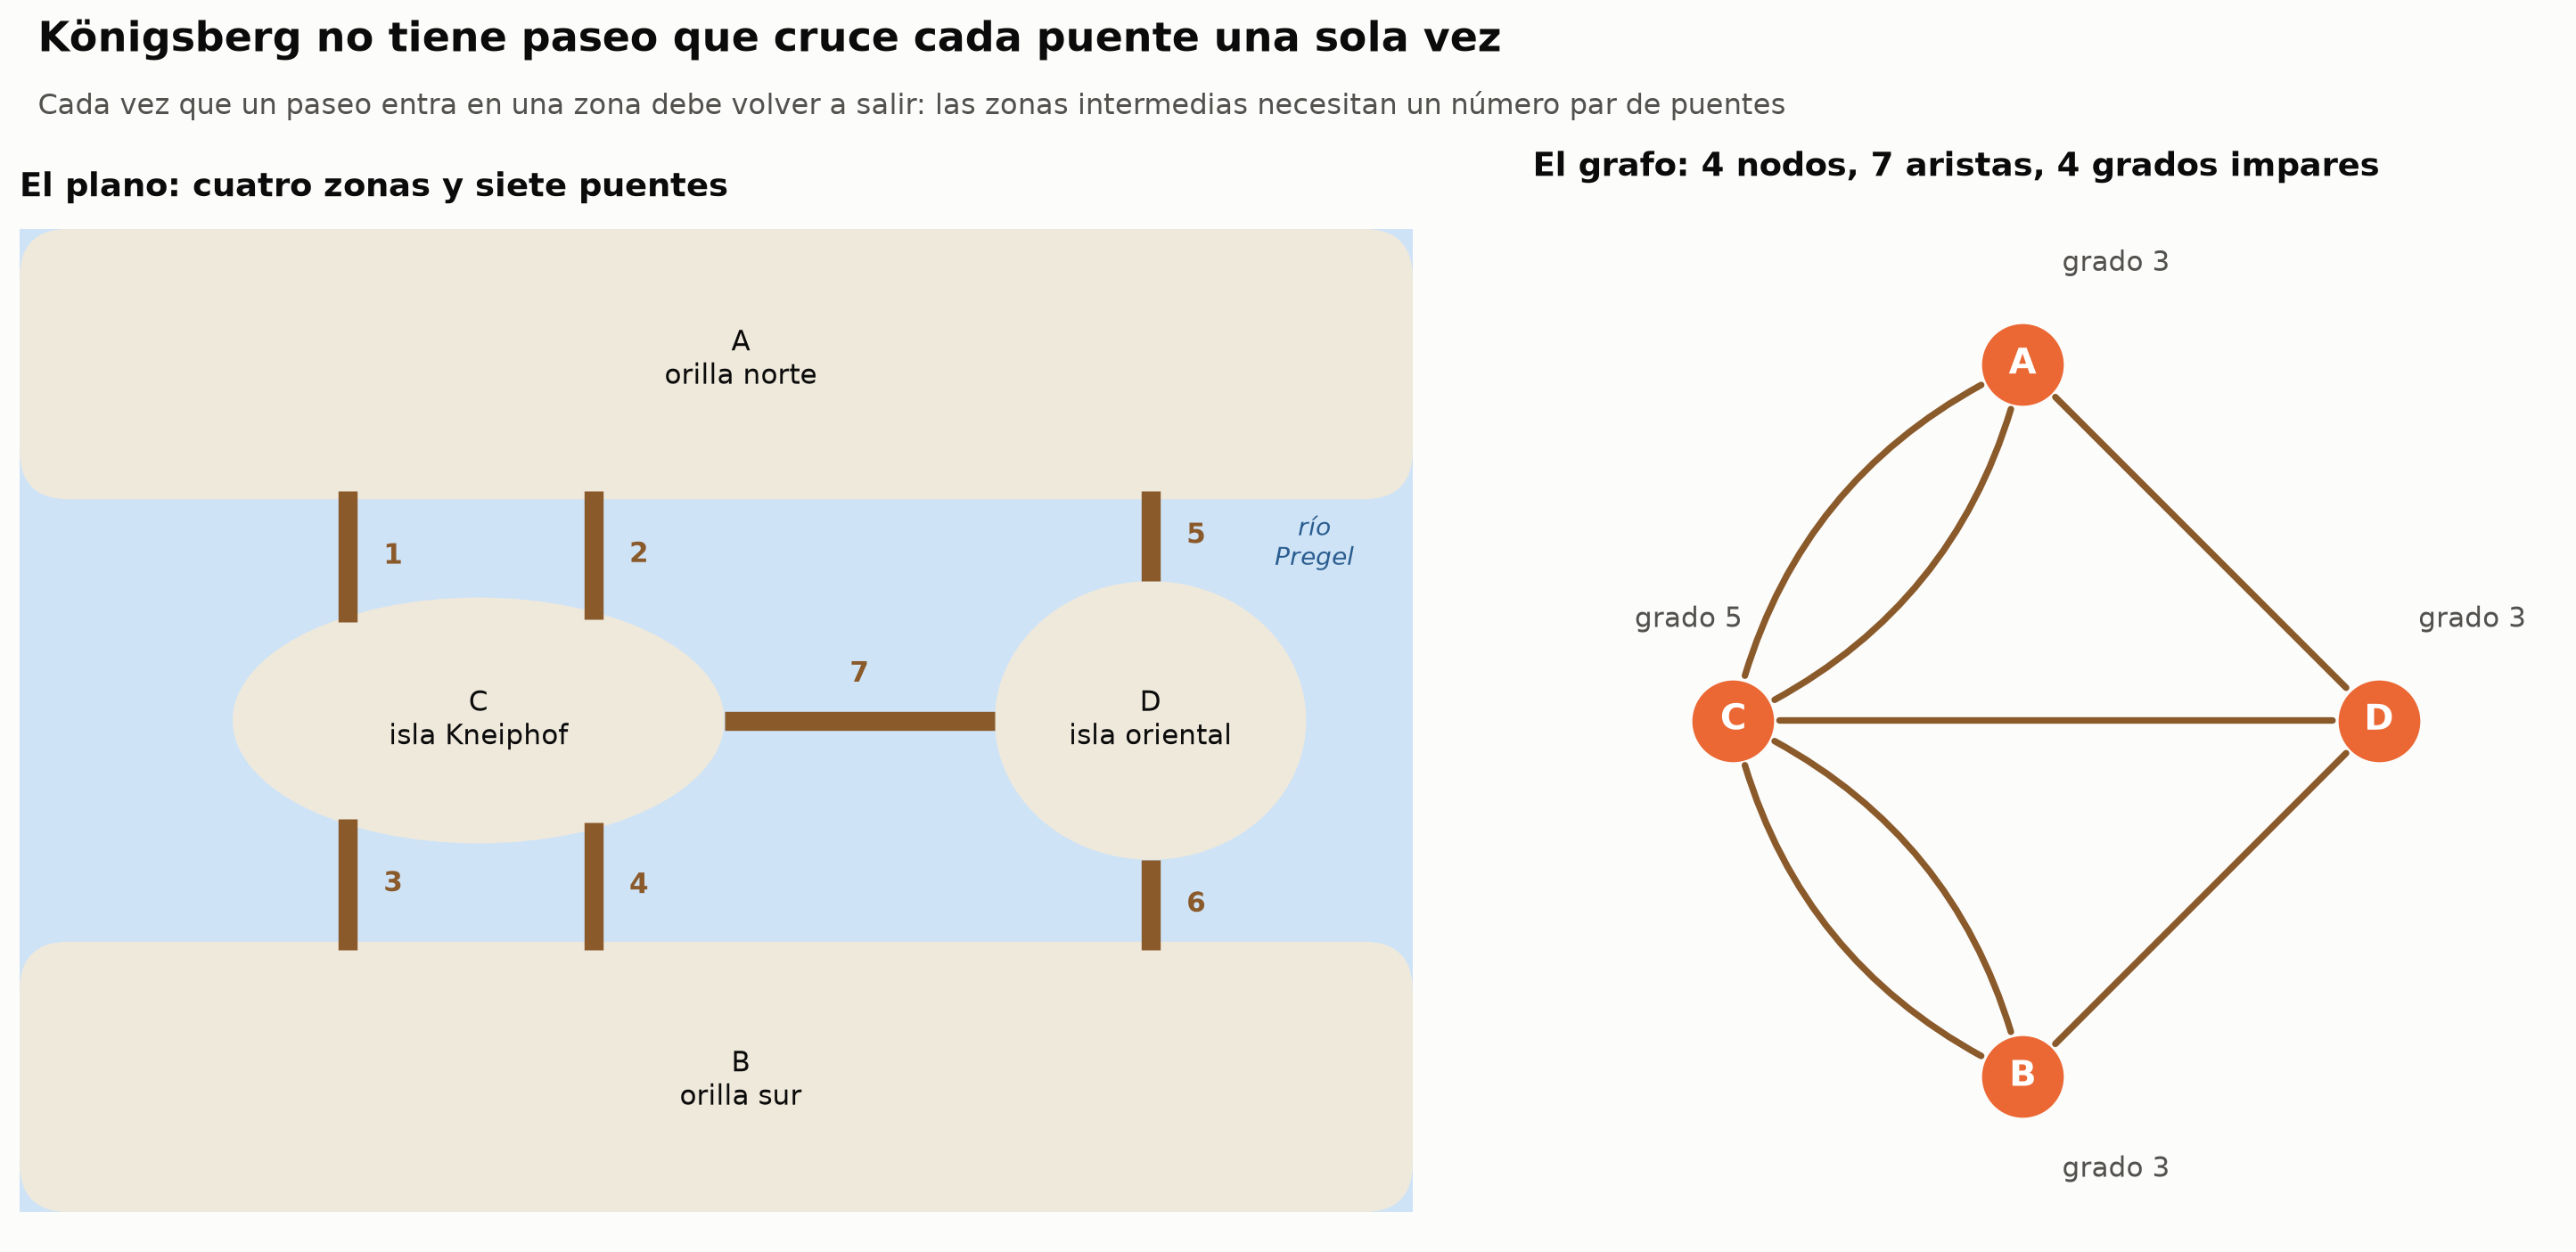

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw=dict(width_ratios=[1.15, 1]))
# --- Panel izquierdo: plano esquemático (agua de fondo, zonas de tierra y puentes)
WATER, LAND, BRIDGE = "#cfe3f6", "#efe9dc", "#8a5a2b"
ax1.add_patch(Rectangle((-4, -3), 8.5, 6, fc=WATER, ec="none"))
ax1.add_patch(FancyBboxPatch((-4, 1.35), 8.5, 1.65, boxstyle="round,pad=0,rounding_size=0.3", fc=LAND, ec=ec.MUTED))
ax1.add_patch(FancyBboxPatch((-4, -3), 8.5, 1.65, boxstyle="round,pad=0,rounding_size=0.3", fc=LAND, ec=ec.MUTED))
ax1.add_patch(Ellipse((-1.2, 0), 3.0, 1.5, fc=LAND, ec=ec.MUTED))
ax1.add_patch(Ellipse((2.9, 0), 1.9, 1.7, fc=LAND, ec=ec.MUTED))
bridge_xy = [((-2.0, 0.6), (-2.0, 1.4)), ((-0.5, 0.62), (-0.5, 1.4)), ((-2.0, -0.6), (-2.0, -1.4)),
             ((-0.5, -0.62), (-0.5, -1.4)), ((2.9, 0.85), (2.9, 1.4)), ((2.9, -0.85), (2.9, -1.4)),
             ((0.3, 0), (1.95, 0))]
for i, ((x1, y1), (x2, y2)) in enumerate(bridge_xy, 1):
    ax1.plot([x1, x2], [y1, y2], color=BRIDGE, lw=7, solid_capstyle="butt", zorder=3)
    ax1.text((x1 + x2) / 2 + (0.28 if x1 == x2 else 0), (y1 + y2) / 2 + (0 if x1 == x2 else 0.28), str(i),
             fontsize=10, color=BRIDGE, fontweight="bold", ha="center", va="center")
for n, (x, y) in {"A": (0.4, 2.2), "B": (0.4, -2.2), "C": (-1.2, 0), "D": (2.9, 0)}.items():
    ax1.text(x, y, f"{n}\n{land[n]}", ha="center", va="center", fontsize=10, color=ec.INK, zorder=4)
ax1.text(3.9, 0.95, "río\nPregel", fontsize=9, color="#2a5d8f", ha="center", style="italic")
ax1.set_xlim(-4, 4.5); ax1.set_ylim(-3, 3); ax1.set_aspect("equal"); ax1.axis("off")
ax1.set_title("El plano: cuatro zonas y siete puentes", loc="left", fontsize=12)
# --- Panel derecho: el grafo (sólo importa qué zona se conecta con cuál)
posK = {"A": (0, 1.6), "B": (0, -1.6), "C": (-1.3, 0), "D": (1.6, 0)}
seen = Counter()
for u, v in bridges:
    seen[(u, v)] += 1
    rad = {1: 0.0, 2: 0.0}[seen[(u, v)]] if bridges.count((u, v)) == 1 else (0.25 if seen[(u, v)] == 1 else -0.25)
    ax2.annotate("", xy=posK[v], xytext=posK[u], arrowprops=dict(arrowstyle="-", color=BRIDGE, lw=2.4,
                 shrinkA=17, shrinkB=17, connectionstyle=f"arc3,rad={rad}"))
for n, (x, y) in posK.items():
    ax2.scatter(x, y, s=900, color=ec.ORANGE if deg[n] % 2 else ec.GREEN, zorder=3)
    ax2.text(x, y, n, ha="center", va="center", color="white", fontsize=13, fontweight="bold", zorder=4)
    ax2.text(x + (0.42 if n != "C" else -0.2), y + (0.42 if n != "B" else -0.45), f"grado {deg[n]}",
             fontsize=10, color=ec.INK_2, ha="center")
ax2.set_xlim(-2.2, 2.4); ax2.set_ylim(-2.3, 2.3); ax2.set_aspect("equal"); ax2.axis("off")
ax2.set_title("El grafo: 4 nodos, 7 aristas, 4 grados impares", loc="left", fontsize=12)
ec.fig_title(fig, "Königsberg no tiene paseo que cruce cada puente una sola vez",
             "Cada vez que un paseo entra en una zona debe volver a salir: las zonas intermedias necesitan un número par de puentes")
plt.show()

> 🔎 **Qué observamos.** Las cuatro zonas tienen un número **impar** de puentes (3, 3, 5 y 3). Un paseo que entra en
> una zona intermedia tiene que volver a salir, de modo que consume sus puentes **de dos en dos**. Sólo el punto de
> partida y el de llegada pueden quedarse con un puente "suelto". Con cuatro zonas impares no hay paseo posible. Euler
> no necesitó probar ninguna ruta: le bastó contar.

> ✅ **Compruebe su comprensión.** Si la ciudad construyera un octavo puente entre A y B, ¿existiría el paseo? ¿Dónde
> tendría que empezar y dónde terminar? (Pista: cuente de nuevo los grados de A y B.)

## 2. El ensamblaje como problema de grafos

### 2.1 La formulación ingenua y por qué no sirve

Imagine que alguien tritura cien ejemplares del mismo periódico y le pide reconstruir la edición original a partir de
las tiras. Esa es la tarea del **ensamblaje**: la secuenciación nos da millones de lecturas cortas de un genoma que
nunca vimos entero.

La formulación más ingenua busca la **supercadena común más corta**: la cadena más breve que contiene todas las
lecturas como subcadenas. Tiene dos defectos. Es un problema **NP-difícil** (no se conoce forma de resolverlo en
tiempo razonable para millones de lecturas) y, peor, está **mal planteado biológicamente**: si el genoma tiene dos
copias de una misma secuencia, la supercadena más corta las funde en una sola, porque así es más corta. Las
formulaciones útiles se apoyan en **grafos**.

Trabajaremos con el mismo ejemplo del libro: cuatro lecturas de un genoma de juguete de 15 pb.

| Lectura | Secuencia |
|---|---|
| $r_1$ | `CAGGTTGC` |
| $r_2$ | `GTTGCAGA` |
| $r_3$ | `GCAGAAGG` |
| $r_4$ | `AGAAGGA` |

### 2.2 Solapamiento–disposición–consenso (OLC): lecturas como nodos

El paradigma clásico, el de los ensambladores de la era Sanger (Celera Assembler, por ejemplo), construye un **grafo de
solapamiento**: cada lectura es un **nodo**, y se traza una arista $u \to v$ cuando un **sufijo** de $u$ coincide con un
**prefijo** de $v$ en al menos $T$ bases. Hágalo a mano antes de ejecutar: ¿cuántas bases del final de `CAGGTTGC`
coinciden con el principio de `GTTGCAGA`? El final `GTTGC` (5 bases) es el principio de la segunda lectura.

In [5]:
reads = ["CAGGTTGC", "GTTGCAGA", "GCAGAAGG", "AGAAGGA"]
S = "CAGGTTGCAGAAGGA"                       # el genoma de juguete del libro (15 pb)

def overlap(a, b, min_len=1):
    """Longitud del solapamiento sufijo(a) = prefijo(b) más largo (0 si no hay)."""
    for n in range(min(len(a), len(b)) - 1, min_len - 1, -1):
        if a[-n:] == b[:n]:
            return n
    return 0

ov = pd.DataFrame([[overlap(a, b) if a != b else 0 for b in reads] for a in reads],
                  index=[f"r{i+1} {r}" for i, r in enumerate(reads)], columns=[f"r{i+1}" for i in range(4)])
print("Longitud del solapamiento sufijo(fila) → prefijo(columna):")
print(ov.to_string())

Longitud del solapamiento sufijo(fila) → prefijo(columna):
             r1  r2  r3  r4
r1 CAGGTTGC   0   5   2   0
r2 GTTGCAGA   0   0   5   3
r3 GCAGAAGG   0   1   0   6
r4 AGAAGGA    0   0   0   0


La tabla contiene seis solapamientos no nulos: tres largos (5, 5 y 6 bases) y tres cortos (1, 2 y 3) que aparecen por
simple azar (una sola base coincide con probabilidad 1/4). Con un umbral $T \ge 4$ los cortos desaparecen.

**Reconstruir el genoma equivale a encontrar un camino que visite cada nodo exactamente una vez**: un **camino
hamiltoniano** (el problema del inspector). El paradigma tiene tres fases:

1. **Solapamiento**: comparar todas las lecturas contra todas, en principio $O(N^2)$ comparaciones;
2. **Disposición** (*layout*): decidir el orden de las lecturas, es decir, el camino hamiltoniano;
3. **Consenso**: alinear las lecturas en ese orden y votar la base de cada columna.

Con cuatro lecturas podemos probar **todos** los órdenes posibles ($4! = 24$) y quedarnos con los que usan
solapamientos de al menos $T$ bases.

In [6]:
def hamiltonian_paths(reads, T=4):
    """Fuerza bruta: todos los órdenes de lecturas cuyos solapamientos consecutivos son >= T."""
    sols = []
    for perm in itertools.permutations(range(len(reads))):
        ovs = [overlap(reads[a], reads[b]) for a, b in zip(perm, perm[1:])]
        if min(ovs) >= T:
            seq = reads[perm[0]] + "".join(reads[b][o:] for b, o in zip(perm[1:], ovs))
            sols.append((perm, ovs, seq))
    return sols

for perm, ovs, seq in hamiltonian_paths(reads):
    print("orden:", " → ".join(f"r{i+1}" for i in perm), "| solapamientos:", ovs, "| consenso:", seq,
          "✔ genoma" if seq == S else "")
for n in (4, 10, 20, 60):
    print(f"n = {n:>3} lecturas → n! = {math.factorial(n):.3g} órdenes posibles")

orden: r1 → r2 → r3 → r4 | solapamientos: [5, 5, 6] | consenso: CAGGTTGCAGAAGGA ✔ genoma
n =   4 lecturas → n! = 24 órdenes posibles
n =  10 lecturas → n! = 3.63e+06 órdenes posibles
n =  20 lecturas → n! = 2.43e+18 órdenes posibles
n =  60 lecturas → n! = 8.32e+81 órdenes posibles


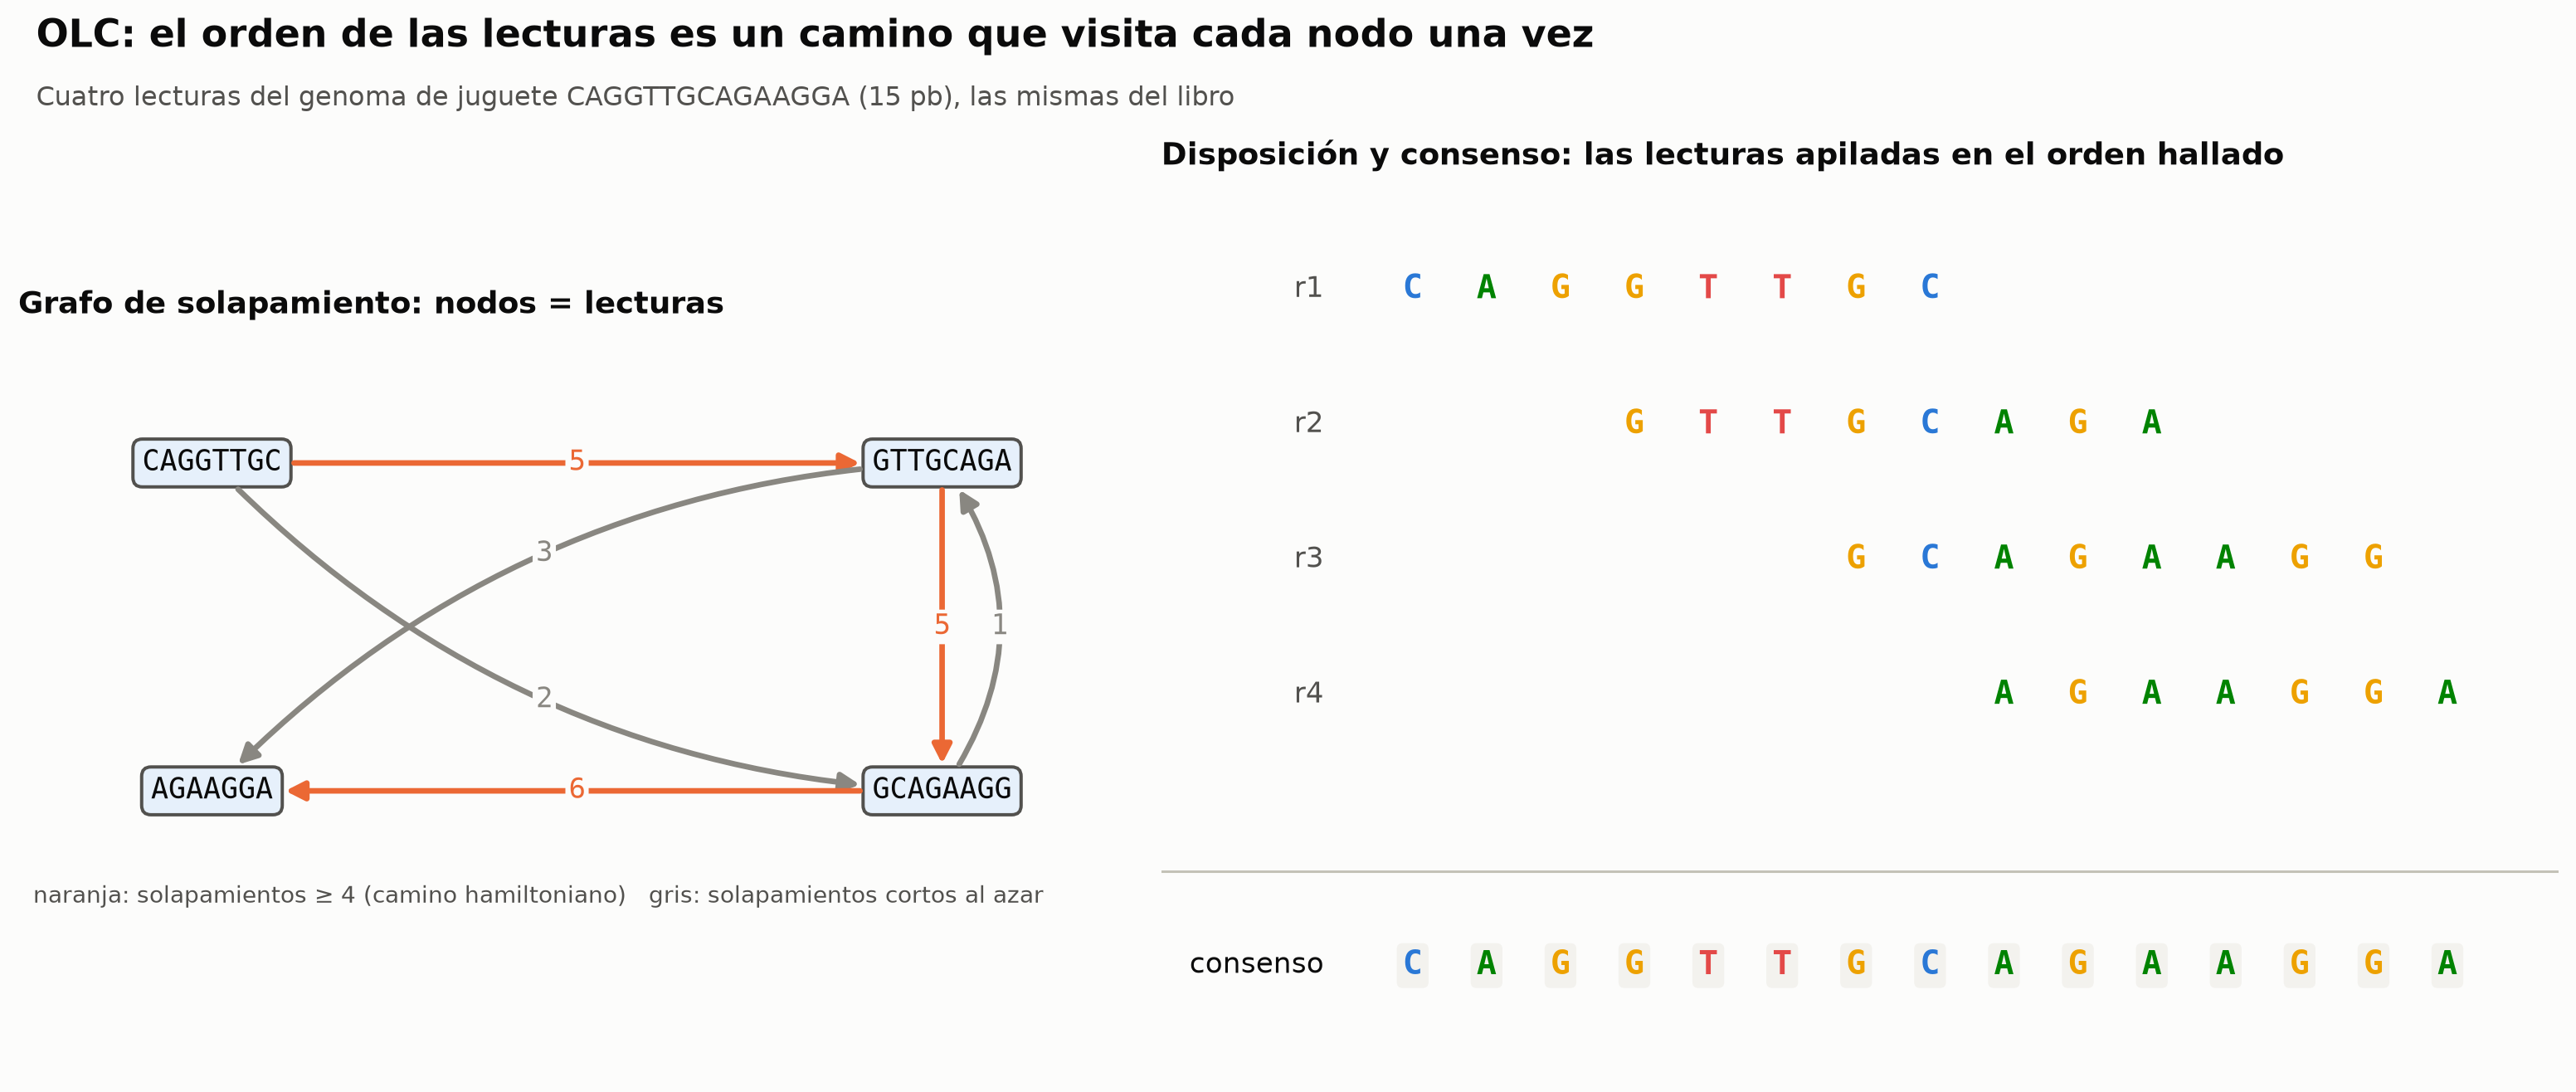

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw=dict(width_ratios=[1, 1.25]))
# --- Panel izquierdo: grafo de solapamiento con la longitud de cada solapamiento
posO = {r: xy for r, xy in zip(reads, [(0, 2.2), (4.9, 2.2), (4.9, 0), (0, 0)])}
e_olc, lab_olc, col_olc, rad_olc = [], [], [], []
for a in reads:
    for b in reads:
        o = overlap(a, b) if a != b else 0
        if o:
            e_olc.append((a, b)); lab_olc.append(str(o))
            col_olc.append(ec.ORANGE if o >= 4 else ec.MUTED)
            rad_olc.append(0.0 if o >= 4 else 0.35 if o == 1 else 0.2)   # curvas: etiquetas separadas
draw_digraph(ax1, posO, e_olc, edge_colors=col_olc, edge_labels=lab_olc, rads=rad_olc, fontsize=11.5,
             label_size=11, lw=2.2, node_colors={r: "#e6f0fb" for r in reads}, xlim=(-1.3, 6.2), ylim=(-0.9, 3.0))
ax1.set_title("Grafo de solapamiento: nodos = lecturas", loc="left", fontsize=12)
ax1.text(-1.2, -0.75, "naranja: solapamientos ≥ 4 (camino hamiltoniano)   gris: solapamientos cortos al azar",
         fontsize=9, color=ec.INK_2)
# --- Panel derecho: disposición y consenso
offsets = [0, 3, 6, 8]
for i, (r, o) in enumerate(zip(reads, offsets)):
    y = 4 - i
    for j, b in enumerate(r):
        ax2.text(o + j, y, b, ha="center", va="center", family="monospace", fontsize=13, fontweight="bold",
                 color=ec.NUC_COLORS[b])
    ax2.text(-1.2, y, f"r{i+1}", ha="right", va="center", fontsize=11, color=ec.INK_2)
ax2.axhline(-0.3, color=ec.BASELINE, lw=1)
for j, b in enumerate(S):
    ax2.text(j, -1, b, ha="center", va="center", family="monospace", fontsize=13, fontweight="bold",
             color=ec.NUC_COLORS[b], bbox=dict(boxstyle="round,pad=0.18", fc="#f3f2ee", ec="none"))
ax2.text(-1.2, -1, "consenso", ha="right", va="center", fontsize=11, color=ec.INK)
ax2.set_xlim(-3.4, 15.5); ax2.set_ylim(-1.8, 4.7); ax2.axis("off")
ax2.set_title("Disposición y consenso: las lecturas apiladas en el orden hallado", loc="left", fontsize=12)
ec.fig_title(fig, "OLC: el orden de las lecturas es un camino que visita cada nodo una vez",
             "Cuatro lecturas del genoma de juguete CAGGTTGCAGAAGGA (15 pb), las mismas del libro")
plt.show()

> 🔎 **Qué observamos.** Con umbral $T=4$ sólo queda un camino, $r_1 \to r_2 \to r_3 \to r_4$, y su consenso es el
> genoma. Pero lo encontramos probando los 24 órdenes. Con 60 lecturas habría $8 \times 10^{81}$ órdenes, más que
> átomos en el universo observable; y un experimento real tiene **cientos de millones** de lecturas. Encontrar un
> camino hamiltoniano es **NP-completo**: los ensambladores OLC recurren a heurísticas. Myers (2005) dio al paradigma
> una forma más limpia, el **grafo de cadenas** (*string graph*), que elimina las aristas transitivas (si
> $u\to v\to w$ y $u\to w$, la arista $u\to w$ no añade información). Esa idea vive hoy en los ensambladores de
> lecturas largas.

### 2.3 De Bruijn: los $k$-mers como aristas

El enfoque alternativo **cambia los papeles de nodos y aristas**. En lugar de lecturas, los nodos son palabras cortas de
longitud $k-1$, y cada $k$-mer leído es una **arista** entre su prefijo y su sufijo. Idury y Waterman (1995)
propusieron representar las lecturas de esta forma, y Pevzner, Tang y Waterman (2001) mostraron que el ensamblaje se
reduce entonces a encontrar un **camino euleriano**, que recorre cada **arista** una vez: el problema del cartero.

> **Definición (grafo de De Bruijn de un conjunto de lecturas).** Dado un conjunto de lecturas y un entero $k$, el
> grafo de De Bruijn $G_k = (V, E)$ es el multigrafo dirigido en el que
> * $V$ es el conjunto de $(k-1)$-mers distintos presentes en las lecturas;
> * por cada $k$-mer $x = x_1 x_2 \cdots x_k$ se añade una arista del nodo $x_1\cdots x_{k-1}$ (su **prefijo**) al
>   nodo $x_2 \cdots x_k$ (su **sufijo**).
>
> Si un $k$-mer aparece varias veces **en el genoma**, se conserva una arista por aparición (o una arista con
> multiplicidad).

Hágalo a mano con la primera lectura y $k=4$: `CAGGTTGC` tiene $8-4+1 = 5$ $k$-mers,
`CAGG`, `AGGT`, `GGTT`, `GTTG` y `TTGC`. El primero, `CAGG`, es una arista del nodo `CAG` al nodo `AGG`.

In [8]:
def kmers(seq, k):
    return [seq[i:i + k] for i in range(len(seq) - k + 1)]

k = 4
kmer_counts = Counter()
for i, r in enumerate(reads, 1):
    km = kmers(r, k)
    kmer_counts.update(km)
    print(f"r{i} {r:9s} → " + "  ".join(f"{x[:-1]}→{x[1:]}" for x in km))
print(f"\nk-mers leídos: {sum(kmer_counts.values())}   ·   k-mers distintos: {len(kmer_counts)}")
print("Leídos dos veces (solapamiento entre lecturas, NO repetición del genoma):",
      sorted(x for x, c in kmer_counts.items() if c == 2))

r1 CAGGTTGC  → CAG→AGG  AGG→GGT  GGT→GTT  GTT→TTG  TTG→TGC
r2 GTTGCAGA  → GTT→TTG  TTG→TGC  TGC→GCA  GCA→CAG  CAG→AGA
r3 GCAGAAGG  → GCA→CAG  CAG→AGA  AGA→GAA  GAA→AAG  AAG→AGG
r4 AGAAGGA   → AGA→GAA  GAA→AAG  AAG→AGG  AGG→GGA

k-mers leídos: 19   ·   k-mers distintos: 12
Leídos dos veces (solapamiento entre lecturas, NO repetición del genoma): ['AAGG', 'AGAA', 'CAGA', 'GAAG', 'GCAG', 'GTTG', 'TTGC']


> 🔎 **Qué observamos.** Las cuatro lecturas producen 19 $k$-mers, pero sólo **12 distintos**: siete (`GTTG`, `TTGC`,
> `GCAG`, …) se leyeron dos veces porque caen en la zona donde dos lecturas se solapan. Esa redundancia es
> **cobertura**, no repetición del genoma, y el grafo la descarta: cada $k$-mer distinto es **una** arista (el número
> de veces que se leyó queda como su cobertura, que usaremos en la sección 7). En un genoma real, lo contrario también
> ocurre: un $k$-mer que el **genoma** contiene dos veces tendría cobertura doble, y un ensamblador que quiera
> reconstruirlo debe usar esa multiplicidad.

Observe también lo que desapareció: **las lecturas ya no existen como entidades**. Sólo quedan sus $k$-mers. No hace
falta comparar lecturas entre sí: el solapamiento de $k-1$ bases entre $k$-mers consecutivos está implícito en que
comparten un nodo.

In [9]:
def de_bruijn(seqs, k):
    """Grafo de De Bruijn: nodos = (k-1)-mers; una arista u→v por cada k-mer DISTINTO de las secuencias
    (en el orden en que aparecen). Devuelve un diccionario {u: [v1, v2, ...]} (lista de adyacencia)."""
    g, seen = defaultdict(list), set()
    for s in seqs:
        for x in kmers(s, k):
            if x not in seen:
                seen.add(x)
                g[x[:-1]].append(x[1:])
    return g

def nodes_of(g):
    return sorted(set(g) | {v for vs in g.values() for v in vs})

g4 = de_bruijn(reads, 4)
print(f"G_4 de las lecturas: {len(nodes_of(g4))} nodos y {sum(map(len, g4.values()))} aristas")
print("Lista de adyacencia:", dict(g4))

G_4 de las lecturas: 11 nodos y 12 aristas
Lista de adyacencia: {'CAG': ['AGG', 'AGA'], 'AGG': ['GGT', 'GGA'], 'GGT': ['GTT'], 'GTT': ['TTG'], 'TTG': ['TGC'], 'TGC': ['GCA'], 'GCA': ['CAG'], 'AGA': ['GAA'], 'GAA': ['AAG'], 'AAG': ['AGG']}


## 3. El teorema de Euler y la tabla de grados

### 3.1 La idea en palabras simples

En un grafo **dirigido** cada arista tiene sentido, como una calle de una sola vía. Para cada nodo $v$ contamos dos
números: cuántas aristas **entran** ($d^-(v)$, grado de entrada) y cuántas **salen** ($d^+(v)$, grado de salida). Un
recorrido que pasa por un nodo intermedio **entra y sale**: consume una arista de entrada y una de salida. Por eso, en
un camino que usa todas las aristas, los nodos intermedios deben tener tantas entradas como salidas; sólo el inicio
puede tener una salida "de más" y el final una entrada "de más".

### 3.2 El enunciado

> **Teorema (caminos eulerianos en grafos dirigidos).** Sea $G = (V, E)$ un grafo dirigido conexo (ignorando la
> orientación de las aristas). Entonces:
> 1. $G$ tiene un **ciclo** euleriano si y sólo si $d^-(v) = d^+(v)$ para todo $v$ (el grafo está **balanceado**).
> 2. $G$ tiene un **camino** euleriano de $s$ a $t \neq s$ si y sólo si
>
> $$
> d^{+}(s)=d^{-}(s)+1,\qquad d^{-}(t)=d^{+}(t)+1,\qquad d^{-}(v)=d^{+}(v)\ \ \forall v\notin\{s,t\}. \tag{08-euler}
> $$

| Símbolo | Significado |
|---|---|
| $G=(V,E)$ | Grafo dirigido: conjunto de nodos $V$ y de aristas $E$ (aquí, $(k-1)$-mers y $k$-mers) |
| $d^{-}(v)$ | Grado de **entrada** de $v$: número de aristas que llegan a $v$ |
| $d^{+}(v)$ | Grado de **salida** de $v$: número de aristas que parten de $v$ |
| $s,\ t$ | Nodos **inicial** y **final** del camino (en un genoma lineal, el primer y el último $(k-1)$-mer) |

**Por qué es cierto.** La **necesidad** es la cuenta que hicimos en Königsberg: cada paso por un nodo intermedio empareja
una entrada con una salida. La **suficiencia** es constructiva, y esa construcción es el algoritmo de la sección 5. Si
añadimos una arista ficticia $t \to s$, el grafo queda balanceado y basta con encontrar un ciclo. Empiece en cualquier
nodo y camine por aristas no usadas: como el grafo está balanceado, sólo puede quedarse atascado en el nodo de partida,
de modo que ha trazado un ciclo. Si quedan aristas sin usar, alguna sale de un nodo del ciclo (por conexidad); inicie
allí un nuevo recorrido y empálmelo en el anterior. Repitiendo, se agotan las aristas. $\square$

### 3.3 La tabla de grados de nuestro ejemplo

> 🤔 **Antes de ejecutar, prediga.** Mire el genoma `CAGGTTGCAGAAGGA`. Los $3$-mers `CAG` y `AGG` aparecen **dos veces**
> cada uno. ¿Qué grados de entrada y salida tendrán? ¿Qué nodo será $s$ y cuál $t$?

In [10]:
def degree_table(g):
    """Tabla con d⁻(v), d⁺(v) y el papel de cada nodo según el teorema de Euler."""
    indeg = Counter(v for vs in g.values() for v in vs)
    rows = []
    for v in nodes_of(g):
        dout, din = len(g.get(v, [])), indeg[v]
        role = ("s (inicio)" if dout == din + 1 else "t (final)" if din == dout + 1
                else "balanceado" if din == dout else "✗ desbalanceado")
        rows.append(dict(nodo=v, **{"d⁻ (entran)": din, "d⁺ (salen)": dout}, papel=role))
    return pd.DataFrame(rows).set_index("nodo")

def euler_check(g):
    """Aplica la ecuación 08-euler. Devuelve (s, t) si hay camino euleriano (s == t si hay ciclo), o None."""
    tab = degree_table(g)
    diff = tab["d⁺ (salen)"] - tab["d⁻ (entran)"]
    und = nx.Graph([(u, v) for u, vs in g.items() for v in vs])
    if not nx.is_connected(und):
        return None
    if (diff == 0).all():
        return (tab.index[0], tab.index[0])
    if sorted(diff[diff != 0]) == [-1, 1]:
        return (diff.idxmax(), diff.idxmin())
    return None

deg4 = degree_table(g4)
print(deg4.to_string())
print("\nNodos con d⁻ ≠ d⁺:", list(deg4.index[deg4.papel != "balanceado"]),
      "→ camino euleriano de s a t:", euler_check(g4))

      d⁻ (entran)  d⁺ (salen)       papel
nodo                                     
AAG             1           1  balanceado
AGA             1           1  balanceado
AGG             2           2  balanceado
CAG             1           2  s (inicio)
GAA             1           1  balanceado
GCA             1           1  balanceado
GGA             1           0   t (final)
GGT             1           1  balanceado
GTT             1           1  balanceado
TGC             1           1  balanceado
TTG             1           1  balanceado

Nodos con d⁻ ≠ d⁺: ['CAG', 'GGA'] → camino euleriano de s a t: ('CAG', 'GGA')


> 🔎 **Qué observamos.** Coincide con el libro: `CAG` tiene una salida de más ($d^+=2$, $d^-=1$), así que es $s$;
> `GGA` tiene una entrada de más ($d^-=1$, $d^+=0$), así que es $t$; y `AGG`, con **dos** entradas y **dos** salidas,
> está balanceado. Todos los demás nodos tienen una entrada y una salida. Se cumple la ecuación 08-euler: **existe**
> un camino euleriano. Los nodos con grado 2 son precisamente los $(k-1)$-mers que se repiten en el genoma: las
> repeticiones del genoma se ven en el grafo como **nodos de grado mayor que uno**.

> ✅ **Compruebe su comprensión.** En un genoma **circular** (como el cromosoma de *E. coli*) sin ninguna repetición,
> ¿qué dice la tabla de grados? ¿Habrá camino o ciclo euleriano?

## 4. El ejemplo completo: dos genomas compatibles con los mismos $k$-mers

Dibujemos el grafo $G_4$ con la misma disposición de la figura del libro. Los 12 $4$-mers del genoma son todos
distintos, pero los $3$-mers `CAG` y `AGG` aparecen dos veces cada uno: forman una **repetición de longitud
$k-1 = 3$** que crea **dos ciclos** en el grafo.

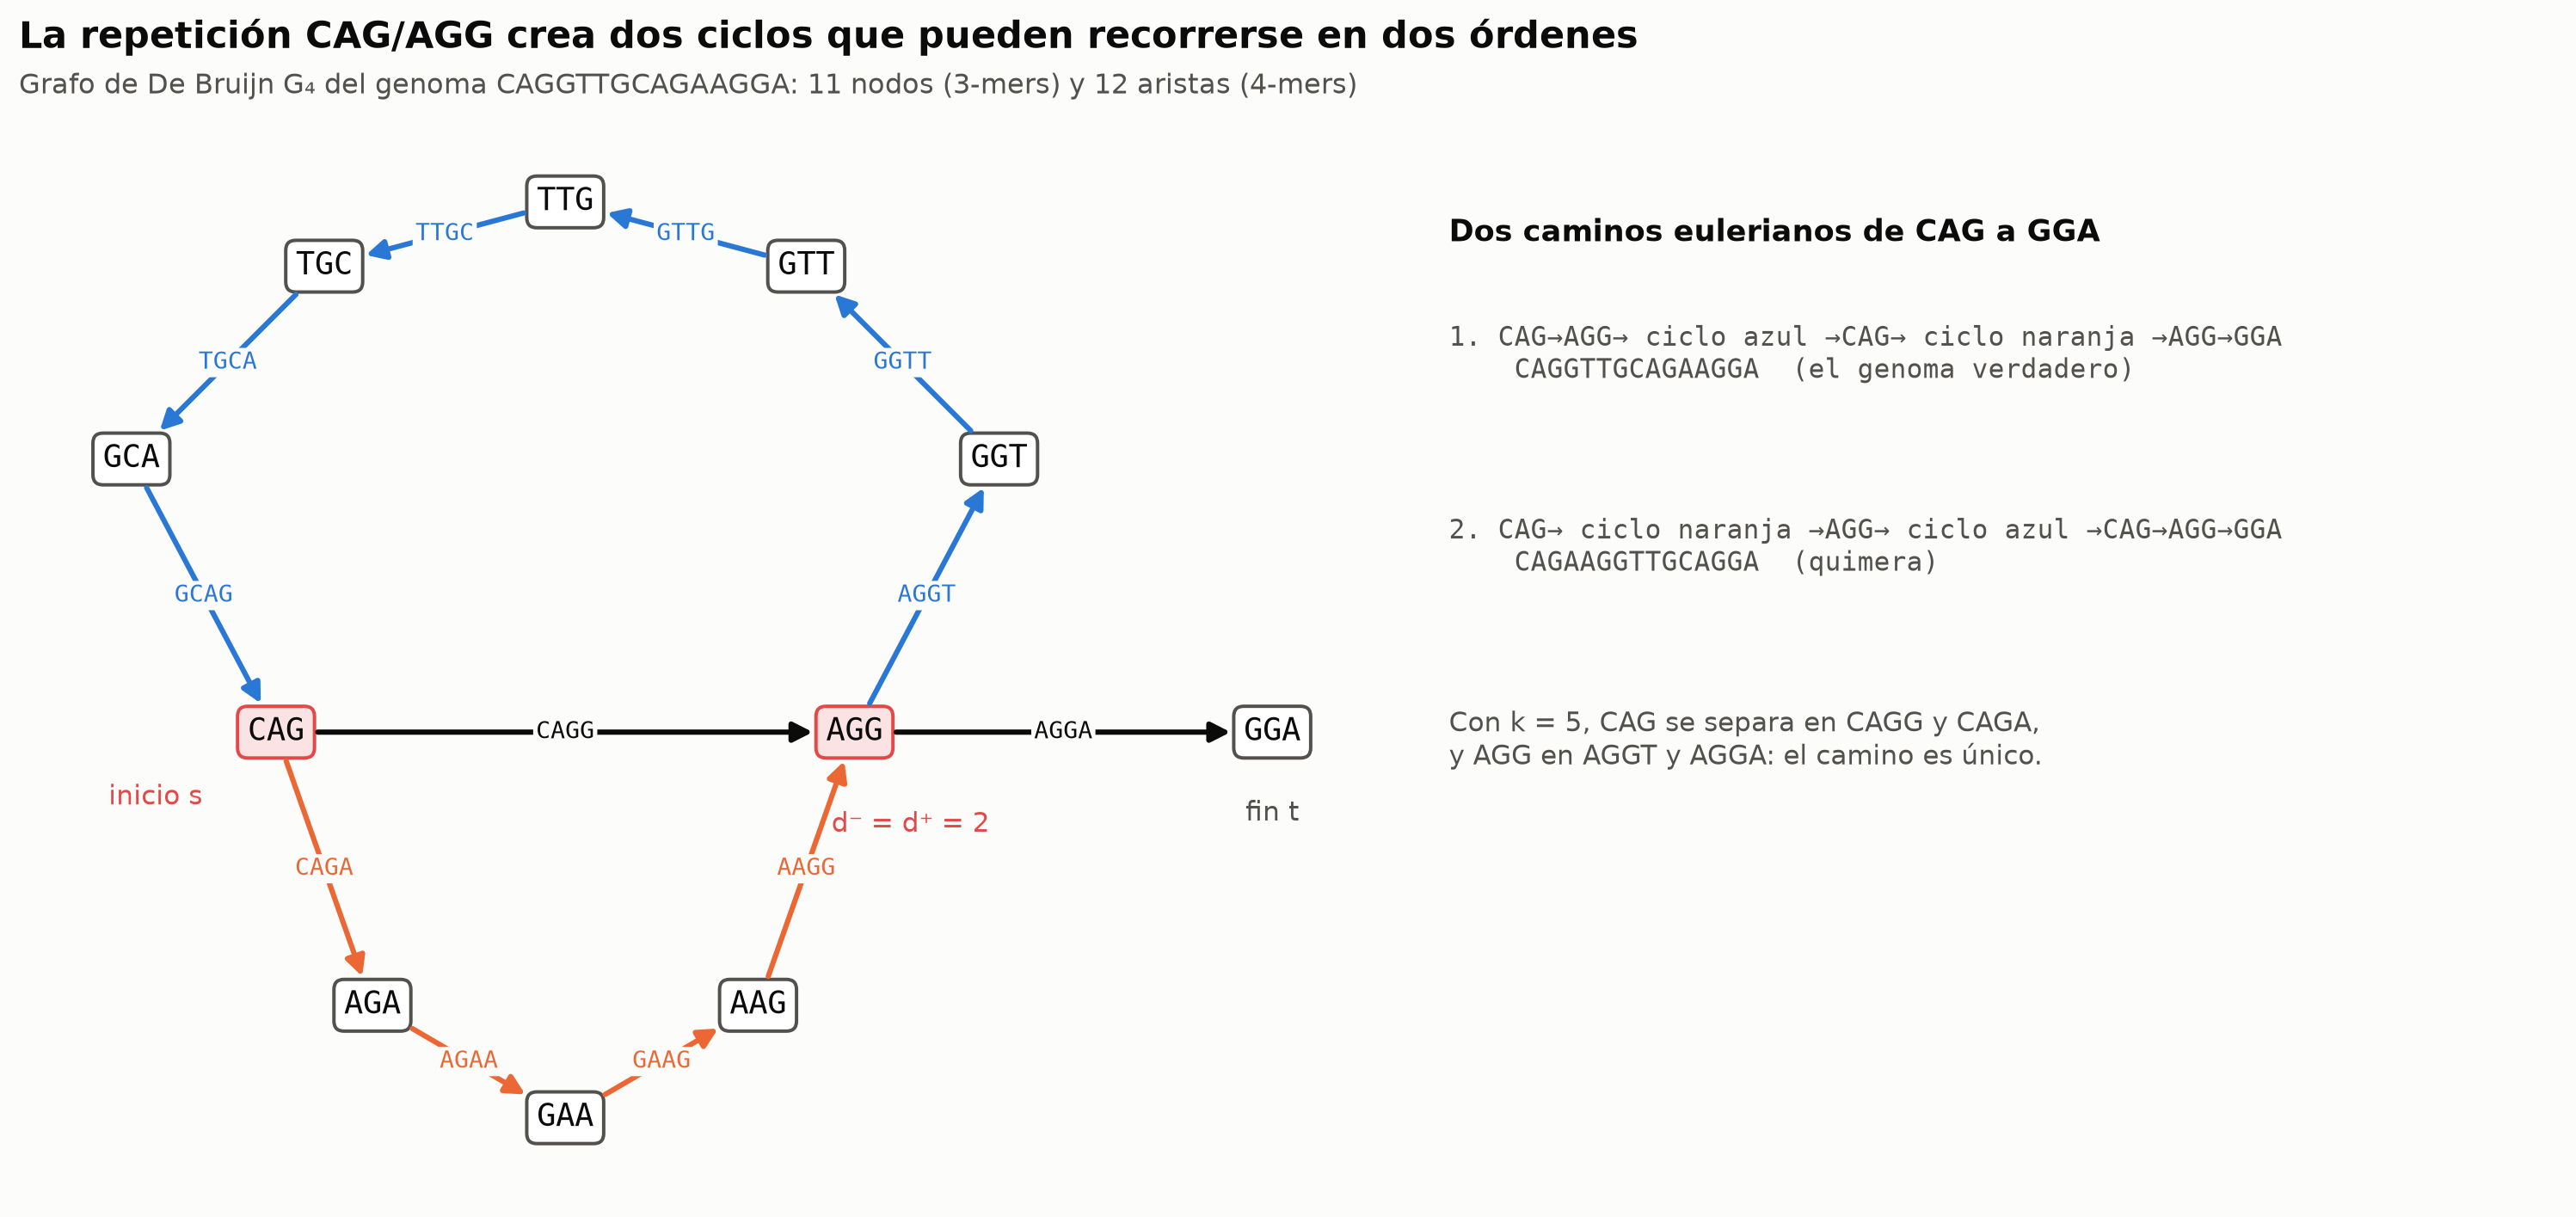

In [11]:
POS4 = {"CAG": (0, 0), "AGG": (3.6, 0), "GGA": (6.2, 0), "GGT": (4.5, 1.7), "GTT": (3.3, 2.9),
        "TTG": (1.8, 3.3), "TGC": (0.3, 2.9), "GCA": (-0.9, 1.7), "AGA": (0.6, -1.7), "GAA": (1.8, -2.4),
        "AAG": (3.0, -1.7)}
BLUE_CYCLE = {"AGGT", "GGTT", "GTTG", "TTGC", "TGCA", "GCAG"}
ORANGE_CYCLE = {"CAGA", "AGAA", "GAAG", "AAGG"}

def edge_color(x):
    return ec.BLUE if x in BLUE_CYCLE else ec.ORANGE if x in ORANGE_CYCLE else ec.INK

edges4 = [(u, v) for u, vs in g4.items() for v in vs]
kmer4 = [u + v[-1] for u, v in edges4]
fig, ax = plt.subplots(figsize=(13.5, 6.4))
draw_digraph(ax, POS4, edges4, edge_colors=[edge_color(x) for x in kmer4], edge_labels=kmer4,
             node_colors={"CAG": "#fbe3e3", "AGG": "#fbe3e3"}, node_edgecolors={"CAG": ec.RED, "AGG": ec.RED},
             fontsize=12, label_size=9, lw=2.0, xlim=(-1.6, 14.2), ylim=(-2.9, 3.8))
ax.text(-0.75, -0.45, "inicio s", ha="center", fontsize=10, color=ec.RED)
ax.text(6.2, -0.55, "fin t", ha="center", fontsize=10, color=ec.INK_2)
ax.text(3.95, -0.62, "d⁻ = d⁺ = 2", ha="center", fontsize=10, color=ec.RED)
ax.text(7.3, 3.2, "Dos caminos eulerianos de CAG a GGA", fontsize=11.5, fontweight="bold", color=ec.INK, va="top")
ax.text(7.3, 2.55, "1. CAG→AGG→ ciclo azul →CAG→ ciclo naranja →AGG→GGA\n    CAGGTTGCAGAAGGA  (el genoma verdadero)",
        fontsize=10, color=ec.INK_2, va="top", family="monospace")
ax.text(7.3, 1.35, "2. CAG→ ciclo naranja →AGG→ ciclo azul →CAG→AGG→GGA\n    CAGAAGGTTGCAGGA  (quimera)",
        fontsize=10, color=ec.INK_2, va="top", family="monospace")
ax.text(7.3, 0.15, "Con k = 5, CAG se separa en CAGG y CAGA,\ny AGG en AGGT y AGGA: el camino es único.",
        fontsize=10, color=ec.INK_2, va="top")
ax.set_xlim(-1.6, 14.2); ax.set_ylim(-2.9, 3.8)
ec.title(ax, "La repetición CAG/AGG crea dos ciclos que pueden recorrerse en dos órdenes",
         "Grafo de De Bruijn G₄ del genoma CAGGTTGCAGAAGGA: 11 nodos (3-mers) y 12 aristas (4-mers)")
plt.show()

> 🔎 **Qué observamos.** Todo camino euleriano de `CAG` a `GGA` debe usar las 12 aristas, pero al llegar a `CAG` o a
> `AGG` por primera vez hay que **elegir** qué ciclo recorrer primero. Las dos elecciones producen dos secuencias que
> contienen **exactamente los mismos $4$-mers con la misma multiplicidad**. Ningún algoritmo puede distinguirlas usando
> sólo esos $4$-mers. Verifiquémoslo enumerando **todos** los caminos eulerianos por fuerza bruta (con retroceso;
> sirve sólo para grafos diminutos).

In [12]:
def all_eulerian_paths(g, start):
    """Enumera todos los caminos eulerianos desde start (retroceso). Devuelve las secuencias deletreadas."""
    edges = [(u, v) for u, vs in g.items() for v in vs]
    out = set()
    def rec(u, used, spelled):
        if len(used) == len(edges):
            out.add(spelled); return
        for i, (a, b) in enumerate(edges):
            if i not in used and a == u:
                rec(b, used | {i}, spelled + b[-1])
    rec(start, frozenset(), start)
    return sorted(out)

for k in (4, 5):
    gk = de_bruijn(reads, k)
    s, t = euler_check(gk)
    sols = all_eulerian_paths(gk, s)
    print(f"k = {k}: {len(nodes_of(gk))} nodos, {sum(map(len, gk.values()))} aristas, s = {s}, t = {t}")
    for x in sols:
        print(f"   {x}  {'← genoma verdadero' if x == S else '← quimera'}")

k = 4: 11 nodos, 12 aristas, s = CAG, t = GGA
   CAGAAGGTTGCAGGA  ← quimera
   CAGGTTGCAGAAGGA  ← genoma verdadero
k = 5: 12 nodos, 11 aristas, s = CAGG, t = AGGA
   CAGGTTGCAGAAGGA  ← genoma verdadero


Con $k = 5$ la repetición `CAG`/`AGG` queda **dentro** de nodos más largos y distintos (`CAGG` ≠ `CAGA`, `AGGT` ≠
`AGGA`) y el camino euleriano pasa a ser único. Esta es la forma precisa de la regla general:

> **Si ningún $(k-1)$-mer se repite en el genoma, el grafo de De Bruijn es un camino simple y el ensamblaje es único.**
> Cada repetición más larga que $k-1$ introduce ramificaciones cuyo orden de recorrido no está determinado por los datos.

### 🔍 Explore: ¿cómo cambia el grafo al subir $k$?

La figura interactiva siguiente construye $G_k$ del mismo genoma para $k = 3, \dots, 7$. Use el deslizador. Pase el
cursor por cada nodo para ver sus grados y cuántas veces aparece en el genoma. Los nodos rojos son los $(k-1)$-mers
repetidos; el título indica cuántos caminos eulerianos (genomas compatibles) hay.

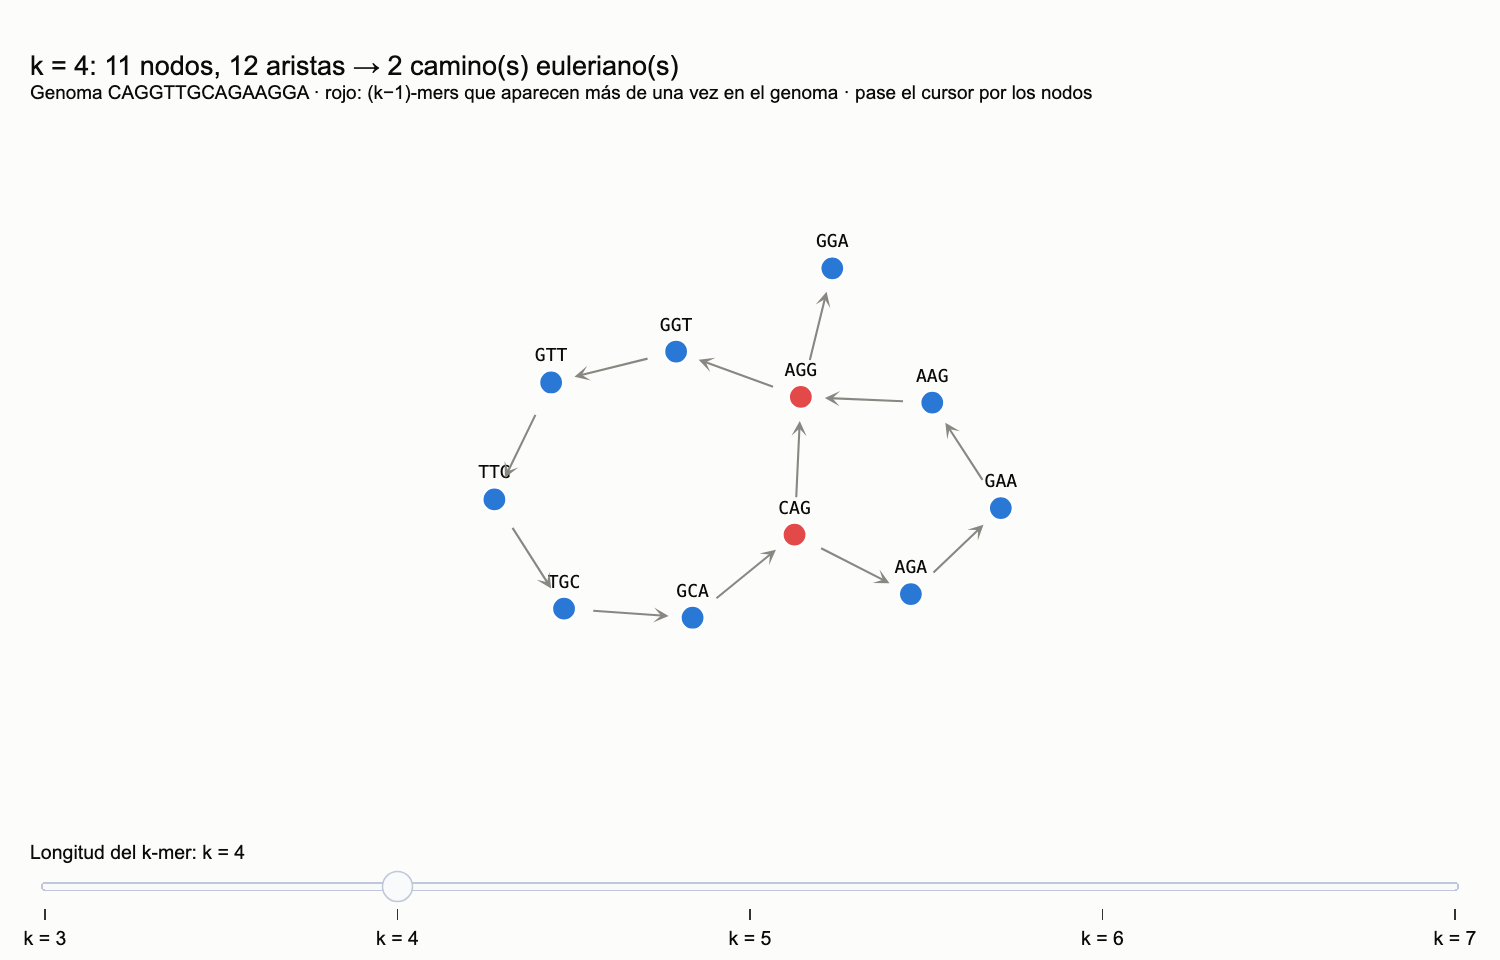

In [13]:
def graph_frame(k):
    gk = de_bruijn([S], k)
    G = nx.MultiDiGraph([(u, v) for u, vs in gk.items() for v in vs])
    layout = nx.kamada_kawai_layout(nx.Graph(G))
    s, t = euler_check(gk)
    n_sol = len(all_eulerian_paths(gk, s))
    occ = Counter(kmers(S, k - 1))
    indeg = Counter(v for vs in gk.values() for v in vs)
    ex, ey = [], []
    for u, v in G.edges():
        (x0, y0), (x1, y1) = layout[u], layout[v]
        ex += [x0, x1, None]; ey += [y0, y1, None]
    arrows = [dict(ax=layout[u][0], ay=layout[u][1], x=layout[v][0], y=layout[v][1], xref="x", yref="y",
                   axref="x", ayref="y", showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=1.4,
                   standoff=16, startstandoff=16, arrowcolor="#898781") for u, v in G.edges()]
    nodes = list(G.nodes())
    hover = [f"<b>{n}</b><br>aparece {occ[n]} vez/veces en el genoma<br>d⁻ = {indeg[n]}, d⁺ = {len(gk.get(n, []))}"
             + ("<br><i>repetido: aquí se ramifica el grafo</i>" if occ[n] > 1 else "")
             + ("<br>inicio s" if n == s else "<br>fin t" if n == t else "") for n in nodes]
    node_tr = go.Scatter(x=[layout[n][0] for n in nodes], y=[layout[n][1] for n in nodes], mode="markers+text",
                         text=nodes, textposition="top center", hovertext=hover, hoverinfo="text",
                         textfont=dict(family="monospace", size=12),
                         marker=dict(size=16, color=[ec.RED if occ[n] > 1 else ec.BLUE for n in nodes],
                                     line=dict(color="white", width=1.5)))
    edge_tr = go.Scatter(x=ex, y=ey, mode="lines", line=dict(color="rgba(0,0,0,0)"), hoverinfo="skip")
    title = (f"k = {k}: {len(nodes)} nodos, {G.number_of_edges()} aristas → {n_sol} camino(s) euleriano(s)"
             f"<br><sup>Genoma CAGGTTGCAGAAGGA · rojo: (k−1)-mers que aparecen más de una vez en el genoma · "
             f"pase el cursor por los nodos</sup>")
    return edge_tr, node_tr, arrows, title

ks = [3, 4, 5, 6, 7]
data0 = graph_frame(4)
fig = go.Figure(data=[data0[0], data0[1]])
fig.update_layout(annotations=data0[2], title=dict(text=data0[3]))
frames, steps = [], []
for k in ks:
    e_tr, n_tr, arrs, ttl = graph_frame(k)
    frames.append(go.Frame(data=[e_tr, n_tr], name=str(k), layout=go.Layout(annotations=arrs, title=dict(text=ttl))))
    steps.append(dict(method="animate", label=f"k = {k}",
                      args=[[str(k)], dict(mode="immediate", frame=dict(duration=0, redraw=True))]))
fig.frames = frames
fig.update_layout(sliders=[dict(active=1, steps=steps, currentvalue=dict(prefix="Longitud del k-mer: "),
                                pad=dict(t=30))],
                  xaxis=dict(visible=False, range=[-1.25, 1.25]), yaxis=dict(visible=False, range=[-1.25, 1.25],
                  scaleanchor="x"), height=640, margin=dict(t=100, l=20, r=20, b=40), showlegend=False)
fig.show()

> 🔎 **Qué observamos.** Con $k=3$ el grafo está lleno de nodos repetidos y hay muchos genomas compatibles; con $k=4$
> quedan dos (el ejemplo del libro); desde $k=5$ el grafo es un camino simple y la reconstrucción es única. Subir $k$
> "desenreda" el grafo porque cada nodo abarca más contexto. ¿Por qué entonces no usar siempre un $k$ enorme? Porque
> **un $k$-mer sólo existe si alguna lectura lo contiene entero y sin errores**: con $k$ cercano a la longitud de la
> lectura, muchos $k$-mers del genoma no se observan y el grafo se rompe en pedazos (lo vimos en la Lección 8.1 con
> $P(\text{k-mer sin error}) = (1-e)^k$; SPAdes combina varios $k$ precisamente por eso).

## 5. El algoritmo de Hierholzer, paso a paso

La demostración del teorema de Euler es un algoritmo, publicado por Carl Hierholzer en 1873. Se implementa con una
**pila** (una lista donde sólo se añade y se quita por el final, como una pila de platos):

1. Ponga el nodo inicial $s$ en la pila.
2. Mire el nodo de la cima. Si todavía tiene aristas de salida sin usar, **tome una**, márquela como usada y ponga su
   destino en la pila (avanzar).
3. Si el nodo de la cima ya no tiene salidas, es un **callejón**: sáquelo de la pila y añádalo al **camino** (fijar).
4. Repita hasta vaciar la pila. El camino, leído al revés, es un camino euleriano.

El truco está en el paso 3: cuando el recorrido se atasca antes de tiempo, los nodos se van fijando **desde el
final**, y mientras se retrocede se "empalman" los ciclos que quedaban pendientes. Cada arista se usa una sola vez, así
que el tiempo es $O(|E|)$: para un genoma bacteriano con $|E| \approx 5 \times 10^6$ aristas son milisegundos.

In [14]:
def eulerian_path(g, start, trace=None):
    """Algoritmo de Hierholzer, O(|E|). g: {u: [v, ...]}; devuelve la secuencia deletreada por el camino.
    Si trace es una lista, guarda cada paso (acción, pila, camino) para poder animarlo."""
    g = {u: list(vs) for u, vs in g.items()}        # copia consumible
    stack, path = [start], []
    while stack:
        u = stack[-1]
        if g.get(u):                                 # quedan aristas sin usar: avanzar
            v = g[u].pop()
            stack.append(v)
            if trace is not None: trace.append(("avanza", u + v[-1], list(stack), list(path)))
        else:                                        # callejón: fijar el nodo
            path.append(stack.pop())
            if trace is not None: trace.append(("fija", u, list(stack), list(path)))
    path.reverse()
    return path[0] + "".join(v[-1] for v in path[1:])

for k in (4, 5):
    gk = de_bruijn(reads, k)
    s, t = euler_check(gk)
    res = eulerian_path(gk, s)
    print(f"k = {k}: Hierholzer devuelve {res}  →  {'genoma verdadero ✔' if res == S else 'quimera ✗'}")

k = 4: Hierholzer devuelve CAGAAGGTTGCAGGA  →  quimera ✗
k = 5: Hierholzer devuelve CAGGTTGCAGAAGGA  →  genoma verdadero ✔


> 🔎 **Qué observamos.** Tal como anuncia el libro, con $k = 4$ nuestra implementación devuelve la **quimera**
> `CAGAAGGTTGCAGGA`: no es un error de programación, sino que el algoritmo eligió una de las dos respuestas igualmente
> válidas (depende de qué arista sale primero de la lista con `pop()`). Con $k=5$ devuelve el genoma verdadero porque
> sólo hay una respuesta. La animación siguiente muestra cada paso de la pila con $k=4$.

![Algoritmo de Hierholzer sobre G₄: la pila avanza por aristas no usadas (gris → color); cuando la cima es un callejón, el nodo pasa al camino, que se construye desde el final](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.2_hierholzer.gif)

*Algoritmo de Hierholzer sobre G₄: la pila avanza por aristas no usadas (gris → color); cuando la cima es un callejón, el nodo pasa al camino, que se construye desde el final*

In [15]:
trace = []
chimera = eulerian_path(g4, "CAG", trace)
fig, (ax, axs) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw=dict(width_ratios=[1.55, 1]))
fig.set_layout_engine("none"); fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.03, wspace=0.05)

def update(f):
    ax.clear(); axs.clear()
    f = min(f, len(trace))                        # los últimos cuadros repiten el estado final
    action, item, stack, path = trace[f - 1] if f > 0 else ("inicio", None, ["CAG"], [])
    done_steps = trace[:f]
    used = {x for a, x, _, _ in done_steps if a == "avanza"}
    cols = [edge_color(x) if x in used else "#d9d8d2" for x in kmer4]
    top = stack[-1] if stack else None
    ncol = {n: "white" for n in POS4}
    for n in path: ncol[n] = "#e3f1e6"
    if top: ncol[top] = "#fde2cf"
    draw_digraph(ax, POS4, edges4, edge_colors=cols, edge_labels=kmer4, node_colors=ncol,
                 node_edgecolors={top: ec.ORANGE} if top else None, fontsize=11.5, label_size=8.5, lw=2.0,
                 label_colors=[ec.INK_2 if x in used else "#bdbcb5" for x in kmer4], xlim=(-1.5, 6.9), ylim=(-3.0, 3.9))
    msg = {"inicio": "Empezamos con s = CAG en la pila",
           "avanza": f"Avanza por la arista {item}", "fija": f"{item} es un callejón: pasa al camino"}[action]
    ax.set_title(f"Paso {f} de {len(trace)} · {msg}", loc="left", fontsize=12.5)
    # pila (izquierda) y camino (derecha) en el panel lateral
    axs.set_xlim(0, 10); axs.set_ylim(-0.5, 14.5); axs.axis("off")
    axs.text(1.6, 14.0, "pila", ha="center", fontsize=12, fontweight="bold", color=ec.ORANGE)
    for i, n in enumerate(stack[-13:]):
        axs.text(1.6, 0.5 + i, n, ha="center", va="center", family="monospace", fontsize=10.5,
                 bbox=dict(boxstyle="round,pad=0.25", fc="#fde2cf" if i == len(stack[-13:]) - 1 else "white",
                           ec=ec.ORANGE, lw=1))
    if len(stack) > 13:
        axs.text(1.6, 13.3, f"(+{len(stack) - 13} debajo)", ha="center", fontsize=8, color=ec.INK_2)
    axs.text(5.2, 14.0, "camino (se llena desde el final)", ha="left", fontsize=12, fontweight="bold", color=ec.GREEN)
    for i, n in enumerate(path):
        axs.text(5.8, 0.5 + i, n, ha="center", va="center", family="monospace", fontsize=10.5,
                 bbox=dict(boxstyle="round,pad=0.25", fc="#e3f1e6", ec=ec.GREEN, lw=1))
    if len(path) == len(nodes_of(g4)) + 1 or (action == "fija" and not stack):
        rev = path[::-1]
        axs.text(5.2, -0.3, "leído al revés:\n" + rev[0] + "".join(v[-1] for v in rev[1:]), fontsize=10.5,
                 family="monospace", color=ec.INK, va="top")
    return []

anim_hier = ec.animate(fig, update, frames=len(trace) + 4, interval=700, name="8.2_hierholzer")
anim_hier

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Desde `CAG` el algoritmo toma primero `CAGA` (la última arista de la lista), recorre el ciclo
> naranja, llega a `AGG`, sigue por `AGGA` y se **atasca** en `GGA`, que no tiene salidas. Ahí empieza a fijar nodos
> desde el final: `GGA` es el **último** nodo del camino. Al retroceder hasta `AGG` descubre que quedan aristas sin
> usar (el ciclo azul), lo recorre y lo **empalma** en ese punto. El resultado es un camino euleriano válido, la quimera.
> Observe que nunca "prueba y deshace": cada arista se usa exactamente una vez.

### El teorema BEST: ¿cuántos genomas compatibles hay?

Para grafos grandes no podemos enumerar los caminos. Pero se pueden **contar** con una fórmula exacta, el teorema BEST
(por de **B**ruijn, van Aardenne-**E**hrenfest, **S**mith y **T**utte). Para un grafo dirigido **balanceado**, el
número de ciclos eulerianos es

$$
\operatorname{ec}(G) \;=\; t_w(G)\,\prod_{v\in V}\bigl(d^{+}(v)-1\bigr)!
$$

| Símbolo | Significado |
|---|---|
| $\operatorname{ec}(G)$ | Número de ciclos eulerianos distintos (como secuencias de aristas) |
| $t_w(G)$ | Número de **árboles de expansión orientados** hacia un nodo raíz $w$ (cualquiera; el valor no depende de $w$) |
| $d^{+}(v)$ | Grado de salida de $v$ |

$t_w(G)$ se calcula con el **teorema de la matriz-árbol**: es el determinante de la matriz laplaciana
$L = D_{\text{sal}} - A$ sin la fila y la columna de $w$. Para contar **caminos** de $s$ a $t$, añadimos la arista
ficticia $t \to s$ (así el grafo queda balanceado y cada ciclo, abierto en esa arista, es un camino).

In [16]:
def de_bruijn_multi(seq, k):
    """Grafo de De Bruijn de un GENOMA conocido, con una arista por cada APARICIÓN de cada k-mer
    (si un k-mer está dos veces en el genoma, hay dos aristas paralelas: la multiplicidad del libro)."""
    g = defaultdict(list)
    for x in kmers(seq, k):
        g[x[:-1]].append(x[1:])
    return g

def contract_simple_nodes(edges, keep):
    """Contrae los nodos con una entrada y una salida (no cambian el número de caminos eulerianos)."""
    edges = list(edges)
    while True:
        indeg, outdeg = Counter(v for _, v in edges), Counter(u for u, _ in edges)
        cand = [n for n in outdeg if indeg[n] == 1 and outdeg[n] == 1 and n not in keep]
        cand = [n for n in cand if not any(u == n and v == n for u, v in edges)]
        if not cand:
            return edges
        n = cand[0]
        e_in = next(e for e in edges if e[1] == n); e_out = next(e for e in edges if e[0] == n)
        edges.remove(e_in); edges.remove(e_out)
        edges.append((e_in[0], e_out[1]))

def int_det(M):
    """Determinante exacto de una matriz de enteros (algoritmo de Bareiss, sin errores de redondeo)."""
    M = [list(map(int, r)) for r in M]; n = len(M); sign, prev = 1, 1
    for i in range(n - 1):
        if M[i][i] == 0:
            sw = next((r for r in range(i + 1, n) if M[r][i] != 0), None)
            if sw is None:
                return 0
            M[i], M[sw] = M[sw], M[i]; sign = -sign
        for r in range(i + 1, n):
            for c in range(i + 1, n):
                M[r][c] = (M[r][c] * M[i][i] - M[r][i] * M[i][c]) // prev
        prev = M[i][i]
    return sign * M[-1][-1]

def count_eulerian_paths_best(g):
    """Teorema BEST + matriz-árbol. Cuenta caminos eulerianos de s a t añadiendo la arista ficticia t→s.
    (Cuenta secuencias de aristas; las aristas paralelas idénticas se descuentan dividiendo por sus permutaciones.)"""
    s, t = euler_check(g)
    edges = [(u, v) for u, vs in g.items() for v in vs]
    if s != t:
        edges.append((t, s))
    mult = Counter(edges)                                   # aristas paralelas idénticas (mismo k-mer repetido)
    edges = contract_simple_nodes(edges, keep={s, t})
    nodes = sorted({x for e in edges for x in e})
    idx = {n: i for i, n in enumerate(nodes)}
    A = np.zeros((len(nodes), len(nodes)), dtype=object)
    for u, v in edges:
        A[idx[u], idx[v]] += 1
    dout = A.sum(axis=1)
    L = np.diag(dout) - A
    keep_i = [i for i in range(len(nodes)) if i != idx[s]]
    t_w = int_det(L[np.ix_(keep_i, keep_i)].tolist()) if keep_i else 1
    prod = math.prod(math.factorial(int(d) - 1) for d in dout)
    same = math.prod(math.factorial(m) for m in mult.values())
    return t_w, prod, t_w * prod // same

for k in (4, 5):
    t_w, prod, n = count_eulerian_paths_best(de_bruijn(reads, k))
    print(f"k = {k}: t_w = {t_w}, ∏(d⁺−1)! = {prod}  →  {n} camino(s) euleriano(s)")

# Un genoma aleatorio con una repetición de 30 pb copiada en 4 sitios (5 tramos únicos entre copias)
pieces = ["".join(rng.choice(list("ACGT"), 80)) for _ in range(5)]
rep = "".join(rng.choice(list("ACGT"), 30))
g_rep = rep.join(pieces)
print(f"\nGenoma de {len(g_rep)} pb con una repetición de 30 pb × 4:")
for k in (15, 25, 31, 32, 41):
    gk = de_bruijn_multi(g_rep, k)
    n = count_eulerian_paths_best(gk)[2]
    print(f"   k = {k}: {n:,} genoma(s) compatible(s) con sus k-mers")

k = 4: t_w = 2, ∏(d⁺−1)! = 1  →  2 camino(s) euleriano(s)
k = 5: t_w = 1, ∏(d⁺−1)! = 1  →  1 camino(s) euleriano(s)

Genoma de 520 pb con una repetición de 30 pb × 4:


   k = 15: 6 genoma(s) compatible(s) con sus k-mers


   k = 25: 6 genoma(s) compatible(s) con sus k-mers


   k = 31: 6 genoma(s) compatible(s) con sus k-mers


   k = 32: 1 genoma(s) compatible(s) con sus k-mers


   k = 41: 1 genoma(s) compatible(s) con sus k-mers


> 🔎 **Qué observamos.** BEST confirma los dos caminos con $k=4$ y el único con $k=5$. En el genoma aleatorio con una
> repetición de 30 pb copiada cuatro veces, cualquier $k \le 31$ (es decir, $k-1 \le R$) deja el grafo con $3! = 6$
> genomas compatibles: los tres tramos únicos **entre** copias pueden recorrerse en cualquier orden (el primero y el
> último están fijados por $s$ y $t$). Cuando $k$ supera algo a $R$, cada $k$-mer que contiene la repetición entera incluye
> bases únicas de cada lado; si esas bases vecinas difieren entre copias (depende de la secuencia), las copias dejan de
> confundirse y la respuesta vuelve a ser única. Aquí basta $k = 32 = R + 2$, pero con otros flancos podría hacer falta más. En un genoma real con cientos de repeticiones, el número de
> reconstrucciones compatibles es **astronómico**. Por eso los ensambladores no intentan elegir una: se detienen en las
> ramificaciones y entregan los tramos no ambiguos. Esos tramos son el tema de la sección siguiente.

## 6. *Unitigs*: lo que sí es seguro

Si no podemos elegir entre caminos, ¿qué podemos afirmar? Piense en un mapa de carreteras: entre dos cruces, una
carretera sin desvíos sólo puede recorrerse de una manera. La incertidumbre aparece **en los cruces**. Del mismo modo,
los tramos **sin ramificaciones** del grafo son correctos en cualquier reconstrucción.

> Un **unitig** es un camino máximo cuyos nodos internos tienen exactamente una entrada y una salida
> ($d^-(v) = d^+(v) = 1$).

En el ejemplo hay cuatro: `CAGG`, `AGGTTGCAG`, `CAGAAGG` y `AGGA`. Cualquier camino euleriano es una concatenación de
estos unitigs (solapados en $k-1$ bases), y los ensambladores de lecturas cortas los entregan como **contigs** en lugar
de arriesgarse con una elección. El **grafo compactado**, en el que cada unitig se reduce a un único nodo, tiene
muchísimos menos nodos que el original y es la estructura con la que trabajan en la práctica (SPAdes lo llama
*condensed graph*; el archivo GFA que abriremos en la sección 9 es exactamente eso).

Las funciones siguientes trabajan con un diccionario `{k-mer: cobertura}`, la forma en que un ensamblador guarda el grafo
(los nodos $(k-1)$-mers no se guardan: se deducen del prefijo y el sufijo de cada $k$-mer).

In [17]:
def adjacency(counts):
    """Aristas que salen (out) y entran (inn) de cada nodo (k-1)-mer, a partir de {k-mer: cobertura}."""
    out, inn = defaultdict(list), defaultdict(list)
    for x in counts:
        out[x[:-1]].append(x); inn[x[1:]].append(x)
    return out, inn

def unitigs(counts):
    """Caminos máximos sin ramificaciones. Devuelve una lista de listas de k-mers (aristas)."""
    out, inn = adjacency(counts)
    simple = lambda n: len(out[n]) == 1 and len(inn[n]) == 1
    used, result = set(), []
    for x in counts:
        if x in used:
            continue
        path = [x]
        while simple(path[0][:-1]) and inn[path[0][:-1]][0] not in used and inn[path[0][:-1]][0] != path[-1]:
            path.insert(0, inn[path[0][:-1]][0])            # extender hacia atrás
        while simple(path[-1][1:]) and out[path[-1][1:]][0] not in used and out[path[-1][1:]][0] != path[0]:
            path.append(out[path[-1][1:]][0])                # extender hacia adelante
        used.update(path); result.append(path)
    return result

def spell(path):
    """Secuencia que deletrea un camino de k-mers consecutivos."""
    return path[0] + "".join(x[-1] for x in path[1:])

toy_unitigs = sorted((spell(u) for u in unitigs(kmer_counts)), key=S.find)
print("Unitigs del ejemplo (k = 4):", toy_unitigs)

Unitigs del ejemplo (k = 4): ['CAGG', 'AGGTTGCAG', 'CAGAAGG', 'AGGA']


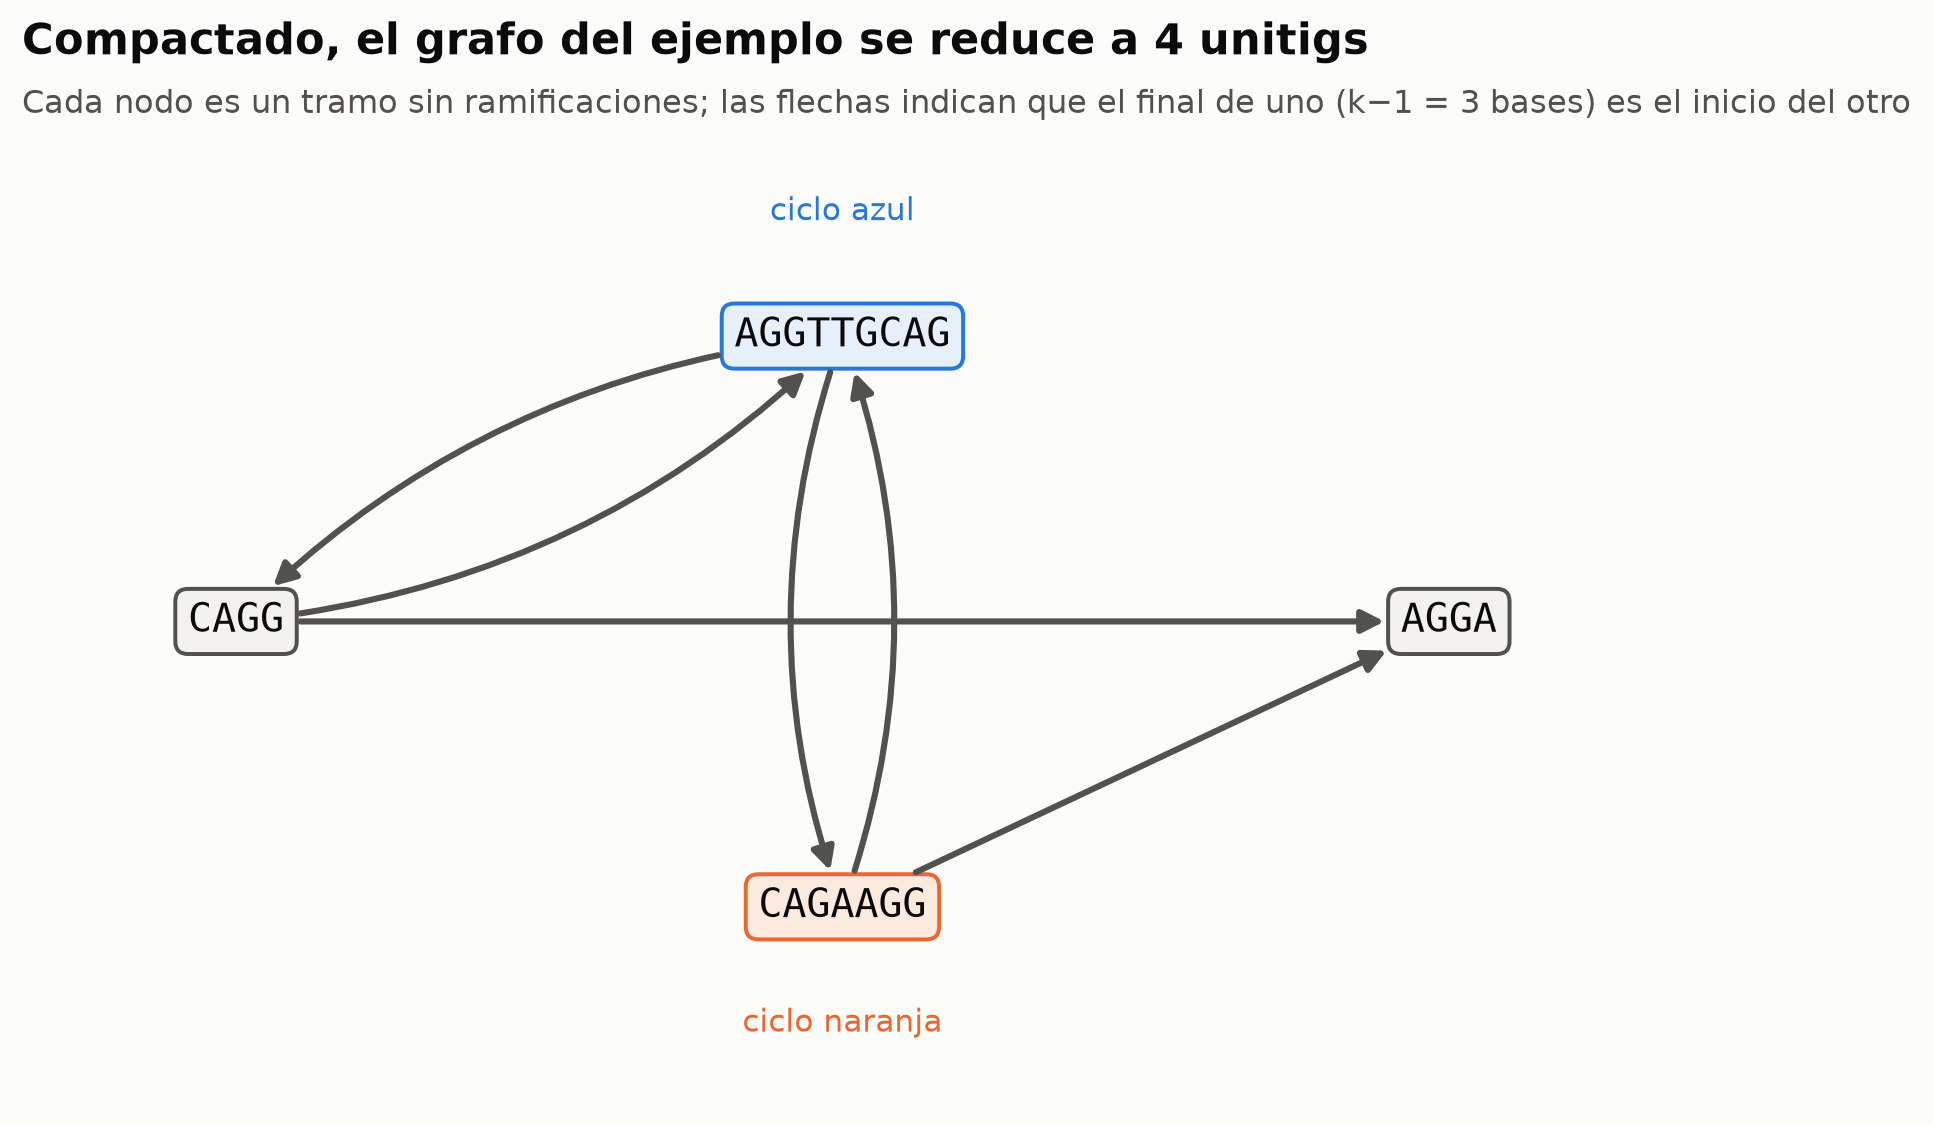

In [18]:
posU = {"CAGG": (0, 0), "AGGTTGCAG": (3.4, 1.6), "CAGAAGG": (3.4, -1.6), "AGGA": (6.8, 0)}
eU = [(a, b) for a in toy_unitigs for b in toy_unitigs if a[-3:] == b[:3]]
radsU = [0.18 if (b, a) in eU else 0.0 for a, b in eU]
fig, ax = plt.subplots(figsize=(11, 5))
draw_digraph(ax, posU, eU, rads=radsU, edge_colors=[ec.INK_2] * len(eU), fontsize=13, lw=2.0,
             node_colors={"CAGG": "#f3f2ee", "AGGA": "#f3f2ee", "AGGTTGCAG": "#e6f0fb", "CAGAAGG": "#fdeadf"},
             node_edgecolors={"AGGTTGCAG": ec.BLUE, "CAGAAGG": ec.ORANGE}, xlim=(-1.2, 8.0), ylim=(-2.7, 2.7))
ax.text(3.4, 2.25, "ciclo azul", ha="center", color=ec.BLUE, fontsize=10)
ax.text(3.4, -2.3, "ciclo naranja", ha="center", color=ec.ORANGE, fontsize=10)
ax.set_xlim(-1.2, 8.0); ax.set_ylim(-2.7, 2.7)
ec.title(ax, "Compactado, el grafo del ejemplo se reduce a 4 unitigs",
         "Cada nodo es un tramo sin ramificaciones; las flechas indican que el final de uno (k−1 = 3 bases) es el inicio del otro")
plt.show()

> 🔎 **Qué observamos.** Los 11 nodos y 12 aristas se convirtieron en 4 nodos. Los dos genomas compatibles son las dos
> maneras de recorrer este grafo pequeño: `CAGG`+`AGGTTGCAG`+`CAGAAGG`+`AGGA` (verdadero) o
> `CAGAAGG`… (quimera). Un ensamblador prudente entrega los cuatro unitigs y deja constancia de sus conexiones; eso es,
> literalmente, lo que contiene un archivo GFA.

> ✅ **Compruebe su comprensión.** Si todos los nodos de un grafo tienen $d^-=d^+=1$, ¿cuántos unitigs hay? ¿Qué
> estructura tiene el genoma que lo produjo?

## 7. El grafo real: puntas, burbujas, marañas y $k$-mers espurios

El ejemplo anterior era limpio: una lectura perfecta de cada $k$-mer. Con datos reales, el grafo se llena de
estructuras parásitas. Piense en fotocopias con manchas de tinta: cada mancha que cambia una letra crea una "frase"
que no existe en el libro original.

* **Puntas** (*tips*). Un error cerca del **extremo** de una lectura crea un camino corto que se desprende del grafo y
  termina en un **callejón sin salida**, con cobertura muy baja.
* **Burbujas** (*bubbles*). Un error en el **interior** de una lectura crea un camino alternativo de $k$ aristas que se
  separa y vuelve a unirse al camino principal. Un **sitio heterocigoto** produce exactamente la misma forma, pero con
  las dos ramas a cobertura parecida (cada una a $\lambda$, frente a $2\lambda$ del resto).
* **Marañas** (*tangles*). Una **repetición más larga que $k-1$** se colapsa en un solo camino por el que pasan varios
  recorridos del genoma; el tramo colapsado tiene una cobertura igual a la de una región única multiplicada por el
  número de copias.

### 7.1 ¿Cuántos $k$-mers espurios produce un error?

Hagámoslo a mano con $k = 4$: la lectura `CAGGTTGC` con un error en la quinta base (`T`→`A`) se convierte en
`CAGGATGC`. Sus $k$-mers `AGGA`, `GGAT`, `GATG`, `ATGC` contienen la `A` errónea: **cuatro $k$-mers nuevos**, uno por
cada posición que la base equivocada ocupa dentro de la ventana. Un error en el interior de una lectura contamina
**hasta $k$** $k$-mers. Con $NL$ bases leídas y tasa de error $e$:

$$
\mathbb{E}[\#\text{$k$-mers erróneos}] \;\approx\; N L\, e\, k . \tag{08-espurios}
$$

| Símbolo | Significado |
|---|---|
| $N$ | Número de lecturas |
| $L$ | Longitud de cada lectura |
| $NL$ | Número total de bases leídas ($= cG$, cobertura por tamaño del genoma) |
| $NLe$ | Número esperado de errores de secuenciación |
| $k$ | Cada error contamina hasta $k$ $k$-mers consecutivos |

Para un genoma humano a $30\times$ ($NL = 9{,}3\times10^{10}$) con $e = 0{,}1\,\%$ y $k = 31$, la ecuación da unos
$2{,}9 \times 10^{9}$ $k$-mers espurios: **casi tantos como los $3 \times 10^9$ verdaderos**. El grafo "en bruto" es
el doble de grande de lo necesario.

**Un refinamiento de maestría.** La palabra "hasta" importa: un error en la base $j$ de la lectura sólo está en
$\min(j, k, L-j+1, L-k+1)$ $k$-mers, porque cerca de los extremos la ventana no cabe entera. Contando exactamente, cada
lectura tiene $L-k+1$ $k$-mers y cada uno es erróneo con probabilidad $1-(1-e)^k$, así que

$$
\mathbb{E}[\#\text{$k$-mers erróneos}] = N\,(L-k+1)\,\bigl[1-(1-e)^k\bigr] \;\approx\; NLe\,k\cdot\frac{L-k+1}{L},
$$

que con lecturas de 150 nt y $k = 31$ es un 80 % de la aproximación del libro. El orden de magnitud, que es lo que
importa, no cambia.

In [19]:
for cov, e in ((30, 0.001), (30, 0.01)):
    NL = cov * 3.1e9
    print(f"Humano {cov}×, e = {e:.1%}: errores = {NL * e:.3g};  k-mers espurios (k = 31) ≈ NLek = {NL * e * 31:.3g}"
          f"  (exacto con L = 150: {NL / 150 * (150 - 31 + 1) * (1 - (1 - e) ** 31):.3g})")

Humano 30×, e = 0.1%: errores = 9.3e+07;  k-mers espurios (k = 31) ≈ NLek = 2.88e+09  (exacto con L = 150: 2.27e+09)
Humano 30×, e = 1.0%: errores = 9.3e+08;  k-mers espurios (k = 31) ≈ NLek = 2.88e+10  (exacto con L = 150: 1.99e+10)


### 7.2 Un genoma bacteriano en miniatura, con errores y una repetición

Para ver todas las estructuras a la vez simularemos un **cromosoma circular** de 1 500 pb (como el de *E. coli*, pero
3 000 veces más pequeño) que contiene una **repetición de 60 pb copiada tres veces**, como los operones de ARN
ribosómico que encontraremos en los datos reales. Lo "secuenciamos" con lecturas de 80 nt a $15\times$ y una tasa de
error de 0,3 %, y construimos el grafo con $k = 21$.

Una simplificación honesta: nuestras lecturas vienen todas de la misma hebra. Un ensamblador real no sabe de qué hebra
procede cada lectura y trabaja con $k$-mers **canónicos** (el menor entre el $k$-mer y su reverso complementario) y con
un grafo **bidirigido**, en el que cada nodo tiene dos lados; lo veremos en el archivo GFA de la sección 9. La lógica de
puntas, burbujas y marañas es idéntica.

> 🤔 **Antes de ejecutar, prediga.** Con unas 280 lecturas de 80 nt y $e = 0{,}003$, ¿cuántos errores habrá en total?
> ¿Cuántos $k$-mers espurios distintos espera con la ecuación 08-espurios?

In [20]:
rng_sim = np.random.default_rng(8)
G_LEN, R_LEN, K, L_READ, COV, ERR = 1500, 60, 21, 80, 15, 0.003

def rand_seq(n):
    return "".join(rng_sim.choice(list("ACGT"), n))

rep60 = rand_seq(R_LEN)                                    # la repetición (3 copias)
uniq = [rand_seq(n) for n in (420, 480, 420)]               # tres tramos únicos
genome_sim = uniq[0] + rep60 + uniq[1] + rep60 + uniq[2] + rep60
circ = genome_sim + genome_sim[:L_READ]                     # cromosoma circular: se lee "dando la vuelta"
rep_starts = [m.start() for m in re.finditer(rep60, genome_sim)]

n_reads = int(COV * G_LEN / L_READ)
sim_reads, sim_origin, sim_errors = [], [], []
for _ in range(n_reads):
    p = int(rng_sim.integers(G_LEN))
    r, errs = list(circ[p:p + L_READ]), []
    for j in np.nonzero(rng_sim.random(L_READ) < ERR)[0]:
        r[j] = rng_sim.choice([b for b in "ACGT" if b != r[j]]); errs.append(int(j))
    sim_reads.append("".join(r)); sim_origin.append(p); sim_errors.append(errs)

counts_raw = Counter(x for r in sim_reads for x in kmers(r, K))
true_kmers = {circ[i:i + K] for i in range(G_LEN)}
spurious = {x: c for x, c in counts_raw.items() if x not in true_kmers}
n_err = sum(map(len, sim_errors))
print(f"Genoma {G_LEN} pb · repetición de {R_LEN} pb en las posiciones {rep_starts} · {n_reads} lecturas de {L_READ} nt")
print(f"Errores de secuenciación: {n_err}  (esperados N·L·e = {n_reads * L_READ * ERR:.0f})")
print(f"k-mers distintos: {len(counts_raw):,} → verdaderos {len(true_kmers & set(counts_raw)):,} "
      f"(de {len(true_kmers):,} en el genoma) + espurios {len(spurious):,}")
print(f"Ecuación 08-espurios N·L·e·k = {n_reads * L_READ * ERR * K:,.0f} · exacta N(L−k+1)[1−(1−e)^k] = "
      f"{n_reads * (L_READ - K + 1) * (1 - (1 - ERR) ** K):,.0f} · observados (con repetición) = {sum(spurious.values()):,}")
print(f"Unitigs del grafo en bruto: {len(unitigs(counts_raw))}")

Genoma 1500 pb · repetición de 60 pb en las posiciones [420, 960, 1440] · 281 lecturas de 80 nt
Errores de secuenciación: 63  (esperados N·L·e = 67)
k-mers distintos: 2,404 → verdaderos 1,417 (de 1,417 en el genoma) + espurios 987
Ecuación 08-espurios N·L·e·k = 1,416 · exacta N(L−k+1)[1−(1−e)^k] = 1,031 · observados (con repetición) = 987
Unitigs del grafo en bruto: 159


> 🔎 **Qué observamos.** Un puñado de errores (unas decenas) basta para crear cerca de **mil** $k$-mers falsos, cerca
> del 70 % del número de $k$-mers verdaderos del genoma. La cifra observada coincide con la fórmula exacta; la
> aproximación $NLek$ del libro la sobrestima porque ignora el efecto de los extremos de la lectura, que con lecturas
> cortas ($L = 80$, $k = 21$) es grande. Y el grafo, que para un cromosoma circular sin repeticiones sería **un solo
> ciclo**, se ha fragmentado en más de cien unitigs.

La cobertura separa limpiamente los dos grupos: es el espectro de $k$-mers de la Lección 8.1, ahora coloreado con la
verdad que sólo la simulación conoce.

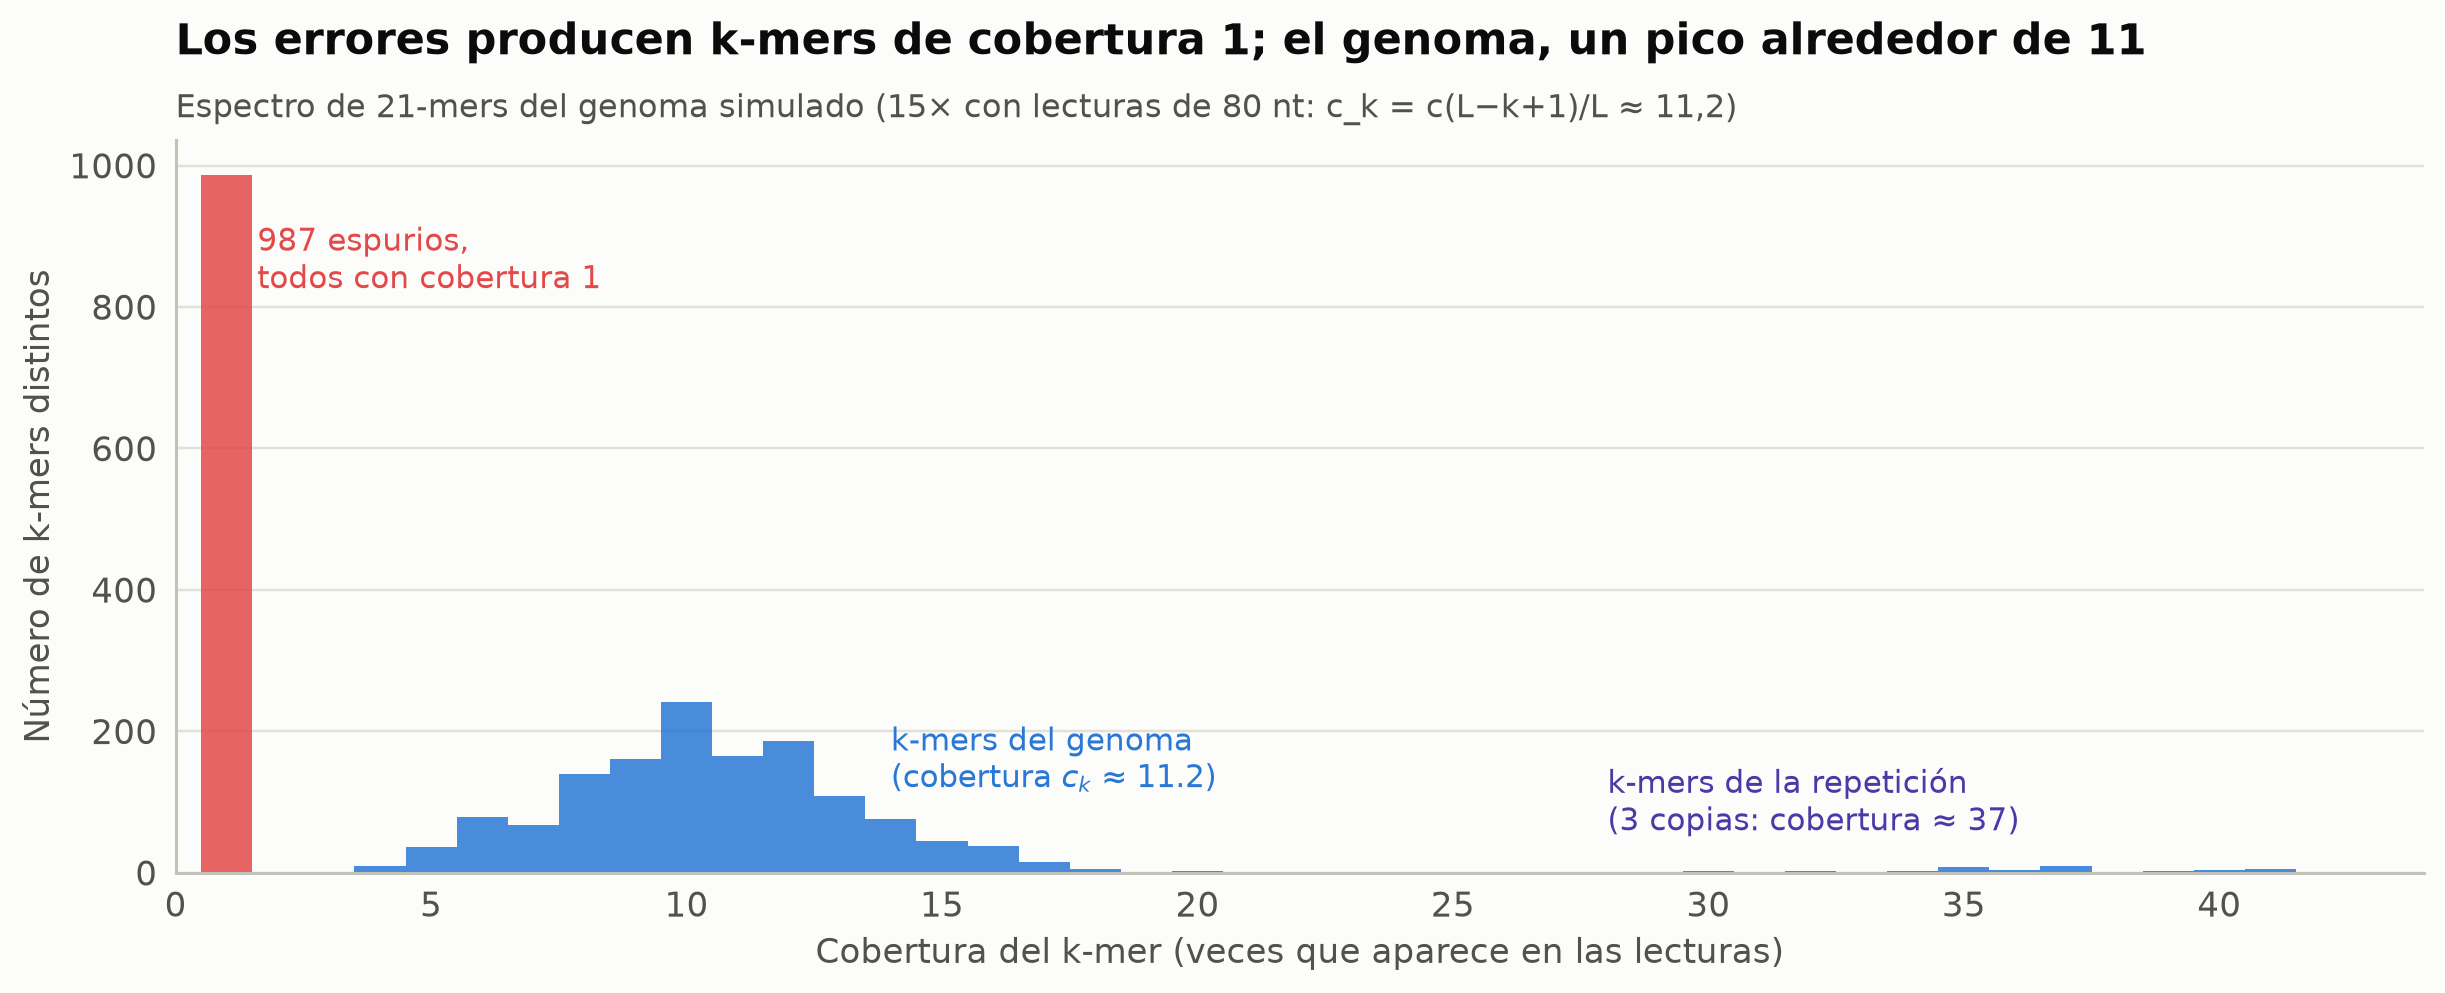

In [21]:
fig, ax = plt.subplots(figsize=(11, 4.4))
bins = np.arange(0.5, max(counts_raw.values()) + 1.5)
ax.hist([c for x, c in counts_raw.items() if x in true_kmers], bins=bins, color=ec.BLUE, alpha=0.85,
        label="k-mers del genoma")
ax.hist(list(spurious.values()), bins=bins, color=ec.RED, alpha=0.85, label="k-mers espurios (errores)")
rep_k = {rep60[i:i + K] for i in range(R_LEN - K + 1)}
rep_cov = np.mean([counts_raw[x] for x in rep_k])
ax.annotate(f"k-mers de la repetición\n(3 copias: cobertura ≈ {rep_cov:.0f})", (rep_cov, 3), xytext=(rep_cov - 9, 60),
            fontsize=10, color=ec.VIOLET, arrowprops=dict(arrowstyle="->", color=ec.VIOLET))
ax.set_xlabel("Cobertura del k-mer (veces que aparece en las lecturas)")
ax.set_ylabel("Número de k-mers distintos")
ax.text(1.6, len(spurious) * 0.93, f"{len(spurious)} espurios,\ntodos con cobertura 1", color=ec.RED, fontsize=10,
        va="top")
ax.text(np.median(list(counts_raw.values())) + 6, 120, "k-mers del genoma\n(cobertura $c_k$ ≈ " +
        f"{COV * (L_READ - K + 1) / L_READ:.1f})", color=ec.BLUE, fontsize=10)
ax.set_xlim(0, max(counts_raw.values()) + 1)
ec.title(ax, "Los errores producen k-mers de cobertura 1; el genoma, un pico alrededor de 11",
         "Espectro de 21-mers del genoma simulado (15× con lecturas de 80 nt: c_k = c(L−k+1)/L ≈ 11,2)")
plt.show()

### 7.3 Dibujar el grafo en bruto

Para dibujar un grafo de miles de nodos sin que sea una maraña ilegible usaremos un truco: colocamos cada $(k-1)$-mer
**del genoma** sobre un círculo según su posición en el cromosoma, y cada nodo **erróneo** hacia fuera del círculo, a
una distancia proporcional a cuántos pasos lo separan del camino verdadero. Sólo el dibujo usa la verdad de la
simulación; los algoritmos de limpieza que programaremos **no** la usan. Los nodos de la repetición se dibujan en la
posición de su primera copia, de modo que las otras dos copias aparecen como **cuerdas** que cruzan el círculo: así se
ve una maraña.

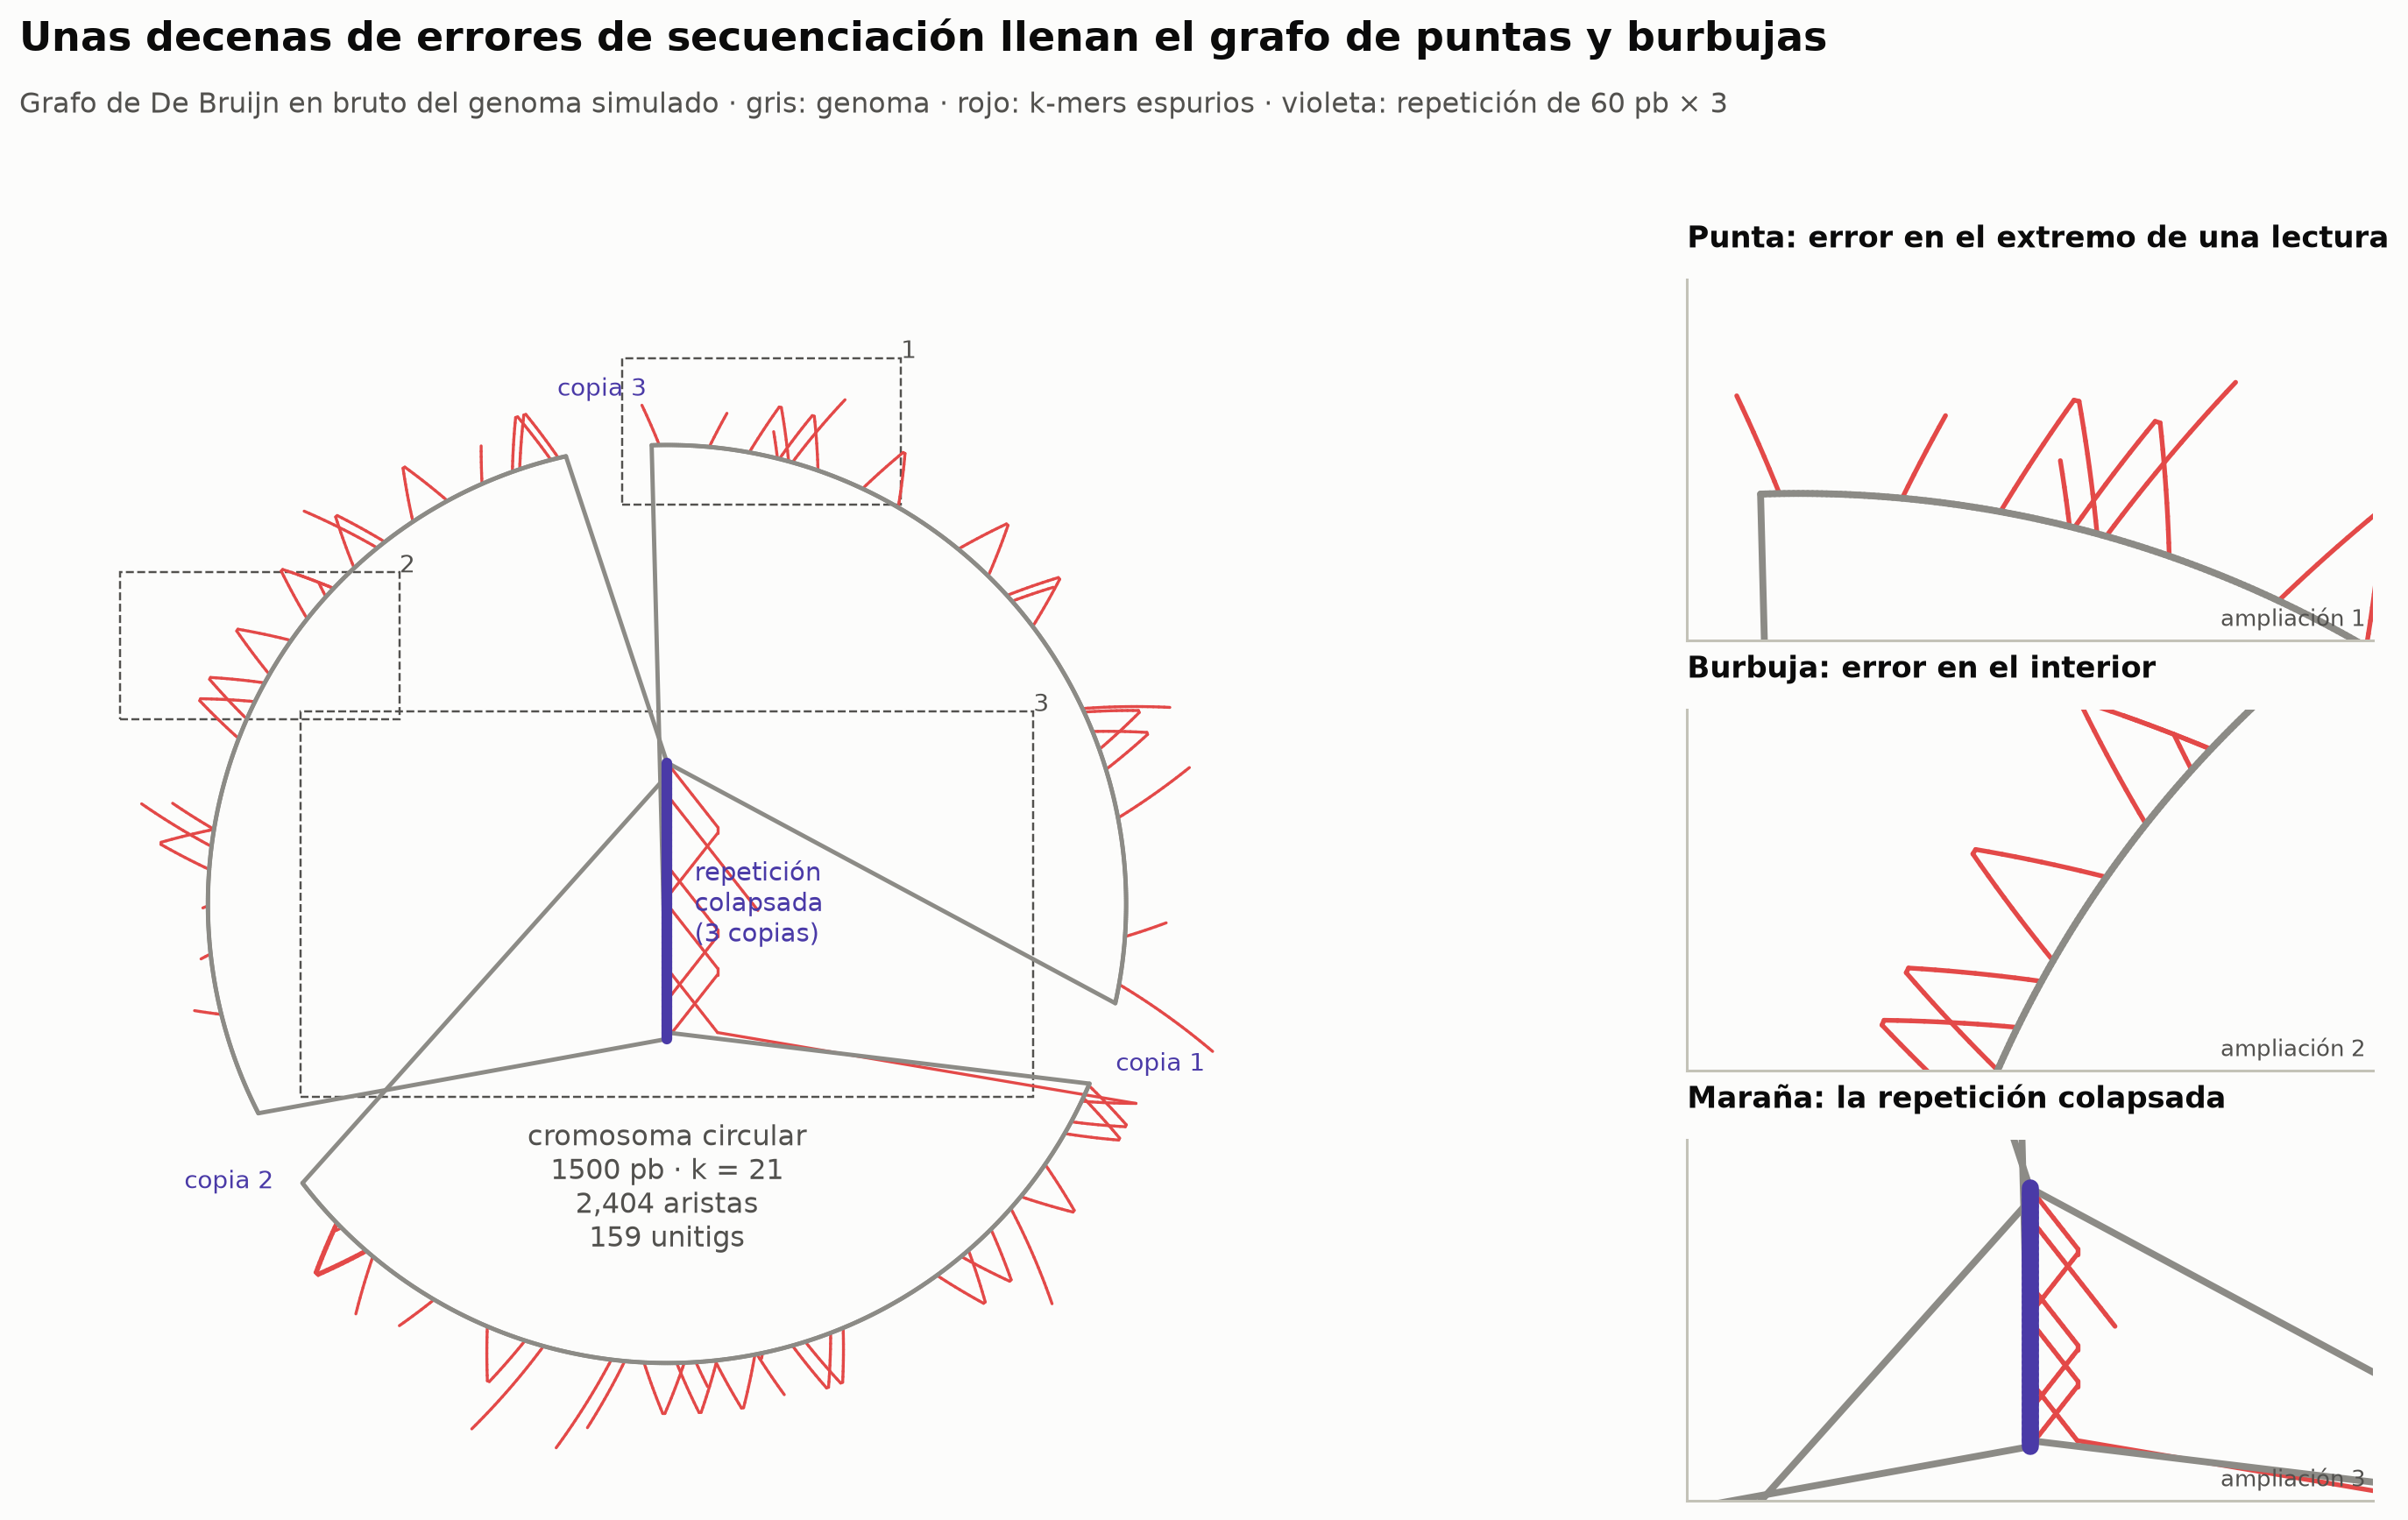

In [22]:
def circle_xy(coord, radius=1.0):
    ang = np.pi / 2 - 2 * np.pi * coord / G_LEN            # sentido horario desde las 12
    return radius * np.cos(ang), radius * np.sin(ang)

REP_H = 0.28                                                 # la repetición colapsada se dibuja en el centro
node_mult = Counter(kmers(circ[:G_LEN + K - 2], K - 1))       # (k-1)-mers presentes más de una vez en el genoma
STEP = 2 * REP_H / (R_LEN - K + 1)

def genome_node_xy(i):
    """Posición del (k-1)-mer que empieza en la coordenada i del genoma: en el círculo, o en el centro si está
    repetido en el genoma (las copias comparten el mismo nodo)."""
    if node_mult[circ[i:i + K - 1]] > 1:
        s0 = min(rep_starts, key=lambda s_: abs(i - s_))
        return (0.0, REP_H - STEP * (i - s0)), True
    return circle_xy(i + (K - 1) / 2), False

node_pos, center = {}, set()
for i in range(G_LEN):                                       # nodos del genoma
    xy, in_rep = genome_node_xy(i)
    node_pos.setdefault(circ[i:i + K - 1], xy)
    if in_rep: center.add(circ[i:i + K - 1])
true_nodes = set(node_pos)
for r, p in zip(sim_reads, sim_origin):                       # nodos erróneos: hacia fuera de su vecino verdadero
    nd = [r[i:i + K - 1] for i in range(L_READ - K + 2)]
    ok = np.array([n in true_nodes for n in nd])
    if ok.all():
        continue
    good = np.nonzero(ok)[0]
    for i, n in enumerate(nd):
        if not ok[i] and n not in node_pos:
            j = good[np.argmin(np.abs(good - i))] if len(good) else None
            d = abs(i - j) if j is not None else i + 1
            if j is not None and nd[j] in center:            # el vecino verdadero está en la repetición
                x0, y0 = node_pos[nd[j]]
                node_pos[n] = (x0 + 0.011 * d, y0 - STEP * (i - j))
            else:
                node_pos[n] = circle_xy(p + i + (K - 1) / 2, 1.0 + 0.011 * d)

def draw_sim_graph(ax, counts, highlight=None, lw_scale=1.0):
    """Dibuja el grafo {k-mer: cobertura}: gris = genoma, violeta = repetición colapsada, rojo = errores."""
    layers = {"error": [], "genome": [], "repeat": [], "next": []}
    for x in counts:
        a, b = x[:-1], x[1:]
        if a not in node_pos or b not in node_pos:
            continue
        seg = [node_pos[a], node_pos[b]]
        if highlight is not None and x in highlight:
            layers["next"].append(seg)
        elif a in center and b in center:
            layers["repeat"].append(seg)
        elif x in true_kmers:
            layers["genome"].append(seg)
        else:
            layers["error"].append(seg)
    style = {"error": (ec.RED, 1.1), "genome": ("#8c8b86", 1.6), "repeat": (ec.VIOLET, 4.0), "next": (ec.ORANGE, 3.2)}
    for name, segs_ in layers.items():                       # orden de dibujo: el violeta y el naranja encima
        if segs_:
            col, lw = style[name]
            ax.add_collection(LineCollection(segs_, colors=col, linewidths=lw * lw_scale, capstyle="round"))
    ax.set_aspect("equal"); ax.axis("off")

# ejemplos para las ampliaciones: una punta y una burbuja lejos de la repetición
def first_error(kind):
    for r, p, errs in zip(sim_reads, sim_origin, sim_errors):
        for j in errs:
            far = all(min(abs(p + j - s), abs(p + j - s - R_LEN)) > 120 for s in rep_starts)
            if far and kind == "tip" and (j < 6 or j > L_READ - 7):
                return p + j
            if far and kind == "bubble" and K < j < L_READ - K:
                return p + j
tip_at, bub_at = first_error("tip"), first_error("bubble")

fig = plt.figure(figsize=(14, 7.2))
ax0 = fig.add_axes([0.0, 0.02, 0.5, 0.86])
draw_sim_graph(ax0, counts_raw)
ax0.set_xlim(-1.3, 1.3); ax0.set_ylim(-1.3, 1.3)
for n_c, s0 in enumerate(rep_starts, 1):
    x, y = circle_xy(s0 + R_LEN / 2, 1.13)
    ax0.text(x, y, f"copia {n_c}", ha="center", va="center", fontsize=9, color=ec.VIOLET)
ax0.text(0.06, 0.0, "repetición\ncolapsada\n(3 copias)", ha="left", va="center", fontsize=9.5, color=ec.VIOLET)
ax0.text(0, -0.62, f"cromosoma circular\n{G_LEN} pb · k = {K}\n{len(counts_raw):,} aristas\n{len(unitigs(counts_raw))} unitigs",
         ha="center", va="center", fontsize=10.5, color=ec.INK_2)
zooms = [("Punta: error en el extremo de una lectura", tip_at),
         ("Burbuja: error en el interior", bub_at),
         ("Maraña: la repetición colapsada", None)]
for i, (ttl, coord) in enumerate(zooms):
    axz = fig.add_axes([0.53, 0.64 - i * 0.31, 0.45, 0.26])
    draw_sim_graph(axz, counts_raw, lw_scale=1.6)
    cx, cy = circle_xy(coord, 1.05) if coord is not None else (0.0, 0.0)
    half = 0.16 if i < 2 else 0.42
    axz.set_xlim(cx - half * 1.9, cx + half * 1.9); axz.set_ylim(cy - half, cy + half)
    axz.set_title(ttl, loc="left", fontsize=11)
    axz.axis("on"); axz.set_xticks([]); axz.set_yticks([])
    for sp in axz.spines.values():
        sp.set_color(ec.BASELINE)
    ax0.add_patch(Rectangle((cx - half * 1.9, cy - half), half * 3.8, 2 * half, fill=False, ec=ec.INK_2, lw=0.8, ls="--"))
    ax0.text(cx + half * 1.9, cy + half, str(i + 1), fontsize=9, color=ec.INK_2)
    axz.text(0.99, 0.04, f"ampliación {i + 1}", transform=axz.transAxes, ha="right", fontsize=8.5, color=ec.INK_2)
ec.fig_title(fig, "Unas decenas de errores de secuenciación llenan el grafo de puntas y burbujas",
             "Grafo de De Bruijn en bruto del genoma simulado · gris: genoma · rojo: k-mers espurios · violeta: repetición de 60 pb × 3")
plt.show()

> 🔎 **Qué observamos.** Cada espina roja que sale del círculo es una **punta** (el error estaba a menos de $k$ bases del
> final de la lectura, así que el camino erróneo no llega a reunirse con el genoma), y cada arco rojo que sale y vuelve
> es una **burbuja** de exactamente $k$ aristas. En la ampliación 3, la repetición (violeta) está dibujada una sola vez:
> tres caminos grises llegan a ella y tres salen. Es la **maraña** del libro, con cobertura triple. Nada en el grafo
> dice cuál entrada corresponde a cuál salida.

### 7.4 Limpieza del grafo: poda de puntas y eliminación de burbujas

Velvet (Zerbino y Birney, 2008), el primer ensamblador de De Bruijn de uso generalizado para las lecturas de 25–50 nt de
los primeros secuenciadores Solexa/Illumina, introdujo un conjunto de operaciones de limpieza que hoy usan, con
variantes, todos los ensambladores:

1. **Compactar** los caminos no ramificados en unitigs.
2. **Podar puntas**: eliminar los unitigs que terminan en un callejón, son **cortos** (a lo sumo $2k$ aristas) y
   tienen **poca cobertura**.
3. **Reventar burbujas**: cuando dos caminos cortos salen del mismo nodo y llegan al mismo nodo, conservar el mejor
   cubierto. Velvet lo hace con un recorrido en anchura llamado *Tour Bus*; nosotros usaremos una versión simple:
   para cada unitig poco cubierto que une dos nodos ramificados, buscamos (en anchura) **otro** camino corto entre
   los mismos nodos; si existe y su cobertura es mucho mayor, el unitig es un error.
4. Repetir hasta que nada cambie, porque cada eliminación puede dejar nuevas puntas o fusionar unitigs.

Las reglas usan sólo **longitud** y **cobertura**, nunca la verdad de la simulación.

In [23]:
def mean_cov(counts, path):
    return float(np.mean([counts[x] for x in path]))

def alt_path(counts, out, a, b, banned, max_len):
    """Busca en anchura otro camino de a hasta b (a lo sumo max_len aristas) que no use las aristas prohibidas."""
    frontier, seen = [(a, [])], {a}
    for _ in range(max_len):
        nxt = []
        for n, p in frontier:
            for x in out[n]:
                if x in banned or x not in counts:
                    continue
                if x[1:] == b:
                    return p + [x]
                if x[1:] not in seen:
                    seen.add(x[1:]); nxt.append((x[1:], p + [x]))
        frontier = nxt
    return None

def clip_tips(counts, max_len, max_cov, log):
    out, inn = adjacency(counts)
    changed = False
    for u in unitigs(counts):
        dead_end = len(inn[u[0][:-1]]) == 0 or len(out[u[-1][1:]]) == 0
        if dead_end and len(u) <= max_len and mean_cov(counts, u) < max_cov:
            for x in u:
                counts.pop(x, None)
            log.append(("punta", u)); changed = True
    return changed

def pop_bubbles(counts, max_len, ratio, log):
    out, inn = adjacency(counts)
    changed = False
    for u in sorted(unitigs(counts), key=lambda u: mean_cov(counts, u)):   # primero los menos cubiertos
        if len(u) > max_len or any(x not in counts for x in u):
            continue
        a, b = u[0][:-1], u[-1][1:]
        if len(out[a]) < 2 or len(inn[b]) < 2:
            continue
        alt = alt_path(counts, out, a, b, set(u), max_len + K)
        if alt and mean_cov(counts, u) < ratio * mean_cov(counts, alt):
            for x in u:
                counts.pop(x, None)
            log.append(("burbuja", u)); changed = True
    return changed

def clean_graph(counts, max_len=2 * K, max_cov=5, ratio=0.35):
    """Poda de puntas + eliminación de burbujas, repetidas hasta que el grafo no cambie."""
    counts, log = dict(counts), []
    for _ in range(10):
        a = clip_tips(counts, max_len, max_cov, log)
        b = pop_bubbles(counts, max_len, ratio, log)
        if not (a or b):
            break
    return counts, log

t0 = time.perf_counter()
counts_clean, clean_log = clean_graph(counts_raw)
uts = unitigs(counts_clean)
print(f"Limpieza en {time.perf_counter() - t0:.2f} s: {Counter(k for k, _ in clean_log)}")
print(f"Aristas: {len(counts_raw):,} → {len(counts_clean):,} · unitigs: {len(unitigs(counts_raw))} → {len(uts)}")
print(f"k-mers espurios que quedan: {sum(x not in true_kmers for x in counts_clean)} · "
      f"k-mers del genoma perdidos: {len(true_kmers - set(counts_clean))}")
print("\nUnitigs finales (longitud en pb, cobertura media):")
for u in sorted(uts, key=len, reverse=True):
    print(f"   {len(u) + K - 1:>5} pb   cobertura {mean_cov(counts_clean, u):5.1f}"
          + ("   ← repetición colapsada" if mean_cov(counts_clean, u) > 2 * COV * (L_READ - K + 1) / L_READ else ""))

Limpieza en 0.01 s: Counter({'burbuja': 33, 'punta': 29})
Aristas: 2,404 → 1,417 · unitigs: 159 → 6
k-mers espurios que quedan: 0 · k-mers del genoma perdidos: 0

Unitigs finales (longitud en pb, cobertura media):
     520 pb   cobertura  10.4
     457 pb   cobertura  10.1
     457 pb   cobertura  10.8
      60 pb   cobertura  37.0   ← repetición colapsada
      22 pb   cobertura  30.0   ← repetición colapsada
      21 pb   cobertura  16.0


> 🔎 **Qué observamos.** La limpieza elimina **todos** los $k$-mers espurios sin perder ninguno del genoma, y el grafo
> pasa de más de cien unitigs a unos pocos. Lo que queda **no** es un solo contig: son los tres tramos únicos más la
> repetición, con **cobertura triple**, y quizá algún unitig diminuto donde, por azar, las bases vecinas de dos copias
> coinciden y alargan la repetición un par de bases. Ninguna limpieza puede eliminar la maraña, porque no es un error:
> es el genoma. La animación siguiente muestra la limpieza estructura por estructura.

![Limpieza del grafo simulado: primero se podan las puntas (espinas rojas) y luego se revientan las burbujas (arcos rojos); al final sólo quedan el cromosoma y la repetición colapsada (violeta)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.2_limpieza_grafo.gif)

*Limpieza del grafo simulado: primero se podan las puntas (espinas rojas) y luego se revientan las burbujas (arcos rojos); al final sólo quedan el cromosoma y la repetición colapsada (violeta)*

In [24]:
tips_log = [u for kind, u in clean_log if kind == "punta"]
bub_log = [u for kind, u in clean_log if kind == "burbuja"]
BATCH = 3
stages = [("En bruto", 0, 0)] * 4
stages += [("Poda de puntas", min(i, len(tips_log)), 0) for i in range(BATCH, len(tips_log) + BATCH, BATCH)]
stages += [("Poda de puntas", len(tips_log), 0)] * 2
stages += [("Burbujas", len(tips_log), min(i, len(bub_log))) for i in range(BATCH, len(bub_log) + BATCH, BATCH)]
stages += [("Grafo limpio", len(tips_log), len(bub_log))] * 6
removed_order = [u for u in tips_log] + [u for u in bub_log]

fig = plt.figure(figsize=(8.6, 8.2))
fig.set_layout_engine("none")
ax = fig.add_axes([0.02, 0.02, 0.96, 0.84])

def update(f):
    ax.clear()
    stage, nt, nb_ = stages[f]
    gone = {x for u in tips_log[:nt] + bub_log[:nb_] for x in u}
    nxt = (tips_log[nt:nt + BATCH] if stage == "Poda de puntas" and nt < len(tips_log)
           else bub_log[nb_:nb_ + BATCH] if stage == "Burbujas" and nb_ < len(bub_log) else [])
    counts_f = {x: c for x, c in counts_raw.items() if x not in gone}
    draw_sim_graph(ax, counts_f, highlight={x for u in nxt for x in u})
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    n_u = len(unitigs(counts_f))
    n_sp = sum(x not in true_kmers for x in counts_f)
    ax.text(0.0, 1.0, f"{stage}", ha="left", va="top", fontsize=15, fontweight="bold", color=ec.INK,
            transform=ax.transAxes)
    ax.text(0.0, 0.93, f"puntas podadas: {nt}/{len(tips_log)}\nburbujas: {nb_}/{len(bub_log)}\n"
                      f"k-mers espurios: {n_sp}\nunitigs: {n_u}", ha="left", va="top", fontsize=11, color=ec.INK_2,
            transform=ax.transAxes)
    ax.set_title("Limpieza del grafo de De Bruijn (naranja: lo que se elimina a continuación)", loc="left",
                 fontsize=12.5, pad=12)
    return []

anim_clean = ec.animate(fig, update, frames=len(stages), interval=450, name="8.2_limpieza_grafo")
print("cuadros:", len(stages))
anim_clean

cuadros: 33


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### 7.5 La alternativa rápida: descartar los $k$-mers por debajo del valle

Muchos ensambladores, antes de construir el grafo, **corrigen las lecturas** o simplemente descartan los $k$-mers con
cobertura por debajo del **valle** del espectro (Lección 8.1). SPAdes, por ejemplo, corrige las lecturas con BayesHammer
antes de ensamblar. Comparemos esa estrategia con la limpieza del grafo.

In [25]:
rows = []
for thr in (1, 2, 3, 4, 6):
    kept = {x: c for x, c in counts_raw.items() if c >= thr}
    rows.append(dict(umbral=f"cobertura ≥ {thr}", aristas=len(kept),
                     **{"espurios que quedan": sum(x not in true_kmers for x in kept),
                        "k-mers del genoma perdidos": len(true_kmers - set(kept)),
                        "unitigs": len(unitigs(kept))}))
rows.append(dict(umbral="limpieza del grafo (7.4)", aristas=len(counts_clean),
                 **{"espurios que quedan": sum(x not in true_kmers for x in counts_clean),
                    "k-mers del genoma perdidos": len(true_kmers - set(counts_clean)), "unitigs": len(uts)}))
print(pd.DataFrame(rows).set_index("umbral").to_string())

                          aristas  espurios que quedan  k-mers del genoma perdidos  unitigs
umbral                                                                                     
cobertura ≥ 1                2404                  987                           0      159
cobertura ≥ 2                1417                    0                           0        6
cobertura ≥ 3                1417                    0                           0        6
cobertura ≥ 4                1417                    0                           0        6
cobertura ≥ 6                1371                    0                          46       12
limpieza del grafo (7.4)     1417                    0                           0        6


> 🔎 **Qué observamos.** Un umbral de 2 ya elimina todos los espurios (en esta simulación ningún error se repitió en
> dos lecturas, algo muy improbable con errores al azar), pero umbrales altos empiezan a **borrar $k$-mers verdaderos** de las zonas con poca cobertura por azar, y
> cada $k$-mer verdadero perdido **rompe** el cromosoma en un unitig más. La limpieza del grafo es más fina porque mira
> la **estructura** (callejón, camino paralelo) además de la cobertura.

> ⚠️ **Cuidado: podar demasiado borra biología.** Las operaciones de limpieza se basan en la cobertura: lo poco cubierto
> se considera error. Pero hay biología genuina con poca cobertura: alelos minoritarios en un metagenoma o en una
> población bacteriana que evoluciona (¡como las del experimento de Lenski!), plásmidos de baja copia, regiones ricas
> en GC infrarrepresentadas por la PCR (Lección 6.3). Y reventar burbujas funde los dos haplotipos de un diploide en un
> mosaico que no existe en ninguna célula. Si su pregunta biológica depende de variantes de baja frecuencia o de la
> fase de los haplotipos, un ensamblaje "limpio" puede haber borrado justamente la respuesta.

## 8. Repeticiones, pares y lecturas largas

El análisis del ejemplo de juguete se generaliza. Una repetición de longitud $R$ sólo puede resolverse si alguna pieza
de información la **atraviesa de lado a lado**, anclada en secuencia única a ambos lados. Piense en dos calles
idénticas de una ciudad: para saber por cuál entró un taxi y por cuál salió, necesita una foto que muestre a la vez la
entrada y la salida. Hay tres maneras de conseguir esa foto:

* un **$k$-mer con $k > R+1$**, lo que exige lecturas más largas que $R$ y buena cobertura con $k$ grande;
* un **par de lecturas** cuya distancia (el tamaño del inserto) sea mayor que $R$, de modo que una lectura caiga a cada
  lado;
* una **lectura larga**, de PacBio u Oxford Nanopore, que contenga la repetición completa.

### 8.1 Subir $k$ en el genoma simulado

> 🤔 **Antes de ejecutar, prediga.** El genoma simulado tiene una repetición de 60 pb en tres copias. ¿A partir de qué
> $k$ el grafo del genoma (sin errores) se convierte en un único ciclo?

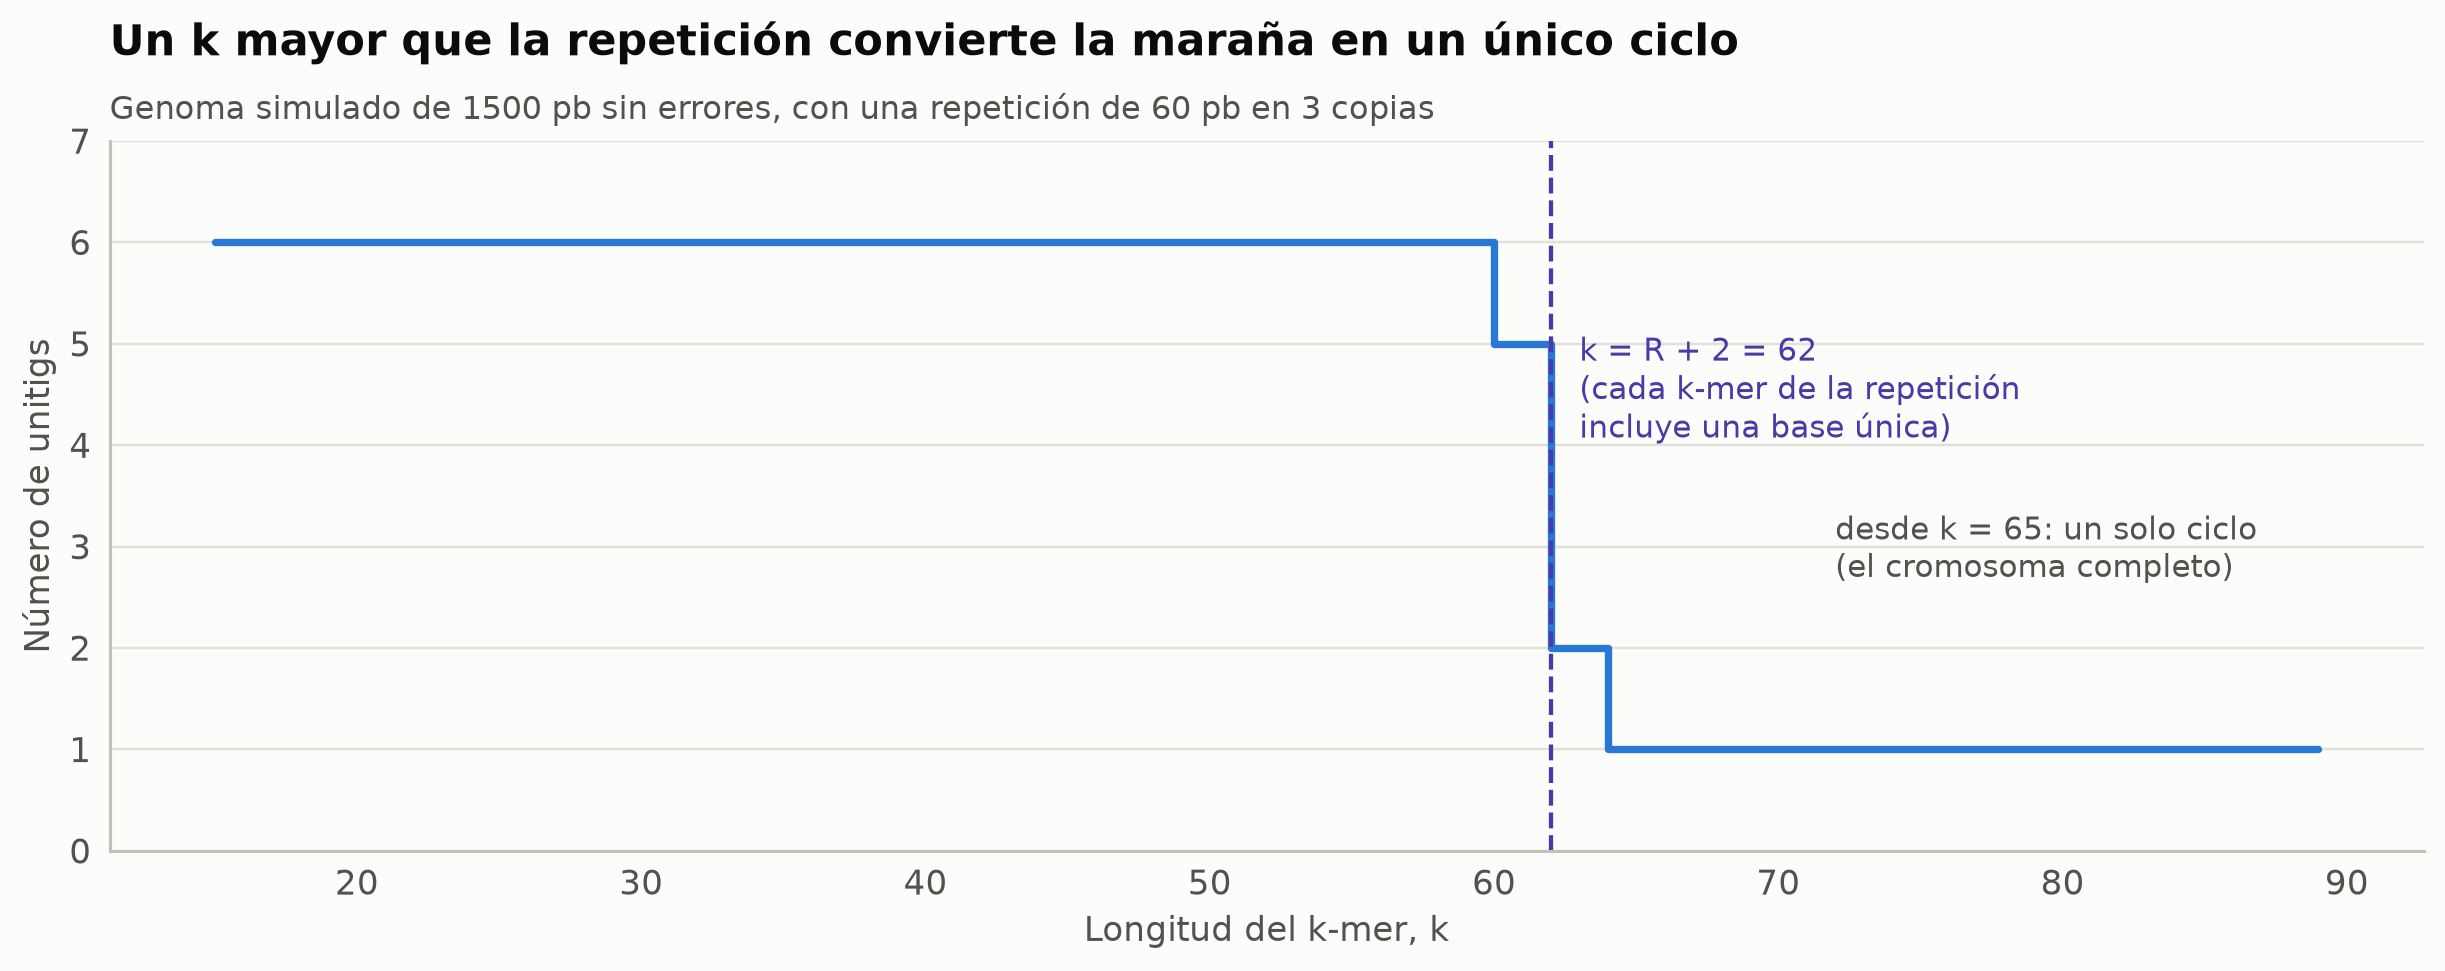

In [26]:
def genome_counts(seq, k, circular=True):
    s = seq + seq[:k - 1] if circular else seq
    return Counter(kmers(s, k))

ks_scan = list(range(15, 91, 2))
n_unitigs = [len(unitigs(genome_counts(genome_sim, k))) for k in ks_scan]
fig, ax = plt.subplots(figsize=(11, 4.3))
ax.step(ks_scan, n_unitigs, where="mid", color=ec.BLUE, lw=2.4)
ax.axvline(R_LEN + 2, color=ec.VIOLET, ls="--", lw=1.4)
ax.text(R_LEN + 3, max(n_unitigs) * 0.85, f"k = R + 2 = {R_LEN + 2}\n(cada k-mer de la repetición\nincluye una base única)",
        color=ec.VIOLET, fontsize=10, va="top")
first_one = next(k for k, n in zip(ks_scan, n_unitigs) if n == 1)
ax.annotate(f"desde k = {first_one}: un solo ciclo\n(el cromosoma completo)", (first_one, 1),
            xytext=(first_one + 7, max(n_unitigs) * 0.45), fontsize=10, color=ec.INK_2,
            arrowprops=dict(arrowstyle="->", color=ec.INK_2))
ax.set_xlabel("Longitud del k-mer, k"); ax.set_ylabel("Número de unitigs")
ax.set_ylim(0, max(n_unitigs) + 1)
ec.title(ax, "Un k mayor que la repetición convierte la maraña en un único ciclo",
         f"Genoma simulado de {G_LEN} pb sin errores, con una repetición de {R_LEN} pb en 3 copias")
plt.show()

> 🔎 **Qué observamos.** Mientras $k \le R+1$, la repetición existe como nodo del grafo y el cromosoma queda partido en
> los tramos que la rodean. Un par de pasos después de ese umbral el grafo es un único ciclo: el ensamblaje perfecto.
> (No exactamente en $R+2$ porque, por azar, la base vecina de dos de las copias coincide, lo que alarga en una o dos
> bases la repetición "efectiva": el grafo sólo ve secuencia, no nuestras etiquetas.) Con
> una salvedad crucial: aquí usamos el genoma **completo**, como si tuviéramos lecturas infinitamente largas. En la
> práctica $k$ no puede superar la longitud de la lectura (150 nt en nuestro clon), y cerca de ese límite faltan
> muchos $k$-mers. Contra una repetición de 5 kb, subir $k$ no sirve de nada.

### 8.2 ¿Qué fracción de la información atraviesa una repetición de longitud $R$?

Para que un fragmento resuelva una repetición no basta con que la cubra: debe **anclarse** en secuencia única a
ambos lados, digamos con al menos $a$ bases (usaremos $a = 21$, un $k$-mer). Un fragmento de longitud $I$ que empieza
al azar resuelve la repetición si $I \ge R + 2a$. Para lecturas pareadas, $I$ es el **tamaño del inserto**. Usaremos
la distribución **real** de insertos del clon del LTEE, la que medimos con BWA-MEM en la Lección 7.2 (guardada como
histograma en `data/82_insert_sizes.tsv`, porque rehacerla exige el BAM y pysam). Para las lecturas largas, las
longitudes de las lecturas simuladas tipo Nanopore de la misma lección.

Además del **porcentaje**, importa el **número esperado** de fragmentos que atraviesan una copia. Si los $N_p$
fragmentos empiezan uniformemente en un genoma de tamaño $G$, el número que atraviesa una repetición es

$$
\mathbb{E}[\#\text{fragmentos que atraviesan}] \;=\; \frac{N_p}{G}\sum_{I \ge R+2a} \bigl(I - R - 2a + 1\bigr)\,P(I),
$$

| Símbolo | Significado |
|---|---|
| $N_p$ | Número de fragmentos secuenciados (pares, o lecturas largas) |
| $G$ | Tamaño del genoma (4 629 812 pb para REL606) |
| $I$ | Longitud del fragmento (inserto del par, o longitud de la lectura larga) |
| $P(I)$ | Distribución de esas longitudes |
| $a$ | Bases únicas exigidas a cada lado para anclar el fragmento |
| $R$ | Longitud de la repetición |

porque un fragmento de longitud $I$ sirve si empieza en alguna de las $I - R - 2a + 1$ posiciones adecuadas.

In [27]:
ins_tab = pd.read_csv(io.StringIO(course_text("82_insert_sizes.tsv")), sep="\t", comment="#")
ins_len = ins_tab.bin_start.values + 5.0                    # centro de cada intervalo de 10 pb
ins_p = ins_tab.n_pairs.values / ins_tab.n_pairs.sum()
long_reads = read_fasta("sim_REL606_long.fasta.gz")
lr_len = np.array([len(s) for s in long_reads.values()])
feat = pd.read_csv(io.StringIO(course_text("NC_012967.1_features.tsv.gz")), sep="\t", comment="#")
rrna = feat[feat.type == "rRNA"].sort_values("start")
# operones: 16S … 5S consecutivos (a menos de 1 kb entre genes)
operons, cur = [], None
for _, r in rrna.iterrows():
    if cur and r.start - cur[1] < 1000:
        cur[1] = max(cur[1], r.end)
    else:
        if cur: operons.append(cur)
        cur = [r.start, r.end]
operons.append(cur)
op_len = np.median([e - s + 1 for s, e in operons])
IS150_LEN = 1444                                           # el segmento IS del grafo real (sección 9)
N_PAIRS, G_REL, READ_LEN, A = 1_553_259, 4_629_812, 150, 21
print(f"Insertos (30 000 pares reales): mediana {np.median(np.repeat(ins_len, ins_tab.n_pairs)):.0f} pb, "
      f"percentil 99,9 = {np.percentile(np.repeat(ins_len, ins_tab.n_pairs), 99.9):.0f} pb")
print(f"Lecturas largas simuladas (Lección 7.2): {len(lr_len)}, mediana {np.median(lr_len):,.0f} nt, máx {lr_len.max():,} nt")
print(f"Operones rRNA de REL606: {len(operons)}, longitud mediana {op_len:,.0f} pb (16S–23S–5S)")

def frac_span(lengths, probs, R, a=A):
    return float(np.sum(probs[lengths >= R + 2 * a]))

def expected_span(lengths, probs, R, n_frag, G=G_REL, a=A):
    m = lengths >= R + 2 * a
    return n_frag / G * float(np.sum((lengths[m] - R - 2 * a + 1) * probs[m]))

lr_p = np.ones(len(lr_len)) / len(lr_len)
for R, name in ((60, "repetición simulada"), (300, "300 pb"), (IS150_LEN, "IS150"), (op_len, "operón rRNA")):
    print(f"R = {R:>6,.0f} pb ({name:18s}): lectura de 150 nt {'sí' if READ_LEN >= R + 2 * A else 'no'} · "
          f"pares {frac_span(ins_len, ins_p, R):6.2%} (≈ {expected_span(ins_len, ins_p, R, N_PAIRS):6.1f} por copia con "
          f"los 1,55 M pares) · lecturas largas {frac_span(lr_len, lr_p, R):6.1%}")

Insertos (30 000 pares reales): mediana 555 pb, percentil 99,9 = 1345 pb
Lecturas largas simuladas (Lección 7.2): 148, mediana 6,870 nt, máx 18,779 nt
Operones rRNA de REL606: 7, longitud mediana 5,097 pb (16S–23S–5S)
R =     60 pb (repetición simulada): lectura de 150 nt sí · pares 92.93% (≈  144.6 por copia con los 1,55 M pares) · lecturas largas 100.0%
R =    300 pb (300 pb            ): lectura de 150 nt no · pares 69.09% (≈   80.1 por copia con los 1,55 M pares) · lecturas largas 100.0%
R =  1,444 pb (IS150             ): lectura de 150 nt no · pares  0.01% (≈    0.0 por copia con los 1,55 M pares) · lecturas largas 100.0%
R =  5,097 pb (operón rRNA       ): lectura de 150 nt no · pares  0.00% (≈    0.0 por copia con los 1,55 M pares) · lecturas largas  65.5%


La figura interactiva recorre todas las longitudes de repetición entre 10 pb y 20 kb. Pase el cursor por las curvas:
el recuadro indica, para cada $R$, qué fracción de los fragmentos lo atraviesa y cuántos se esperan por copia en el
experimento completo.

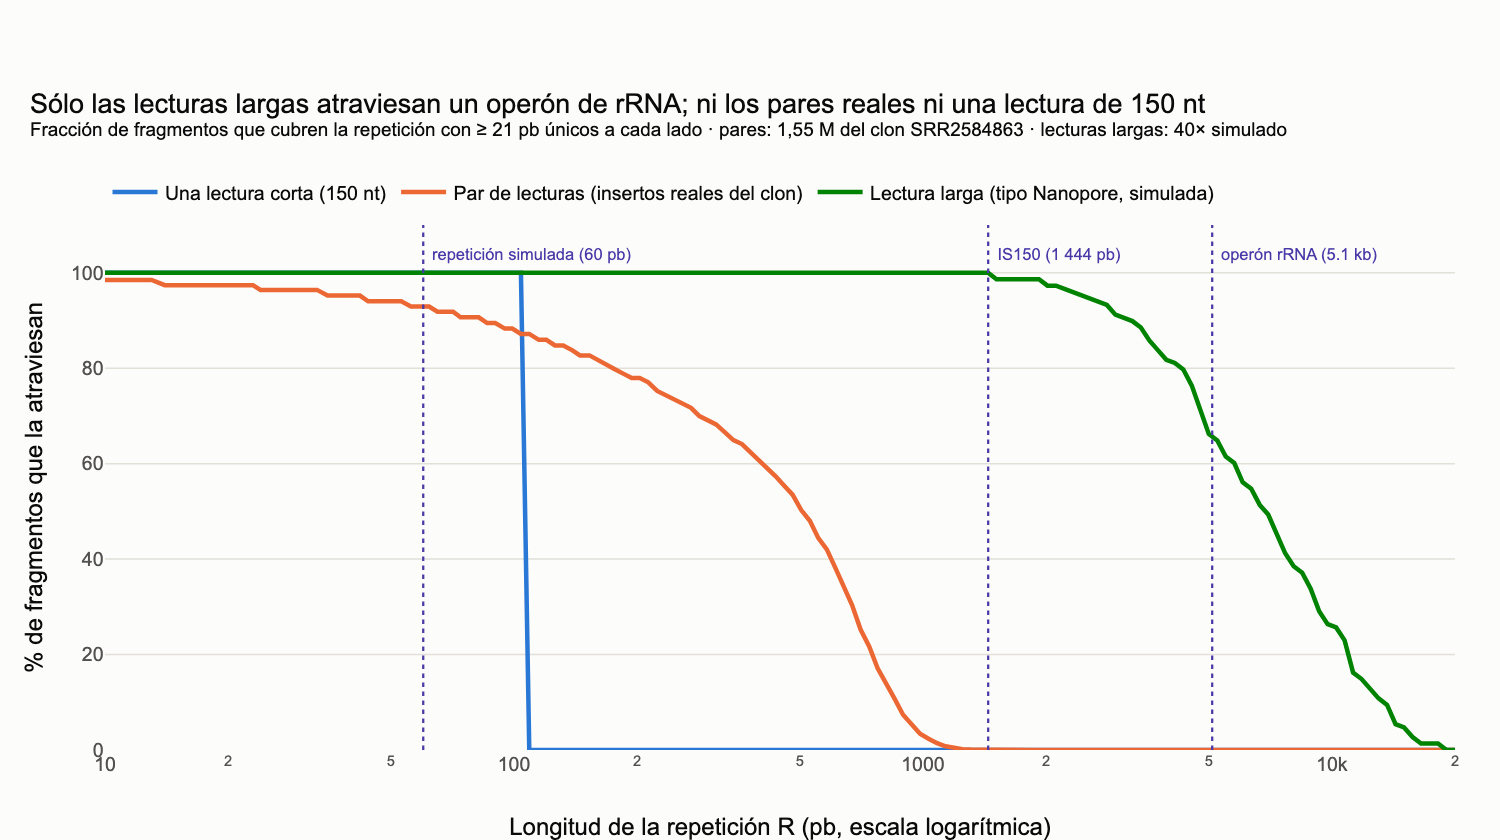

In [28]:
R_grid = np.unique(np.round(np.logspace(1, np.log10(20000), 160)))
series = {
    "Una lectura corta (150 nt)": (np.array([READ_LEN]), np.array([1.0]), N_PAIRS * 2, ec.BLUE),
    "Par de lecturas (insertos reales del clon)": (ins_len, ins_p, N_PAIRS, ec.ORANGE),
    "Lectura larga (tipo Nanopore, simulada)": (lr_len, lr_p, 40 * G_REL / lr_len.mean(), ec.GREEN),
}
fig = go.Figure()
for name, (lens, probs, nfrag, col) in series.items():
    fr = np.array([frac_span(lens, probs, R) for R in R_grid])
    ex = np.array([expected_span(lens, probs, R, nfrag) for R in R_grid])
    fig.add_trace(go.Scatter(x=R_grid, y=100 * fr, mode="lines", name=name, line=dict(color=col, width=3),
                             customdata=ex, hovertemplate=f"<b>{name}</b><br>R = %{{x:,.0f}} pb<br>"
                             "atraviesan con anclaje: %{y:.1f} % de los fragmentos<br>"
                             "≈ %{customdata:,.1f} fragmentos por copia en el experimento<extra></extra>"))
for R, lab in ((R_LEN, "repetición simulada (60 pb)"), (IS150_LEN, "IS150 (1 444 pb)"), (op_len, f"operón rRNA ({op_len/1000:.1f} kb)")):
    fig.add_vline(x=R, line=dict(color="#4a3aa7", dash="dot", width=1.5))
    fig.add_annotation(x=np.log10(R), y=104, text=lab, showarrow=False, font=dict(size=11, color="#4a3aa7"),
                       xanchor="left", xshift=4)
fig.update_layout(
    title=dict(text="Sólo las lecturas largas atraviesan un operón de rRNA; ni los pares reales ni una lectura de 150 nt"
                    "<br><sup>Fracción de fragmentos que cubren la repetición con ≥ 21 pb únicos a cada lado · "
                    "pares: 1,55 M del clon SRR2584863 · lecturas largas: 40× simulado</sup>"),
    xaxis=dict(type="log", title="Longitud de la repetición R (pb, escala logarítmica)", range=[1, np.log10(20000)]),
    yaxis=dict(title="% de fragmentos que la atraviesan", range=[0, 110]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=560, margin=dict(t=150, l=70, r=30, b=60))
fig.show()

> 🔎 **Qué observamos.** Una lectura de 150 nt sólo atraviesa repeticiones de hasta 108 pb ($150 - 2 \times 21$). Los
> pares del clon, con insertos de unos 550 pb, llegan más lejos, pero el 99,9 % queda por debajo de 1,35 kb: **prácticamente
> ningún par** atraviesa un IS150 (1 444 pb; menos de un par esperado por copia aun con los 1,55 millones de pares), y
> ninguno un operón de rRNA de unos 5 kb. Las lecturas largas simuladas (mediana ≈ 6,9 kb) atraviesan todas las copias
> de IS150 y dos tercios de ellas atraviesan un operón completo: con 40× eso son decenas de lecturas por copia, más que
> suficiente. Con las lecturas ultralargas actuales (N50 > 50 kb) casi ninguna repetición bacteriana resiste. Por eso las limitaciones del ensamblaje con
> lecturas cortas no se superan secuenciando **más**, sino secuenciando **más largo**. La teoría de Lander–Waterman
> (Lección 6.3) predice un único contig para una bacteria a $30\times$; en la práctica se obtienen decenas, uno por cada
> repetición que ni las lecturas ni los insertos de los pares consiguen atravesar.

> ✅ **Compruebe su comprensión.** Una biblioteca *mate-pair* tiene insertos de 5 000 ± 500 pb. ¿Resolvería los operones
> de rRNA? ¿Y un IS de 1,4 kb? (Pista: piense qué ocurre si $I$ es mucho mayor que $R$, pero la repetición cae entre las
> dos lecturas.)

## 9. 🧪 El grafo de ensamblaje real del clon del LTEE

Volvemos al hilo del curso: el clon de *E. coli* B del experimento de evolución a largo plazo de Lenski (LTEE,
SRR2584863), cuyas lecturas controlamos en la Lección 6.2 y mapeamos contra el ancestro REL606 en el Módulo 7. Imagine
que su laboratorio recibe este aislado y **no tiene** genoma de referencia: hay que ensamblarlo de novo. En la Lección
8.3 ejecutaremos SPAdes (Bankevich *et al.*, 2012) sobre todas las lecturas; aquí abrimos por dentro el resultado de un
ensamblaje más pequeño, precomputado con SPAdes 4 sobre **34 000 pares reales** (≈ 40×) que caen en una región de
250 kb del cromosoma (posiciones 3 950 001–4 200 000 de REL606).

Un detalle importante sobre esas lecturas: se **reclutaron por mapeo** contra la región. Las lecturas de secuencias
repetidas en el genoma (como los operones de rRNA) mapean con MAPQ 0 en cualquiera de sus copias (Lección 7.2), así
que algunas procedentes de **otras** partes del cromosoma cayeron aquí. Lo tendremos en cuenta al interpretar las
coberturas.

### 9.1 El formato GFA: el grafo tal como lo guarda el ensamblador

SPAdes escribe su grafo compactado en formato **GFA** (*Graphical Fragment Assembly*), un archivo de texto tabulado con
un tipo de registro por línea:

| Línea | Campos | Significado |
|---|---|---|
| `S` | id, secuencia, etiquetas | **Segmento**: un unitig (nodo del grafo compactado). `KC:i:` = suma de las coberturas de sus $k$-mers; `DP:f:` = cobertura media de $k$-mers |
| `L` | id₁, hebra₁, id₂, hebra₂, CIGAR | **Enlace**: el final de id₁ (en esa hebra) se solapa con el principio de id₂; `77M` = las dos secuencias comparten 77 bases (lo interpretaremos enseguida) |
| `P` | nombre, segmentos, … | **Camino**: un contig, como lista ordenada de segmentos con su hebra (`,` los une; `;` marca un salto sin secuencia) |
| `J` | id₁, hebra₁, id₂, hebra₂, … | **Salto** (*jump*): conexión inferida de lecturas pareadas, sin solapamiento de secuencia |

El signo `+`/`−` es la hebra: como el ensamblador no sabe de qué hebra vino cada lectura, cada segmento representa
a la vez una secuencia y su reverso complementario, y el grafo es **bidirigido**.

In [29]:
gfa_text = course_text("REL606_3950k-4200k_spades_graph.gfa.gz")
seg_rows, links, paths, jumps = [], [], {}, []
for line in gfa_text.splitlines():
    f = line.split("\t")
    if f[0] == "S":
        tags = {t[:2]: t[5:] for t in f[3:]}                 # etiquetas por prefijo (no por posición)
        seg_rows.append(dict(id=f[1], seq=f[2], length=len(f[2]), DP=float(tags.get("DP", "nan")),
                             KC=int(tags.get("KC", 0))))
    elif f[0] == "L":
        links.append((f[1], f[2], f[3], f[4], f[5]))
    elif f[0] == "P":
        paths[f[1]] = [(x[:-1], x[-1], sep) for part_i, part in enumerate(f[2].split(";"))
                       for sep, x in [("salto" if part_i and j == 0 else "", y) for j, y in enumerate(part.split(","))]]
    elif f[0] == "J":
        jumps.append((f[1], f[2], f[3], f[4]))
segs = pd.DataFrame(seg_rows).set_index("id")
overlaps = Counter(l[4] for l in links)
K_ASM = int(next(iter(overlaps))[:-1])
print(f"Segmentos: {len(segs)} · enlaces L: {len(links)} · caminos P (contigs): {len(paths)} · saltos J: {len(jumps)}")
print(f"Solapamientos de los enlaces: {dict(overlaps)} → SPAdes llama a este grafo «k = {K_ASM}»")
print(f"Longitud total de los segmentos: {segs.length.sum():,} pb (la región mide 250 000 pb)")
print(segs.drop(columns="seq").sort_values("length", ascending=False).head(8).to_string())

Segmentos: 97 · enlaces L: 111 · caminos P (contigs): 67 · saltos J: 2
Solapamientos de los enlaces: {'77M': 111} → SPAdes llama a este grafo «k = 77»
Longitud total de los segmentos: 255,771 pb (la región mide 250 000 pb)
       length       DP       KC
id                             
53206   91252  14.8931  1357877
53168   38043  15.4555   586783
53176   22726  16.1120   364921
53198   19220  16.0541   307323
53082   13992  16.4452   228835
53145   13960  14.1847   196926
53204   13428  14.8070   197688
53128    8367  14.0370   116367


Todos los enlaces son `77M`: dos segmentos consecutivos comparten 77 bases. SPAdes llama a esta ejecución "$k = 77$"
porque en **su** convención los **nodos** son $k$-mers (de 77 bases) y las **aristas** son $(k+1)$-mers. Con la
convención de este curso y del libro (nodos de $k-1$ bases, aristas de $k$), el mismo grafo tiene $k-1 = 77$, es
decir, **$k = 78$**. Es la misma idea con el índice desplazado en uno, y un recordatorio útil: **lea la documentación del
formato antes de interpretar un número**. (SPAdes eligió automáticamente $k \in \{21, 33, 55, 77\}$ para lecturas de
150 nt; el grafo final corresponde al mayor.)

Podemos comprobarlo con la cobertura. `KC` es la suma de las coberturas de las **aristas** del segmento; un segmento de
longitud $\ell$ contiene $\ell - k + 1$ aristas de $k$ bases, así que $\text{DP} = \text{KC}/(\ell - k + 1)$ debe
cumplirse exactamente con el $k$ correcto.

In [30]:
for k_try in (K_ASM, K_ASM + 1):
    err = np.abs(segs.KC / (segs.length - k_try + 1) - segs.DP) / segs.DP
    print(f"k = {k_try}: error relativo mediano de DP = KC/(ℓ − k + 1): {np.median(err):.2e}")
K_BOOK = K_ASM + 1                                           # k en la convención del libro (aristas = k-mers)
n_bub = int((segs.length == 2 * K_BOOK - 1).sum())
print(f"\nk en la convención del libro: {K_BOOK}. Segmentos de exactamente 2k − 1 = {2 * K_BOOK - 1} pb: {n_bub} "
      f"(la firma de una burbuja por un solo cambio de base)")

k = 77: error relativo mediano de DP = KC/(ℓ − k + 1): 1.27e-02
k = 78: error relativo mediano de DP = KC/(ℓ − k + 1): 4.42e-07

k en la convención del libro: 78. Segmentos de exactamente 2k − 1 = 155 pb: 11 (la firma de una burbuja por un solo cambio de base)


> 🔎 **Qué observamos.** Con $k = 78$ la fórmula se cumple al redondeo; con $77$ no. Y aparecen muchos segmentos de
> exactamente $2k-1 = 155$ pb: una base distinta contamina $k$ aristas consecutivas (sección 7), que ocupan
> $k + (k-1)$ bases. Son el lado de una **burbuja** de la sección 7 en tamaño real. Otra comprobación útil: `DP` es
> cobertura de **$k$-mers**, no de bases. Con ≈ 40× de bases y lecturas de 150 nt, la cobertura esperada es
> $c_k = c(L-k+1)/L \approx 40 \times 73/150 \approx 19$; los segmentos largos tienen DP ≈ 15, algo menos por los
> recortes de calidad y por las lecturas perdidas en el reclutamiento.

### 9.2 ¿De dónde viene cada segmento? Comparación con la referencia

Tenemos la verdad de campo: la secuencia de REL606 en esa región y la anotación del genoma completo. Para cada segmento
buscaremos sus $31$-mers (uno cada 10 bases, en ambas hebras) en el genoma entero. Así sabremos **cuántas copias**
tiene en el cromosoma y, usando sólo los $31$-mers de copia única, **dónde** cae dentro de la región (coordenadas
1–250 000; sume 3 950 000 para obtener la posición en REL606) y en qué hebra.

In [31]:
REGION_OFFSET = 3_950_000                                   # coordenada 0 de la región = posición 3 950 001 de REL606
region = next(iter(read_fasta("REL606_3950k-4200k.fasta.gz").values()))
rel606 = next(iter(read_fasta("NC_012967.1.fasta.gz").values()))
assert rel606[REGION_OFFSET:REGION_OFFSET + 100] == region[:100]
KQ, STRIDE = 31, 10

t0 = time.perf_counter()
probe = defaultdict(list)                                    # k-mer de sonda → [(segmento, hebra)]
for sid, sq in segs.seq.items():
    for i in range(0, len(sq) - KQ + 1, STRIDE):
        probe[sq[i:i + KQ]].append((sid, "+"))
        probe[revcomp(sq[i:i + KQ])].append((sid, "-"))
probe = dict(probe)
hits_genome = defaultdict(list)                              # segmento → [(posición 0-based en REL606, hebra, k-mer)]
occ = Counter()                                              # veces que cada sonda aparece en el genoma
for i in range(len(rel606) - KQ + 1):
    x = rel606[i:i + KQ]
    if x in probe:
        occ[x] += 1
        for sid, strand in probe[x]:
            hits_genome[sid].append((i, strand, x))
print(f"Búsqueda de {len(probe):,} sondas en {len(rel606):,} pb: {time.perf_counter() - t0:.1f} s")

rows = []
for sid, sq in segs.seq.items():
    n_probe = len(range(0, len(sq) - KQ + 1, STRIDE))
    h = hits_genome[sid]
    # sólo las sondas de copia única en el genoma sirven para ubicar el segmento sin ambigüedad
    uniq_h = [(i - REGION_OFFSET, st) for i, st, x in h
              if occ[x] + occ.get(revcomp(x), 0) == 1 and REGION_OFFSET <= i < REGION_OFFSET + len(region)]
    pos_u = np.array([i for i, _ in uniq_h])
    strand = Counter(st for _, st in uniq_h).most_common(1)[0][0] if uniq_h else ""
    rows.append(dict(id=sid, copies_genome=round(len(h) / max(n_probe, 1), 1),
                     n_hits_region=sum(REGION_OFFSET <= i < REGION_OFFSET + len(region) for i, _, _ in h),
                     reg_start=int(pos_u.min()) + 1 if len(pos_u) else np.nan,
                     reg_end=int(pos_u.max()) + KQ if len(pos_u) else np.nan, strand=strand))
segs = segs.join(pd.DataFrame(rows).set_index("id"))
print(segs.drop(columns="seq").sort_values("length", ascending=False).head(16).to_string())

Búsqueda de 50,304 sondas en 4,629,812 pb: 0.7 s
       length         DP       KC  copies_genome  n_hits_region  reg_start   reg_end strand
id                                                                                         
53206   91252  14.893100  1357877            1.0           9132    69116.0  160236.0      +
53168   38043  15.455500   586783            1.0           3729        2.0   37212.0      +
53176   22726  16.112000   364921            1.0           2262   160240.0  182880.0      +
53198   19220  16.054100   307323            1.0           1911    37138.0   56268.0      +
53082   13992  16.445200   228835            1.0           1397   209791.0  223781.0      -
53145   13960  14.184700   196926            1.0           1401   223705.0  237455.0      +
53204   13428  14.807000   197688            1.0           1345   182816.0  196186.0      -
53128    8367  14.037000   116367            1.1            841   201550.0  209860.0      +
53054    7418  14.943100   1096

Con la ubicación y el número de copias, clasificamos cada segmento con reglas simples (en orden):

1. **Adaptador / poli-G**: contiene el adaptador Nextera (`CTGTCTCTTATACACATCT`) o una racha de G, el artefacto de la
   química de dos colores de Illumina (Lección 6.2).
2. **Elemento IS150**: la mayoría de sus $31$-mers caen dentro de una transposasa IS150 anotada.
3. **rRNA**: la mayoría de sus $31$-mers caen dentro de un operón de ARN ribosómico (16S–23S–5S).
4. **Error / baja cobertura**: DP < 3.
5. **De otra parte del genoma**: no cae en la región (reclutado por error en el mapeo).
6. **Único**: todo lo demás, la secuencia de copia única de la región.

In [32]:
ADAPTER = "CTGTCTCTTATACACATCT"
is150 = feat[feat["product"].fillna("").str.contains("IS150")]
rrna_reg = rrna[(rrna.start > REGION_OFFSET) & (rrna.end <= REGION_OFFSET + len(region))]

def frac_in(sid, intervals):
    """Fracción de las sondas del segmento que caen dentro de algún intervalo (inicio, fin) 1-based del genoma."""
    h = np.array([i for i, _, _ in hits_genome[sid]]) + 1
    if len(h) == 0:
        return 0.0
    return float(np.mean(np.any([(h >= a) & (h + KQ - 1 <= b) for a, b in intervals], axis=0)))

is150_iv = list(zip(is150.start, is150.end))
segs["frac_rRNA"] = [frac_in(s_, operons) for s_ in segs.index]
segs["frac_IS150"] = [frac_in(s_, is150_iv) for s_ in segs.index]

def classify(sid):
    r = segs.loc[sid]
    if ADAPTER in r.seq or revcomp(ADAPTER) in r.seq or "G" * 20 in r.seq or "C" * 20 in r.seq:
        return "adaptador / poli-G"
    if r.frac_IS150 > 0.5:
        return "IS150"
    if r.frac_rRNA > 0.5:
        return "rRNA (operones colapsados)"
    if r.DP < 3:
        return "error / baja cobertura"
    if r.n_hits_region == 0:
        return "de otra parte del genoma"
    return "único"

segs["clase"] = [classify(s) for s in segs.index]
CLASS_COL = {"único": ec.BLUE, "rRNA (operones colapsados)": ec.ORANGE, "IS150": ec.VIOLET,
             "adaptador / poli-G": ec.MAGENTA, "error / baja cobertura": "#b4b3ad", "de otra parte del genoma": ec.AQUA}
summary = segs.groupby("clase").agg(segmentos=("length", "size"), pb=("length", "sum"),
                                    DP_mediana=("DP", "median"), copias_mediana=("copies_genome", "median"))
print(summary.sort_values("pb", ascending=False).round(1).to_string())
cov_unique = np.average(segs.DP[segs.clase == "único"], weights=segs.length[segs.clase == "único"])
cov_rrna = np.average(segs.DP[segs.clase.str.startswith("rRNA")], weights=segs.length[segs.clase.str.startswith("rRNA")])
print(f"\nCobertura de k-mers ponderada por longitud: única = {cov_unique:.1f} · rRNA = {cov_rrna:.1f} "
      f"→ cociente {cov_rrna / cov_unique:.1f}")

                            segmentos      pb  DP_mediana  copias_mediana
clase                                                                    
único                              18  237724        14.9             1.0
rRNA (operones colapsados)         40    9746        30.4             6.1
error / baja cobertura             12    4031         1.0             1.0
adaptador / poli-G                 26    2826        13.5             0.0
IS150                               1    1444        13.1             4.8

Cobertura de k-mers ponderada por longitud: única = 15.2 · rRNA = 39.1 → cociente 2.6


> 🔎 **Qué observamos.** Casi toda la región (≈ 238 kb) está en 18 segmentos **únicos** con cobertura ≈ 15, una sola
> copia en el genoma. Los segmentos de **rRNA** son muchos, cortos y con cobertura alta: los tres más largos tienen
> DP ≈ 55–58, unas **3,7 veces** la cobertura única, y los $31$-mers aparecen ≈ 7 veces en el genoma (los 7 operones
> *rrn* de *E. coli*). La región contiene 3 operones; el exceso de cobertura sobre 3× viene de lecturas de los otros
> operones reclutadas por el mapeo. Hay además un segmento de 1 444 pb con ≈ 5 copias en REL606 y **ninguna** en la
> región: un **IS150**. Y decenas de segmentos pequeños de adaptador Nextera y poli-G (el problema de la Lección 6.2),
> más una docena de restos de errores con DP ≈ 1.

### 9.3 El grafo dibujado como lo hace Bandage

**Bandage** (Wick *et al.*, 2015) es la herramienta estándar para mirar un grafo de ensamblaje: dibuja cada segmento
como una "salchicha" cuya **longitud es proporcional a su secuencia**, unida a sus vecinos por los enlaces. Haremos lo
mismo con networkx: cada segmento se convierte en una cadena de puntos (más puntos cuanto más largo) y los enlaces unen
el **final** de un segmento con el **principio** del siguiente según las hebras. Un algoritmo de fuerzas
(Kamada–Kawai) coloca los puntos. Dibujamos sólo el componente conexo principal; los segmentos sueltos, casi todos con
DP ≈ 1, se listan aparte.

In [33]:
und = nx.Graph()
und.add_nodes_from(segs.index)
und.add_edges_from((a, b) for a, _, b, _, _ in links)
und.add_edges_from((a, b) for a, _, b, _ in jumps)
comps = sorted(nx.connected_components(und), key=lambda c: -segs.loc[list(c), "length"].sum())
main = sorted(comps[0])                                     # orden fijo: el diseño es reproducible
loose = segs.loc[sorted(s_ for c in comps[1:] for s_ in c)].sort_values("length", ascending=False)
print(f"Componente principal: {len(main)} segmentos, {segs.loc[main, 'length'].sum():,} pb")
print(f"Segmentos sueltos: {len(loose)} (DP mediana {loose.DP.median():.1f}):",
      ", ".join(f"{i} ({r.length} pb, DP {r.DP:.1f})" for i, r in loose.head(6).iterrows()), "…")

# cadena de puntos por segmento y enlaces entre extremos
LG = nx.Graph()
chain = {}
for sid in main:
    n = int(np.clip(round(np.sqrt(segs.length[sid]) / 5), 2, 45))
    chain[sid] = [f"{sid}#{j}" for j in range(n)]
    nx.add_path(LG, chain[sid])

def end_point(sid, strand, leaving):
    """Punto por el que se sale de (leaving=True) o se entra a (False) un segmento recorrido en la hebra dada."""
    return chain[sid][-1] if (strand == "+") == leaving else chain[sid][0]

link_pairs = []
for a, sa, b, sb, _ in links:
    if a in main and b in main:
        p, q = end_point(a, sa, True), end_point(b, sb, False)
        if p != q:
            LG.add_edge(p, q); link_pairs.append((p, q))
jump_pairs = [(end_point(a, sa, True), end_point(b, sb, False)) for a, sa, b, sb in jumps if a in main and b in main]
LG.add_edges_from(jump_pairs)
t0 = time.perf_counter()
lay = nx.kamada_kawai_layout(LG)
print(f"Diseño de {LG.number_of_nodes()} puntos en {time.perf_counter() - t0:.1f} s")

Componente principal: 83 segmentos, 251,402 pb
Segmentos sueltos: 14 (DP mediana 1.1): 33947 (707 pb, DP 0.7), 34135 (481 pb, DP 1.7), 81219 (354 pb, DP 1.6), 50056 (347 pb, DP 1.3), 37993 (333 pb, DP 1.6), 48138 (287 pb, DP 0.7) …


Diseño de 459 puntos en 0.8 s


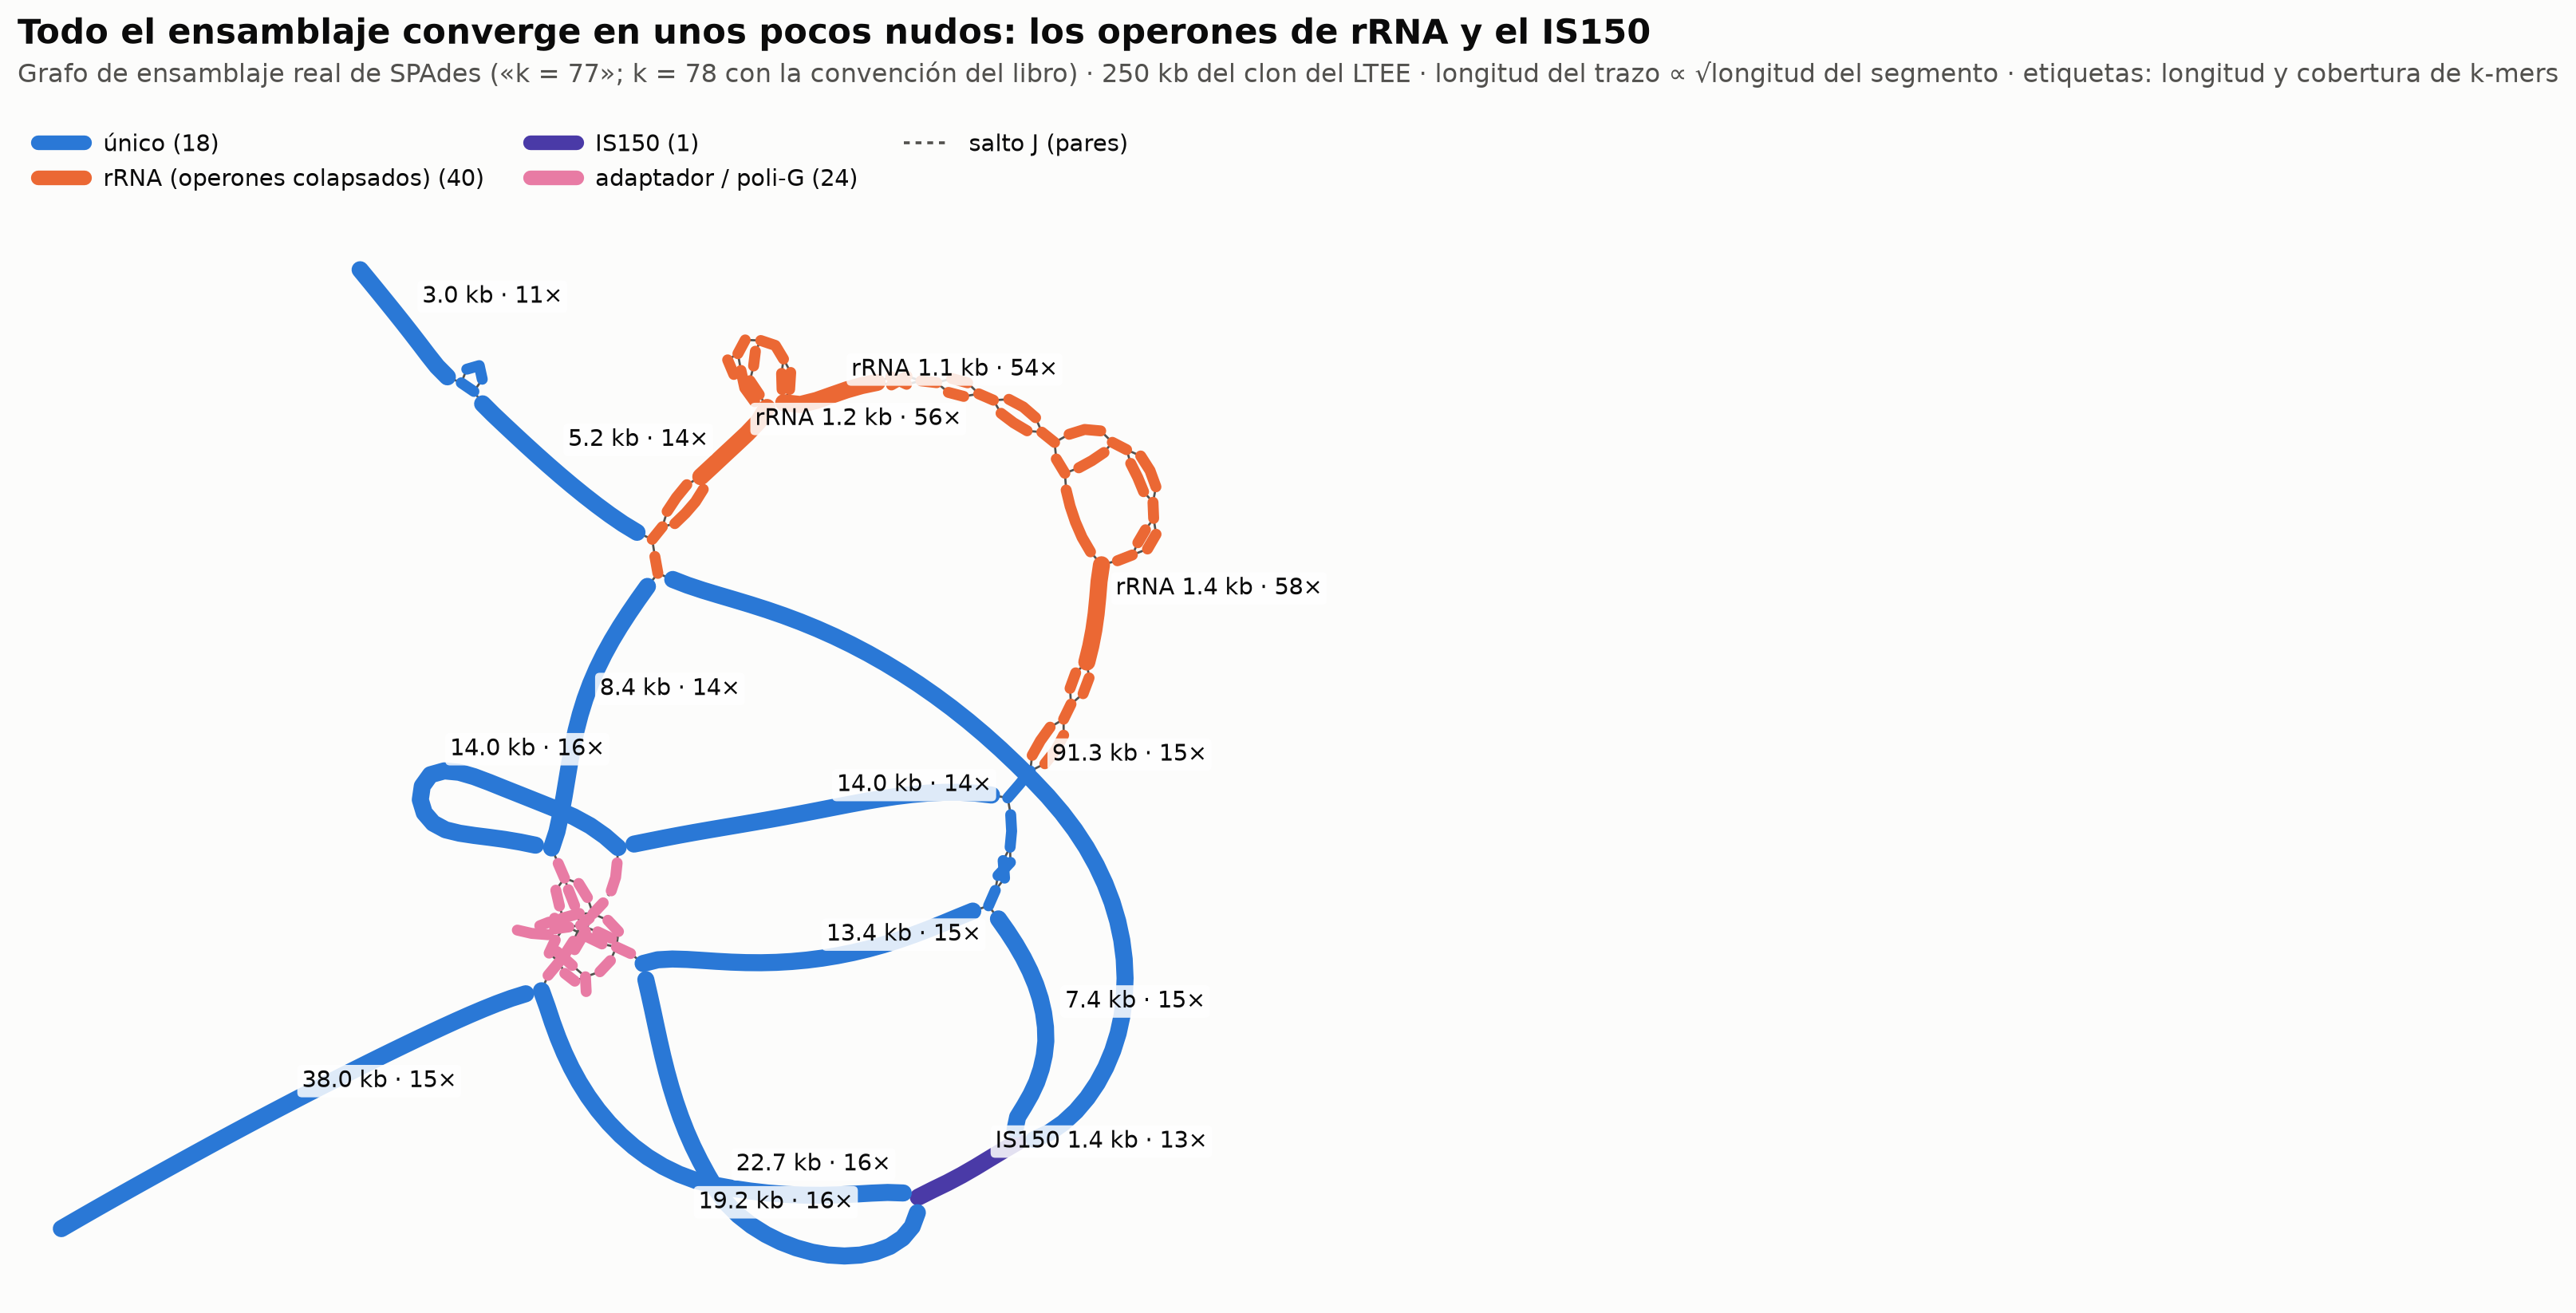

In [34]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(13.5, 10))
for sid in sorted(main, key=lambda s_: segs.length[s_]):
    xy = np.array([lay[p] for p in chain[sid]])
    cls = segs.clase[sid]
    ax.plot(xy[:, 0], xy[:, 1], color=CLASS_COL[cls], lw=7 if segs.length[sid] > 1000 else 4.5,
            solid_capstyle="round", zorder=3)
for p, q in link_pairs:
    ax.plot(*np.array([lay[p], lay[q]]).T, color=ec.INK_2, lw=0.9, zorder=2)
for p, q in jump_pairs:
    ax.plot(*np.array([lay[p], lay[q]]).T, color=ec.INK_2, lw=1.2, ls=(0, (2, 2)), zorder=2)
labelled = segs.loc[list(main)]
labelled = labelled[(labelled.length >= 1000)]
span = np.ptp(np.array(list(lay.values())), axis=0).max()
placed_lab = []
for sid, r in labelled.sort_values("length", ascending=False).iterrows():
    xy = np.array([lay[p] for p in chain[sid]])
    mx, my = xy[len(xy) // 2]
    near = sum(np.hypot(mx - a, my - b) < 0.06 * span for a, b in placed_lab)
    placed_lab.append((mx, my))
    txt = (f"{r.length / 1000:.1f} kb · {r.DP:.0f}×" if r.clase == "único" else
           f"{r.clase.split(' ')[0]} {r.length / 1000:.1f} kb · {r.DP:.0f}×")
    ax.annotate(txt, (mx, my), xytext=(8, 8 - 22 * near), textcoords="offset points", fontsize=9.5, color=ec.INK, zorder=6,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
handles = [Line2D([0], [0], color=c, lw=6, label=f"{k} ({(segs.loc[list(main)].clase == k).sum()})")
           for k, c in CLASS_COL.items() if (segs.loc[list(main)].clase == k).any()]
handles.append(Line2D([0], [0], color=ec.INK_2, lw=1.2, ls=(0, (2, 2)), label="salto J (pares)"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0, 1.0), fontsize=9.5, frameon=False, ncol=3)
allxy = np.array(list(lay.values()))
pad = np.ptp(allxy, axis=0) * 0.04
ax.set_xlim(allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0] * 3)
ax.set_ylim(allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1] * 4)     # espacio para la leyenda
ax.set_aspect("equal"); ax.axis("off")
ec.title(ax, "Todo el ensamblaje converge en unos pocos nudos: los operones de rRNA y el IS150",
         f"Grafo de ensamblaje real de SPAdes («k = {K_ASM}»; k = {K_BOOK} con la convención del libro) · 250 kb del clon del LTEE · longitud del trazo ∝ √longitud "
         "del segmento · etiquetas: longitud y cobertura de k-mers")
plt.show()

> 🔎 **Qué observamos.** El dibujo cuenta la historia sin necesidad de la referencia. Los segmentos únicos (azules,
> DP ≈ 15) son largos y limpios. Donde se juntan, siempre hay uno de tres "nudos": la madeja **naranja** de los operones
> de rRNA, con muchas burbujas pequeñas y cobertura alta; el segmento **violeta** del IS150, al que llegan dos segmentos
> y del que salen otros dos; y un ovillo **rosa** de adaptadores y poli-G, con coberturas de hasta 300×, que se engancha
> a varios segmentos únicos. Es exactamente lo que hace un bioinformático con Bandage ante un ensamblaje nuevo: buscar
> dónde y por qué se ramifica el grafo.

### 🔍 El grafo real, interactivo

Pase el cursor por cada segmento para ver su identificador, longitud, cobertura, número de copias en REL606, posición
en la región y a qué contig pertenece. Haga zoom con el ratón en la madeja de rRNA para ver sus burbujas.

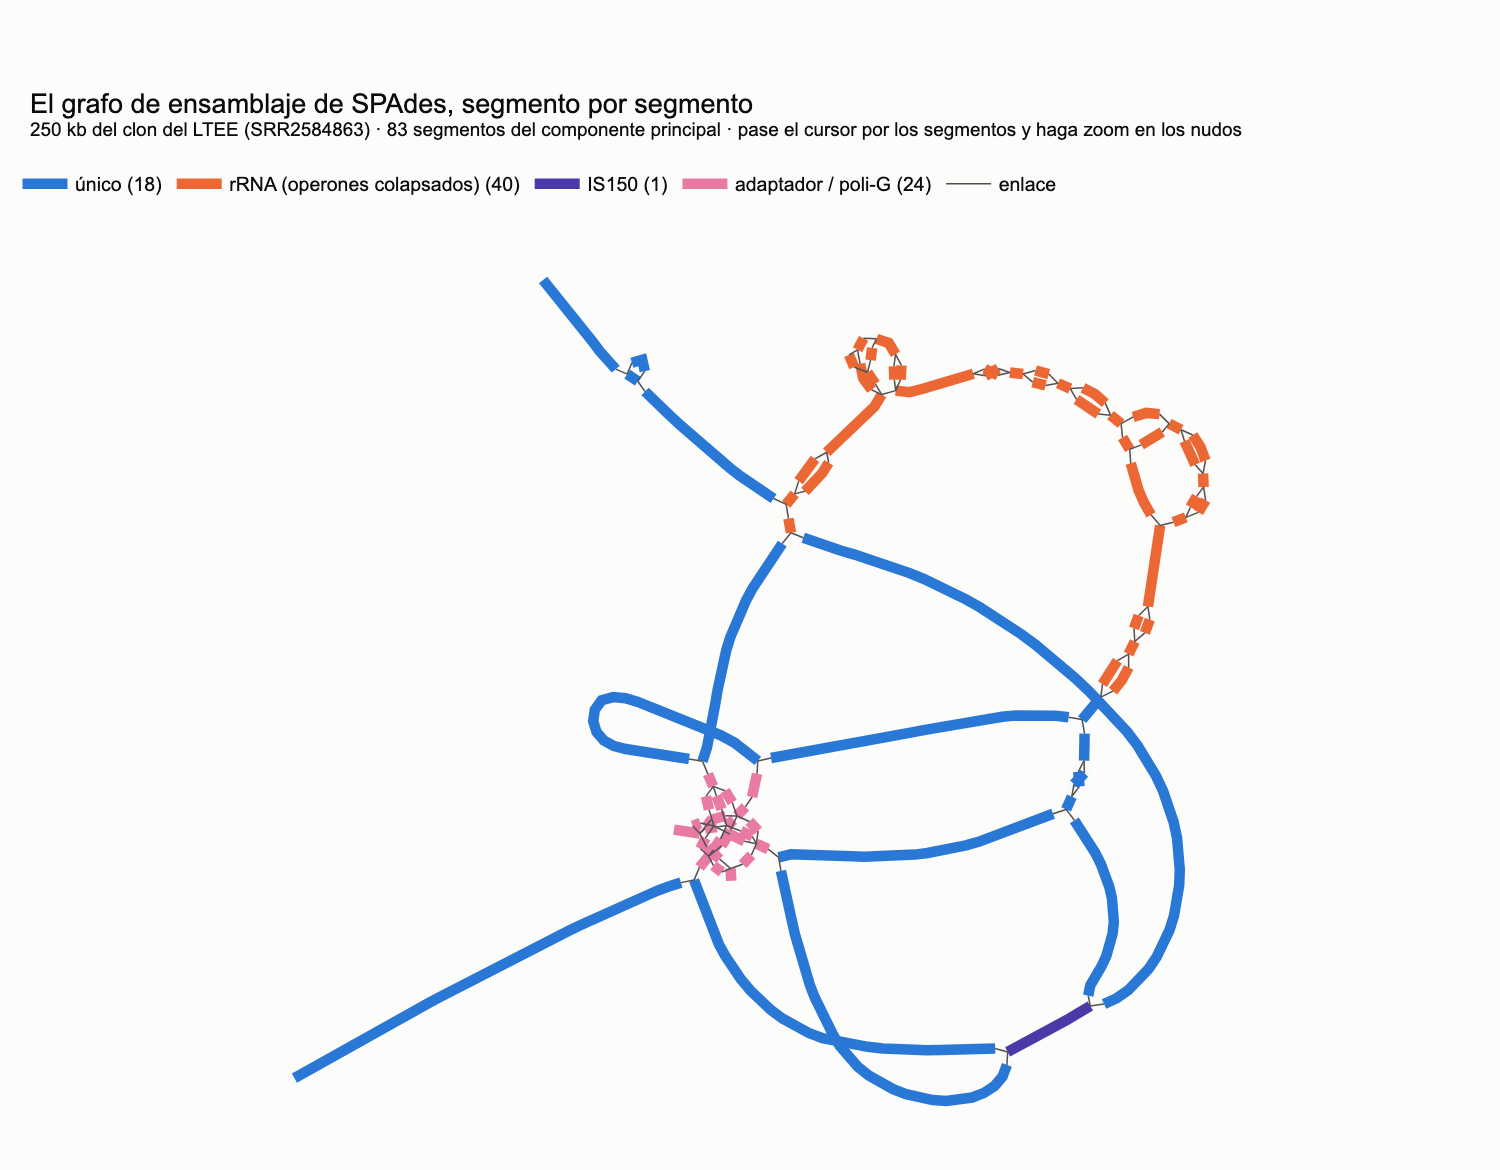

In [35]:
seg_contigs = defaultdict(list)
for name, plist in paths.items():
    short = "_".join(name.split("_")[:2])
    for sid, _, _ in plist:
        seg_contigs[sid].append(short)
CLASS_HELP = {"único": "secuencia de copia única: el ensamblador la recorre sin dudas",
              "rRNA (operones colapsados)": "las copias de los operones rrn se funden en un solo camino: maraña",
              "IS150": "elemento de inserción con varias copias en el genoma: maraña",
              "adaptador / poli-G": "artefacto de la biblioteca o del secuenciador, no es genoma",
              "error / baja cobertura": "restos de errores de secuenciación (DP ≈ 1)",
              "de otra parte del genoma": "lecturas reclutadas de otra región"}
fig = go.Figure()
for cls, col in CLASS_COL.items():
    ids = [s_ for s_ in main if segs.clase[s_] == cls]
    if not ids:
        continue
    xs, ys, hx, hy, htxt = [], [], [], [], []
    for sid in ids:
        xy = np.array([lay[p] for p in chain[sid]])
        xs += list(xy[:, 0]) + [None]; ys += list(xy[:, 1]) + [None]
        r = segs.loc[sid]
        pos_txt = (f"{int(r.reg_start):,}–{int(r.reg_end):,} de la región (hebra {r.strand})"
                   if not np.isnan(r.reg_start) else "sin 31-mers de copia única en la región")
        info = (f"<b>segmento {sid}</b> · {cls}<br>{r.length:,} pb · cobertura de k-mers DP = {r.DP:.1f}<br>"
                f"≈ {r.copies_genome:g} copias en REL606 · {pos_txt}<br>contig: {', '.join(seg_contigs[sid]) or '—'}"
                f"<br><i>{CLASS_HELP[cls]}</i>")
        for p in xy[:: max(1, len(xy) // 4)]:                 # varios puntos por segmento para el cursor
            hx.append(p[0]); hy.append(p[1]); htxt.append(info)
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color=col, width=7), name=f"{cls} ({len(ids)})",
                             hoverinfo="skip", legendgroup=cls))
    fig.add_trace(go.Scatter(x=hx, y=hy, mode="markers", marker=dict(color=col, size=9, opacity=0.01),
                             hovertext=htxt, hoverinfo="text", showlegend=False, legendgroup=cls))
lx, ly = [], []
for p, q in link_pairs + jump_pairs:
    lx += [lay[p][0], lay[q][0], None]; ly += [lay[p][1], lay[q][1], None]
fig.add_trace(go.Scatter(x=lx, y=ly, mode="lines", line=dict(color="#52514e", width=1), name="enlace", hoverinfo="skip"))
fig.update_layout(
    title=dict(text="El grafo de ensamblaje de SPAdes, segmento por segmento"
                    "<br><sup>250 kb del clon del LTEE (SRR2584863) · 83 segmentos del componente principal · "
                    "pase el cursor por los segmentos y haga zoom en los nudos</sup>"),
    xaxis=dict(visible=False), yaxis=dict(visible=False, scaleanchor="x"), height=780,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=150, l=10, r=10, b=10))
fig.show()

### 9.4 ¿Por qué se rompe el ensamblaje exactamente ahí?

SPAdes entregó 12 contigs de al menos 500 pb para estos 250 kb (N50 = 57 186 pb según QUAST, sin errores de
ensamblaje). Cada contig es un **camino** (`P`) del grafo: SPAdes recorre los segmentos mientras la continuación es
inequívoca y se detiene en cuanto el grafo se ramifica. Coloquemos los contigs sobre la referencia junto con las tres
causas candidatas: los operones de rRNA, los puntos donde el grafo inserta el IS150 y los puntos donde se enganchan los
adaptadores.

> 🤔 **Antes de ejecutar, prediga.** La región contiene 3 operones de rRNA. Si ninguna otra cosa rompiera el
> ensamblaje, ¿cuántos contigs esperaría para 250 kb? ¿Cuántos más añadiría cada inserción de un IS?

In [36]:
def seg_base(sid, which):
    """Coordenada de la región de la primera ('first') o última ('last') base del segmento en su propia orientación."""
    r = segs.loc[sid]
    if not r.strand:
        return np.nan
    return (r.reg_start if which == "first" else r.reg_end) if r.strand == "+" else \
           (r.reg_end if which == "first" else r.reg_start)

# 1) operones de rRNA dentro de la región (coordenadas de la región)
reg_operons = [(a - REGION_OFFSET, b - REGION_OFFSET) for a, b in operons
               if a > REGION_OFFSET and b <= REGION_OFFSET + len(region)]
# 2) inserciones del IS150: dónde se unen al IS sus vecinos únicos
is_id = segs.index[segs.clase == "IS150"][0]
is_junctions = []
for a, sa, b, sb, _ in links:
    if a == is_id and segs.clase[b] == "único":
        is_junctions.append(seg_base(b, "first" if sb == "+" else "last"))
    elif b == is_id and segs.clase[a] == "único":
        is_junctions.append(seg_base(a, "last" if sa == "+" else "first"))
# 3) adaptadores: segmentos quiméricos (adaptador + genoma) que sí se ubican en la región
adapter_sites = [float(np.nanmean([r.reg_start, r.reg_end])) for _, r in segs[segs.clase == "adaptador / poli-G"].iterrows()
                 if not np.isnan(r.reg_start)]
print("Operones de rRNA en la región:", [(int(a), int(b)) for a, b in reg_operons])
print("Uniones del IS150 con segmentos únicos:", sorted(int(x) for x in is_junctions))
print("Segmentos quiméricos de adaptador ubicados en:", sorted(int(x) for x in adapter_sites))

# contigs: extensión sobre la referencia a partir de sus segmentos ubicables
ctg_rows = []
for name, plist in paths.items():
    length = int(name.split("_")[3])
    if length < 1000:
        continue
    placed = [segs.loc[sid, ["reg_start", "reg_end"]].values for sid, _, _ in plist if segs.clase[sid] == "único"]
    if not placed:
        ctg_rows.append(dict(contig="_".join(name.split("_")[:2]), length=length, start=np.nan, end=np.nan,
                             segmentos=len(plist)))
        continue
    placed = np.array(placed, dtype=float)
    ctg_rows.append(dict(contig="_".join(name.split("_")[:2]), length=length, start=np.nanmin(placed),
                         end=np.nanmax(placed), segmentos=len(plist)))
ctgs = pd.DataFrame(ctg_rows)

causes = [("operón rRNA", a, b) for a, b in reg_operons] + [("IS150", x, x) for x in is_junctions] + \
         [("adaptador", x, x) for x in adapter_sites]
def nearest_cause(x):
    d = [(0 if a <= x <= b else min(abs(x - a), abs(x - b)), name) for name, a, b in causes]
    return min(d)
rows = []
for _, c in ctgs.dropna().iterrows():
    for side, x in (("inicio", c.start), ("final", c.end)):
        if x < 300 or x > len(region) - 300:
            rows.append(dict(contig=c.contig, extremo=side, posición=int(x), causa="borde de la región", distancia=0))
            continue
        d, name = nearest_cause(x)
        rows.append(dict(contig=c.contig, extremo=side, posición=int(x), causa=name, distancia=int(d)))
ends = pd.DataFrame(rows)
print("\n" + ctgs.to_string(index=False))
print("\n¿Qué hay junto a cada extremo de contig? (distancia en pb a la causa más cercana)")
print(ends.to_string(index=False))
print("\nResumen:", ends.causa.value_counts().to_dict())

Operones de rRNA en la región: [(63904, 69099), (196520, 201533), (237734, 242830)]
Uniones del IS150 con segmentos únicos: [56268, 56280, 160236, 160240]
Segmentos quiméricos de adaptador ubicados en: [37177, 182848, 209827, 219706, 223742]

contig  length    start      end  segmentos
NODE_1   91493  69116.0 160236.0          4
NODE_2   57186      2.0  56268.0          2
NODE_3   36521 201550.0 237455.0          7
NODE_4   36077 160240.0 196186.0          2
NODE_5    8271 242811.0 250027.0          5
NODE_6    7632  56280.0  63663.0          4
NODE_7    2399      NaN      NaN          2
NODE_8    1444      NaN      NaN          1
NODE_9    1376      NaN      NaN          1

¿Qué hay junto a cada extremo de contig? (distancia en pb a la causa más cercana)
contig extremo  posición              causa  distancia
NODE_1  inicio     69116        operón rRNA         17
NODE_1   final    160236              IS150          0
NODE_2  inicio         2 borde de la región          0
NODE_2   final

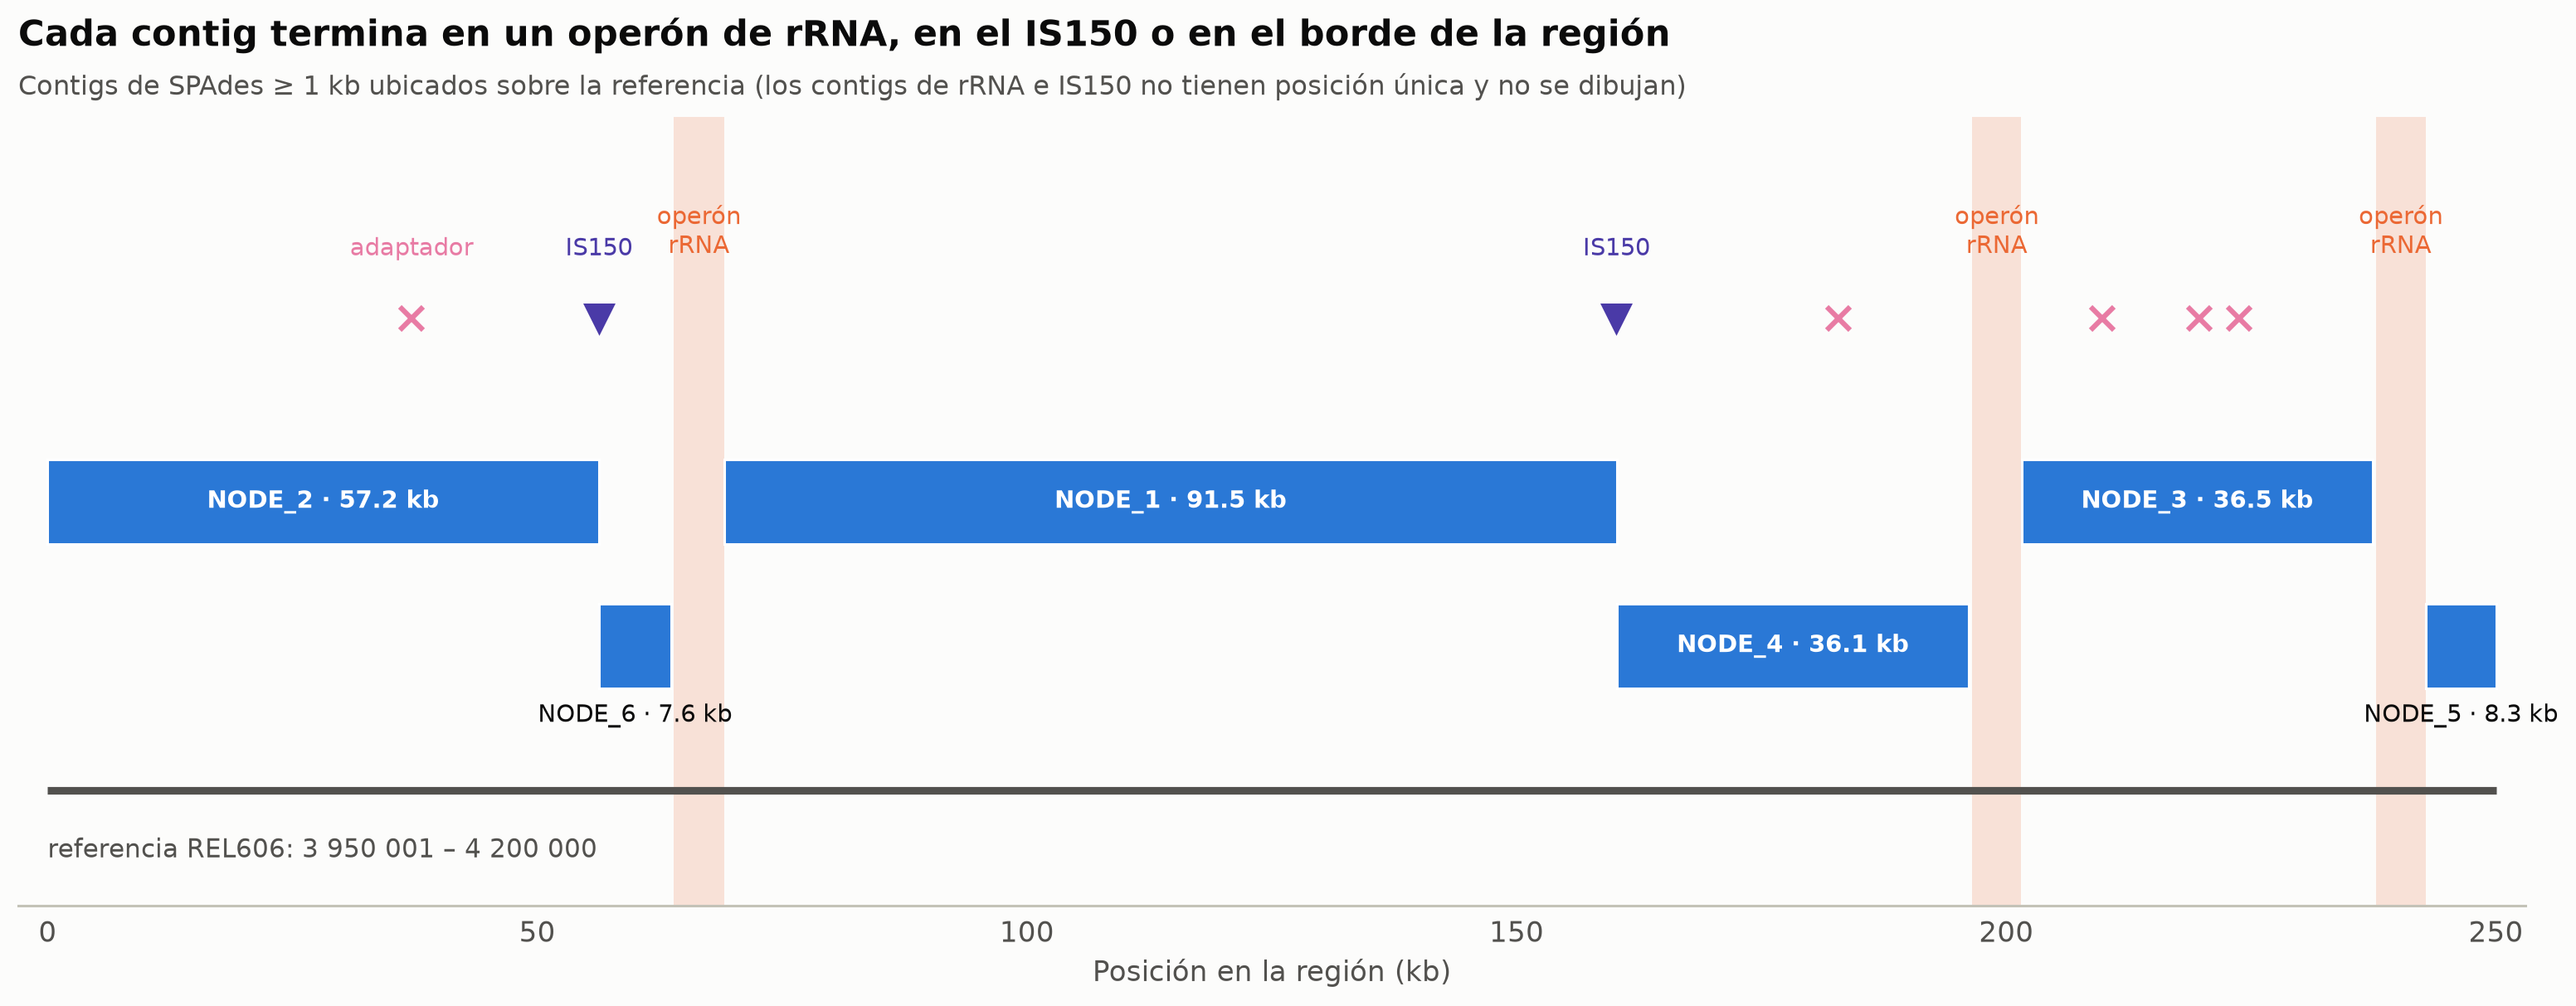

In [37]:
fig, ax = plt.subplots(figsize=(14, 5.4))
for a, b in reg_operons:
    ax.axvspan(a / 1000, b / 1000, color=ec.ORANGE, alpha=0.18, lw=0)
    ax.text((a + b) / 2000, 3.35, "operón\nrRNA", ha="center", va="bottom", fontsize=9.5, color=ec.ORANGE)
for x in sorted(set(round(v / 100) * 100 for v in is_junctions)):
    ax.plot(x / 1000, 3.05, marker="v", color=ec.VIOLET, ms=11)
    ax.text(x / 1000, 3.35, "IS150", ha="center", va="bottom", fontsize=9.5, color=ec.VIOLET)
for x in adapter_sites:
    ax.plot(x / 1000, 3.05, marker="x", color=ec.MAGENTA, ms=9, mew=2)
ax.text(min(adapter_sites) / 1000, 3.35, "adaptador", ha="center", va="bottom", fontsize=9.5, color=ec.MAGENTA)
placed = ctgs.dropna().sort_values("start").reset_index(drop=True)
for i, c in placed.iterrows():
    y = 2.1 if i % 2 == 0 else 1.35
    ax.add_patch(Rectangle((c.start / 1000, y - 0.22), (c.end - c.start) / 1000, 0.44, fc=ec.BLUE, ec="white", lw=1))
    big = c.end - c.start > 20000
    ax.text((c.start + c.end) / 2000, y if big else y - 0.3, f"{c.contig} · {c.length / 1000:.1f} kb", ha="center",
            va="center" if big else "top", color="white" if big else ec.INK, fontsize=9.5,
            fontweight="bold" if big else "normal")
ax.hlines(0.6, 0, len(region) / 1000, color=ec.INK_2, lw=3)
ax.text(0, 0.25, "referencia REL606: 3 950 001 – 4 200 000", fontsize=10, color=ec.INK_2)
ax.set_xlim(-3, len(region) / 1000 + 3); ax.set_ylim(0, 4.1)
ax.set_yticks([]); ax.spines["left"].set_visible(False)
ax.set_xlabel("Posición en la región (kb)")
ec.title(ax, "Cada contig termina en un operón de rRNA, en el IS150 o en el borde de la región",
         "Contigs de SPAdes ≥ 1 kb ubicados sobre la referencia (los contigs de rRNA e IS150 no tienen posición única y no se dibujan)")
plt.show()

> 🔎 **Qué observamos.** Los **12 extremos** de los 6 contigs ubicables caen en tres sitios: **6 en operones de rRNA**
> (a menos de ~350 pb, la parte del operón que el contig alcanza a incluir antes de la ramificación), **4 en el IS150**
> y 2 en los bordes de la región. Ningún extremo cae en un adaptador: aunque los adaptadores crean ramas en el grafo,
> son puntas que SPAdes sabe atravesar (son callejones, no caminos alternativos entre dos regiones del genoma).

Dos detalles merecen atención de maestría:

* **El IS150 es biología nueva.** El segmento de 1 444 pb no está en la región de REL606, pero el grafo lo inserta en
  dos sitios: entre los contigs NODE_2 y NODE_6 (posición ≈ 56,27 kb de la región, 4 006 270 del cromosoma) y entre
  NODE_1 y NODE_4 (≈ 160,24 kb, 4 110 240). En la referencia, los extremos de cada par de contigs son **contiguos**
  (a la resolución de nuestras sondas, ~10 pb): algo se insertó ahí **en el clon evolucionado**. Las inserciones de
  IS150 son una de las fuentes de mutación más frecuentes en el LTEE (Tenaillon *et al.*, 2016). Un ensamblaje de
  novo las revela, aunque no sepa colocar el IS dentro de un contig: como hay ≈ 5 copias idénticas en el genoma, las
  lecturas del interior del IS no dicen a cuál pertenecen.
* **Los 3 operones son una sola maraña.** Los ≈ 5 kb de cada operón son casi idénticos entre sí, más largos que
  cualquier lectura (150 nt) y que casi cualquier inserto (99,9 % ≤ 1,35 kb). El grafo los funde: la cobertura de los segmentos
  centrales del rRNA es ≈ 3,7 veces la de la secuencia única, y los contigs que llegan a un operón no pueden decidir con
  cuál de los contigs que salen continúan. Es la figura "repetición" del libro, con A, B, C… reemplazados por contigs
  reales.

### 9.5 Burbujas reales: diferencias entre copias del operón

Dentro de la madeja naranja hay muchas burbujas pequeñas. No son errores: los 7 operones *rrn* de *E. coli* no son
idénticos, y cada diferencia entre copias crea dos caminos paralelos. Busquémoslas en el grafo **bidirigido**: dos
segmentos forman una burbuja simple si, en alguna orientación, tienen exactamente los mismos predecesores y sucesores.

In [38]:
FLIP = {"+": "-", "-": "+"}
succ, pred = defaultdict(set), defaultdict(set)
for a, sa, b, sb, _ in links:                                  # cada enlace vale en las dos hebras
    succ[(a, sa)].add((b, sb)); pred[(b, sb)].add((a, sa))
    succ[(b, FLIP[sb])].add((a, FLIP[sa])); pred[(a, FLIP[sa])].add((b, FLIP[sb]))
bubbles, seen_b = [], set()
cand = [s_ for s_ in main if segs.length[s_] < 1000]
for x, y in itertools.combinations(cand, 2):
    for ox in "+-":
        for oy in "+-":
            px, sx = pred[(x, ox)], succ[(x, ox)]
            if px and sx and px == pred[(y, oy)] and sx == succ[(y, oy)] and (x, y) not in seen_b:
                seen_b.add((x, y))
                (u, _), (w, _) = next(iter(px)), next(iter(sx))
                bubbles.append(dict(rama_1=x, DP_1=segs.DP[x], rama_2=y, DP_2=segs.DP[y],
                                    suma_DP=segs.DP[x] + segs.DP[y], antes=u, DP_antes=segs.DP[u],
                                    después=w, DP_después=segs.DP[w], clase=segs.clase[x],
                                    copias_genoma=segs.copies_genome[x],
                                    long_1=segs.length[x], long_2=segs.length[y]))
bub = pd.DataFrame(bubbles).round(1)
print(f"Burbujas simples encontradas: {len(bub)}")
print(bub.sort_values("clase").to_string(index=False))

Burbujas simples encontradas: 10
rama_1  DP_1 rama_2  DP_2  suma_DP antes  DP_antes después  DP_después                      clase  copias_genoma  long_1  long_2
 38399  15.7  45163  18.7     34.4  1747      30.0   52571        24.0 rRNA (operones colapsados)            4.5     155     155
 41163  11.1  52569   8.8     20.0 52571      24.0   29875        35.5 rRNA (operones colapsados)            3.7     159     159
 42939  19.3  50437  31.5     50.8 52511      66.0   49670        34.6 rRNA (operones colapsados)            5.2     214     214
 46660  36.2  51198  34.4     70.6 50605      49.6   52984        54.2 rRNA (operones colapsados)            6.8     155     155
 49463  26.9  50386  48.4     75.3 52984      54.2   49055        60.6 rRNA (operones colapsados)            5.6     156     156
 49986  17.9  52509  33.1     51.1 52511      66.0   49055        60.6 rRNA (operones colapsados)            6.1     155     155
 50052  19.8  52209  29.9     49.6 53088      35.8   51886      

> 🔎 **Qué observamos.** Las burbujas del rRNA tienen ramas de ≈ 155 pb ($2k-1$: una sola base distinta) y ambas
> ramas están bien cubiertas (DP entre ≈ 10 y ≈ 50): la cobertura del operón colapsado se **reparte** entre ellas, como
> si una rama la llevaran unas copias del operón y la otra el resto. Hay además una burbuja fuera del rRNA, en el
> contig NODE_6, con dos ramas de DP ≈ 11 cada una; sus $31$-mers aparecen ≈ 3 veces en el genoma, así que
> probablemente es una repetición corta cuyas copias difieren en una base. Ninguna de estas burbujas es un error: tienen
> la forma de un sitio **heterocigoto** (sección 7), dos ramas de cobertura comparable. Una limpieza que "revienta
> burbujas" sin mirar la cobertura conservaría una rama y **borraría la variante** de las otras copias: el aviso
> "podar demasiado borra biología", en datos reales.

### 9.6 ¿Lo resolvería un $k$ mayor o un par de lecturas?

Con lo aprendido en la sección 8 la respuesta es cuantitativa:

In [39]:
for R, name in ((op_len, "operón rRNA"), (IS150_LEN, "IS150")):
    print(f"{name} (R ≈ {R:,.0f} pb):")
    print(f"   · k mayor: haría falta k > R + 1 = {R + 1:,.0f}, pero k ≤ L = {READ_LEN} (lecturas de 150 nt) → imposible")
    print(f"   · pares reales: inserto máximo observado ≈ {ins_len[ins_p > 0].max():,.0f} pb; fragmentos que lo atraviesan "
          f"con anclaje: {frac_span(ins_len, ins_p, R):.3%} → ≈ {expected_span(ins_len, ins_p, R, N_PAIRS):.2f} por copia")
    print(f"   · lecturas largas (simuladas, 40×): {frac_span(lr_len, lr_p, R):.0%} lo atraviesan → ≈ "
          f"{expected_span(lr_len, lr_p, R, 40 * G_REL / lr_len.mean()):.0f} por copia")

operón rRNA (R ≈ 5,097 pb):
   · k mayor: haría falta k > R + 1 = 5,098, pero k ≤ L = 150 (lecturas de 150 nt) → imposible
   · pares reales: inserto máximo observado ≈ 2,175 pb; fragmentos que lo atraviesan con anclaje: 0.000% → ≈ 0.00 por copia
   · lecturas largas (simuladas, 40×): 66% lo atraviesan → ≈ 15 por copia
IS150 (R ≈ 1,444 pb):
   · k mayor: haría falta k > R + 1 = 1,445, pero k ≤ L = 150 (lecturas de 150 nt) → imposible
   · pares reales: inserto máximo observado ≈ 2,175 pb; fragmentos que lo atraviesan con anclaje: 0.007% → ≈ 0.01 por copia
   · lecturas largas (simuladas, 40×): 100% lo atraviesan → ≈ 32 por copia


> 🔎 **Qué observamos.** Ni subir $k$ ni los pares de esta biblioteca pueden resolver un operón de rRNA: $k$ está
> limitado por la longitud de la lectura y el 99,9 % de los insertos no pasa de ≈ 1,35 kb. Con el IS150 el caso es el mismo, por muy
> poco. Hacen falta **lecturas largas** (o una biblioteca de insertos largos, *mate-pair*, bien diseñada). En la Lección
> 8.3 veremos que el ensamblaje de SPAdes con **todas** las lecturas del clon da unas decenas de contigs, y que sus
> extremos se explican con esta misma lógica.

> ✅ **Compruebe su comprensión.** Un colega propone "arreglar" el ensamblaje subiendo la cobertura de 100× a 500×.
> Usando la ecuación de Lander–Waterman (Lección 6.3) y lo visto hoy, explique por qué el número de contigs apenas
> cambiará.

## ✍️ Ejercicios

**Ejercicio 1 (a mano y con código).** El genoma de juguete `GTACCGATTGACCGATCTACCGATGG` (26 pb) tiene una repetición. (a) Construya
a mano la tabla de grados de $G_3$ y diga si hay camino euleriano y dónde empieza. (b) Con `de_bruijn_multi` y
`count_eulerian_paths_best`, encuentre el menor $k$ para el que la reconstrucción es única. ¿Qué longitud tiene la
repetición responsable?

**Ejercicio 2 (Königsberg reformada).** Añada un octavo puente entre A y B y vuelva a contar los grados de las cuatro
zonas. ¿Existe ahora el paseo? ¿Entre qué zonas debe empezar y terminar?

**Ejercicio 3 (podar borra biología).** Construya un "diploide": 15× de lecturas sin errores salen de `genome_sim` y
otras 15× de una copia con un único cambio de base en la posición 700. Ejecute `clean_graph` con
`ratio = 0.35` y con `ratio = 1.01`. ¿Sobrevive el alelo alternativo en cada caso? ¿Qué parámetro protege la variante?

**Ejercicio 4 (el grafo real).** Estime cuántas copias del operón están colapsadas en cada uno de los tres segmentos
centrales de rRNA dividiendo su DP entre la cobertura única. Compare con las 3 copias de la región y las 7 del genoma.
¿Qué explica el valor intermedio?

In [40]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
toy2 = "GTACCGATTGACCGATCTACCGATGG"
print(degree_table(de_bruijn_multi(toy2, 3)).to_string())
for k in range(3, 12):
    gk = de_bruijn_multi(toy2, k)
    if euler_check(gk) is None:
        print(f"k = {k}: sin camino euleriano"); continue
    n = count_eulerian_paths_best(gk)[2]
    print(f"k = {k}: {n} reconstrucción(es)")
    if n == 1:
        break
print("Repetición: ACCGAT aparece tres veces (R = 6 pb): los tramos TG y CT entre copias pueden intercambiarse; "
      "hace falta k ≥ R + 2 = 8")

      d⁻ (entran)  d⁺ (salen)       papel
nodo                                     
AC              3           3  balanceado
AT              3           3  balanceado
CC              3           3  balanceado
CG              3           3  balanceado
CT              1           1  balanceado
GA              4           4  balanceado
GG              1           0   t (final)
GT              0           1  s (inicio)
TA              2           2  balanceado
TC              1           1  balanceado
TG              2           2  balanceado
TT              1           1  balanceado
k = 3: 12 reconstrucción(es)
k = 4: 2 reconstrucción(es)
k = 5: 2 reconstrucción(es)
k = 6: 2 reconstrucción(es)
k = 7: 2 reconstrucción(es)
k = 8: 1 reconstrucción(es)
Repetición: ACCGAT aparece tres veces (R = 6 pb): los tramos TG y CT entre copias pueden intercambiarse; hace falta k ≥ R + 2 = 8


In [41]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
bridges8 = bridges + [("A", "B")]
deg8 = Counter()
for u, v in bridges8:
    deg8[u] += 1; deg8[v] += 1
print("Grados con el octavo puente:", dict(deg8), "→ impares:", [n for n, d in deg8.items() if d % 2])
print("Con exactamente dos zonas impares (C y D) el paseo existe: empieza en una y termina en la otra.")

Grados con el octavo puente: {'A': 4, 'C': 5, 'B': 4, 'D': 3} → impares: ['C', 'D']
Con exactamente dos zonas impares (C y D) el paseo existe: empieza en una y termina en la otra.


In [42]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
POS_SNP = 700
alt_base = "A" if genome_sim[POS_SNP] != "A" else "C"
genome_alt = genome_sim[:POS_SNP] + alt_base + genome_sim[POS_SNP + 1:]
rng_d = np.random.default_rng(3)
reads_dip = []
for seq in (circ, genome_alt + genome_alt[:L_READ]):
    for _ in range(n_reads):                                 # 15× por haplotipo, sin errores
        p = int(rng_d.integers(G_LEN)); reads_dip.append(seq[p:p + L_READ])
counts_dip = Counter(x for r in reads_dip for x in kmers(r, K))
alt_kmers = {genome_alt[i:i + K] for i in range(POS_SNP - K + 1, POS_SNP + 1)}
ref_kmers = {genome_sim[i:i + K] for i in range(POS_SNP - K + 1, POS_SNP + 1)}
for ratio in (0.35, 1.01):
    cl, lg = clean_graph(counts_dip, ratio=ratio)
    print(f"ratio = {ratio}: {Counter(k for k, _ in lg)} · alelo de referencia: {ref_kmers <= set(cl)} · "
          f"alelo alternativo: {alt_kmers <= set(cl)}")
print("Con ratio 0,35 sólo se eliminan ramas con menos de un tercio de la cobertura de la alternativa: las dos ramas del"
      " sitio heterocigoto (≈ λ cada una) sobreviven. Con ratio > 1 se elimina siempre la menos cubierta y se pierde un alelo.")

ratio = 0.35: Counter() · alelo de referencia: True · alelo alternativo: True
ratio = 1.01: Counter({'burbuja': 1}) · alelo de referencia: False · alelo alternativo: True
Con ratio 0,35 sólo se eliminan ramas con menos de un tercio de la cobertura de la alternativa: las dos ramas del sitio heterocigoto (≈ λ cada una) sobreviven. Con ratio > 1 se elimina siempre la menos cubierta y se pierde un alelo.


In [43]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
cores = segs[(segs.clase.str.startswith("rRNA")) & (segs.length > 1000)]
print((cores.DP / cov_unique).round(2).rename("copias estimadas = DP / cobertura única").to_string())
print("≈ 3,6–3,8: más que las 3 copias de la región porque el reclutamiento por mapeo trajo lecturas de otros operones "
      "(asignadas al azar entre sus 7 copias), pero menos que 7 porque no todas cayeron aquí.")

id
52984    3.57
53164    3.72
53194    3.83
≈ 3,6–3,8: más que las 3 copias de la región porque el reclutamiento por mapeo trajo lecturas de otros operones (asignadas al azar entre sus 7 copias), pero menos que 7 porque no todas cayeron aquí.


## 📌 Resumen

* El ensamblaje puede formularse como un **camino hamiltoniano** en el grafo de solapamiento (OLC; NP-completo) o como
  un **camino euleriano** en el grafo de De Bruijn (lineal). El cambio consiste en convertir los **$k$-mers en aristas**
  entre $(k-1)$-mers.
* **Teorema de Euler** (ec. 08-euler): hay camino euleriano de $s$ a $t$ si el grafo es conexo, $d^+(s)=d^-(s)+1$,
  $d^-(t)=d^+(t)+1$ y todos los demás nodos están balanceados. En `CAGGTTGCAGAAGGA` con $k=4$: `CAG` es $s$, `GGA` es
  $t$ y `AGG` tiene $d^-=d^+=2$.
* El **algoritmo de Hierholzer** construye el camino con una pila en $O(|E|)$. Con $k=4$ el grafo admite **dos**
  genomas (`CAGGTTGCAGAAGGA` y la quimera `CAGAAGGTTGCAGGA`, la que devuelve nuestro código); con $k=5$, uno. El
  **teorema BEST** cuenta las soluciones: cada repetición más larga que $k-1$ las multiplica.
* Lo seguro son los **unitigs** (caminos sin ramificaciones); el grafo compactado (GFA) es la salida real de SPAdes.
* Los errores crean **puntas** y **burbujas**: $\approx NLek$ $k$-mers espurios (ec. 08-espurios; exacto
  $N(L-k+1)[1-(1-e)^k]$), tantos como los verdaderos en un humano a 30×. La **poda de puntas** y la **eliminación de
  burbujas** (Velvet) los quitan usando longitud y cobertura; también pueden borrar variantes reales.
* Las **marañas** (repeticiones de longitud $R$) sólo se resuelven con información que las atraviese: $k > R+1$, pares
  con inserto $> R$ o lecturas largas.
* En el grafo real de SPAdes del clon del LTEE, **cada contig termina en un operón de rRNA (≈ 5 kb, cobertura ≈ 3,7×)
  o en una inserción de IS150** nueva respecto al ancestro; los pares (99,9 % de los insertos ≤ 1,35 kb) y $k \le 150$ no alcanzan.

## 📚 Para profundizar

* Euler, L. (1736). Solutio problematis ad geometriam situs pertinentis. *Commentarii Academiae Scientiarum
  Petropolitanae* 8: 128–140.
* Hierholzer, C. & Wiener, C. (1873). Ueber die Möglichkeit, einen Linienzug ohne Wiederholung und ohne Unterbrechung
  zu umfahren. *Mathematische Annalen* 6(1): 30–32.
* van Aardenne-Ehrenfest, T. & de Bruijn, N. G. (1951). Circuits and trees in oriented linear graphs. *Simon Stevin*
  28: 203–217.
* Idury, R. M. & Waterman, M. S. (1995). A new algorithm for DNA sequence assembly. *Journal of Computational Biology*
  2(2): 291–306.
* Pevzner, P. A., Tang, H. & Waterman, M. S. (2001). An Eulerian path approach to DNA fragment assembly. *Proceedings
  of the National Academy of Sciences* 98(17): 9748–9753.
* Myers, E. W. (2005). The fragment assembly string graph. *Bioinformatics* 21(suppl 2): ii79–ii85.
* Zerbino, D. R. & Birney, E. (2008). Velvet: algorithms for de novo short read assembly using de Bruijn graphs.
  *Genome Research* 18(5): 821–829.
* Compeau, P. E. C., Pevzner, P. A. & Tesler, G. (2011). How to apply de Bruijn graphs to genome assembly. *Nature
  Biotechnology* 29(11): 987–991.
* Bankevich, A., Nurk, S., Antipov, D., Gurevich, A. A., Dvorkin, M., Kulikov, A. S., *et al.* (2012). SPAdes: a new
  genome assembly algorithm and its applications to single-cell sequencing. *Journal of Computational Biology* 19(5):
  455–477.
* Nagarajan, N. & Pop, M. (2013). Sequence assembly demystified. *Nature Reviews Genetics* 14(3): 157–167.
* Wick, R. R., Schultz, M. B., Zobel, J. & Holt, K. E. (2015). Bandage: interactive visualization of de novo genome
  assemblies. *Bioinformatics* 31(20): 3350–3352.
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*
  536(7615): 165–170.
* Especificación del formato GFA: https://github.com/GFA-spec/GFA-spec · Bandage: https://rrwick.github.io/Bandage/

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)